In [160]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import pandas as pd
import math
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob

In [161]:
# =====================================================
# BLOQUE — SEPARAR UN .TXT/.LOG EN DOS .LOG
#   1) barco_propio.log
#   2) contactos_ais.log
# =====================================================

archivo_entrada = "EJERCICIO_ROTA_2.txt"   # o tu .log original
salida_barco = "barco_propio.log"
salida_contactos = "contactos_ais.log"

num_barco = 0
num_contactos = 0

with open(archivo_entrada, "r", encoding="utf-8", errors="ignore") as f_in, \
     open(salida_barco, "w", encoding="utf-8") as f_barco, \
     open(salida_contactos, "w", encoding="utf-8") as f_contactos:

    for line in f_in:
        line_strip = line.strip()

        if not line_strip:
            continue

        # Coger la parte NMEA/AIS después del ;
        if ";" in line_strip:
            _, sentence = line_strip.split(";", 1)
            sentence = sentence.strip()
        else:
            sentence = line_strip

        # Si es AIS -> contactos
        if sentence.startswith("!AIVDM") or sentence.startswith("!AIVDO"):
            f_contactos.write(line)
            num_contactos += 1
        else:
            f_barco.write(line)
            num_barco += 1

print("Separación completada.")
print(f"Líneas barco propio: {num_barco}")
print(f"Líneas contactos AIS: {num_contactos}")
print(f"Archivo generado: {salida_barco}")
print(f"Archivo generado: {salida_contactos}")

Separación completada.
Líneas barco propio: 13918
Líneas contactos AIS: 21333
Archivo generado: barco_propio.log
Archivo generado: contactos_ais.log


In [162]:
# ============================================================
# BLOQUE 1
# CONVERSIÓN DE .LOG EN DATAFRAMES (BARCO PROPIO Y CONTACTOS)
# ============================================================
import pandas as pd
from pathlib import Path


# --------------------------------------------------
# FUNCIÓN PARA LEER ARCHIVOS NMEA
# --------------------------------------------------
def load_nmea_log(path: Path) -> pd.DataFrame:
    rows = []

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line_no, raw in enumerate(f, start=1):
            raw = raw.strip()
            if not raw:
                continue

            if ";" in raw:
                ts_str, sentence = raw.split(";", 1)
                try:
                    t = pd.to_datetime(
                        ts_str.strip(),
                        format="%Y-%m-%d %H:%M:%S.%f"
                    )
                except Exception:
                    t = pd.NaT
            else:
                t = pd.NaT
                sentence = raw

            rows.append({
                "time": t,
                "sentence": sentence.strip(),
                "line_no": line_no
            })

    df = pd.DataFrame(rows)
    df["talker"] = df["sentence"].str.startswith("!AI") \
        .map(lambda x: "AIS" if x else "NMEA")
    df["prefix"] = df["sentence"].str.split(",", n=1).str[0]

    return df


# --------------------------------------------------
# RUTAS (EXPLÍCITAS, SIN MAGIA)
# --------------------------------------------------
PATH_BARCO = Path("barco_propio.log")
PATH_CONTACTOS = Path("contactos_ais.log")

print("Existe barco:", PATH_BARCO.exists())
print("Existe contactos:", PATH_CONTACTOS.exists())


# --------------------------------------------------
# CARGA
# --------------------------------------------------
df_barco = load_nmea_log(PATH_BARCO)
df_contactos = load_nmea_log(PATH_CONTACTOS)


# --------------------------------------------------
# SEPARACIÓN
# --------------------------------------------------
df_barco_nmea = df_barco[df_barco["talker"] == "NMEA"].copy()
df_contactos_ais = df_contactos[df_contactos["talker"] == "AIS"].copy()


# --------------------------------------------------
# COMPROBACIÓN VISUAL
# --------------------------------------------------
print("\nBARCO PROPIO")
print("Total líneas:", len(df_barco_nmea))
print(df_barco_nmea["prefix"].value_counts().head())

print("\nCONTACTOS")
print("Total líneas:", len(df_contactos_ais))
print(df_contactos_ais["prefix"].value_counts().head())

display(df_barco_nmea.head())
display(df_contactos_ais.head())


Existe barco: True
Existe contactos: True

BARCO PROPIO
Total líneas: 13918
prefix
$GPDTM    2710
$GPZDA    2710
$GPVTG    2710
$GPGLL    2710
$GPHDT    1230
Name: count, dtype: int64

CONTACTOS
Total líneas: 21333
prefix
!AIVDM    21333
Name: count, dtype: int64


,time,sentence,line_no,talker,prefix
0,2026-03-12 11:17:40.096722,"$GPHDT,90.0,T*0C",1,NMEA,$GPHDT
1,2026-03-12 11:17:40.096722,"$IIMWV,270.0,T,0.0,N,A*3E",2,NMEA,$IIMWV
2,2026-03-12 11:17:40.096722,"$SDDPT,30.2,0.0,60.4*56",3,NMEA,$SDDPT
3,2026-03-12 11:17:40.097719,"$VDVBW,0.0,0.0,A,0.0,0.0,A,0.0,A,0.0,A*51",4,NMEA,$VDVBW
4,2026-03-12 11:17:42.820467,"$GPHDT,90.0,T*0C",5,NMEA,$GPHDT


,time,sentence,line_no,talker,prefix
0,2026-03-12 11:34:50.108571,"!AIVDM,2,1,0,A,51mfk=P00000`@EU000JoSJ0<4p58T5...",1,AIS,!AIVDM
1,2026-03-12 11:34:50.108571,"!AIVDM,2,2,0,A,000000008,2*2C",2,AIS,!AIVDM
2,2026-03-12 11:34:50.109596,"!AIVDM,1,1,,A,11mfk=P000wS3w2Dt8QhI0Ep0001,0*35",3,AIS,!AIVDM
3,2026-03-12 11:34:50.109866,"!AIVDM,2,1,1,A,51mfjwP00001M@a8<00Jo77>0lDpDp@...",4,AIS,!AIVDM
4,2026-03-12 11:34:50.110135,"!AIVDM,2,2,1,A,000000008,2*2D",5,AIS,!AIVDM


In [163]:
# ============================================================
# BLOQUE 2
# CREACIÓN DE CSV BRUTOS DEL BARCO PROPIO Y CONTACTOS AIS
# (FILTRADO INFORMACIÓN INNECESARIA DE CONTACTOS)
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

OUT_DIR = Path("ais_contacts")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# FUNCIONES NMEA – BARCO PROPIO
# ============================================================

def dm_to_deg(dm: str, is_lon: bool) -> float:
    deg_len = 3 if is_lon else 2
    deg = float(dm[:deg_len])
    minutes = float(dm[deg_len:])
    return deg + minutes / 60.0


def parse_gpgll(sentence: str):
    parts = sentence.split("*", 1)[0].split(",")
    if len(parts) < 6:
        return None

    lat_raw, lat_hemi = parts[1], parts[2]
    lon_raw, lon_hemi = parts[3], parts[4]

    if not lat_raw or not lon_raw:
        return None

    lat = dm_to_deg(lat_raw, is_lon=False)
    lon = dm_to_deg(lon_raw, is_lon=True)

    if lat_hemi == "S":
        lat = -lat
    if lon_hemi == "W":
        lon = -lon

    return lat, lon


def parse_gpvtg(sentence: str):
    parts = sentence.split("*", 1)[0].split(",")
    if len(parts) < 9:
        return None

    try:
        cog = float(parts[1]) if parts[1] else None
        sog_kn = float(parts[5]) if parts[5] else None
    except ValueError:
        return None

    return cog, sog_kn


# ============================================================
# FUNCIONES AIS – CONTACTOS (DINÁMICOS)
# ============================================================

def nmea_checksum_ok(sentence: str) -> bool:
    s = sentence.strip()
    if "*" not in s or not s.startswith(("!AIVDM", "!AIVDO")):
        return False

    data, chk = s[1:].split("*", 1)
    cs = 0
    for ch in data:
        cs ^= ord(ch)

    try:
        return cs == int(chk[:2], 16)
    except ValueError:
        return False


def sixbit_payload_to_bits(payload: str) -> str:
    bits = []
    for ch in payload:
        v = ord(ch) - 48
        if v > 40:
            v -= 8
        bits.append(f"{v:06b}")
    return "".join(bits)


def twos_complement(val: int, width: int) -> int:
    if val & (1 << (width - 1)):
        val -= (1 << width)
    return val


def parse_ais_dynamic_from_bits(bits: str):
    msg_type = int(bits[0:6], 2)
    if msg_type not in (1, 2, 3):
        return None

    mmsi = int(bits[8:38], 2)

    # 🔴 FILTRO CRÍTICO: EVITA ais_0.csv Y MMSI CORRUPTOS
    if mmsi == 0 or mmsi < 100000000 or mmsi > 999999999:
        return None

    sog_raw = int(bits[50:60], 2)
    sog_kn = None if sog_raw == 1023 else sog_raw / 10.0

    lon_raw = int(bits[61:89], 2)
    lat_raw = int(bits[89:116], 2)
    lon = twos_complement(lon_raw, 28) / 600000.0
    lat = twos_complement(lat_raw, 27) / 600000.0

    cog_raw = int(bits[116:128], 2)
    cog_deg = None if cog_raw == 3600 else cog_raw / 10.0

    hdg_raw = int(bits[128:137], 2)
    heading_deg = None if hdg_raw == 511 else hdg_raw

    return {
        "mmsi": mmsi,
        "lat": lat,
        "lon": lon,
        "cog_deg": cog_deg,
        "sog_kn": sog_kn,
        "heading_deg": heading_deg,
    }


def parse_aivdm_dynamic(sentence: str):
    if not nmea_checksum_ok(sentence):
        return None

    body = sentence[1:sentence.find("*")]
    parts = body.split(",")

    if len(parts) < 7:
        return None

    total = int(parts[1])
    num = int(parts[2])
    payload = parts[5]
    fill = int(parts[6])

    if total != 1 or num != 1:
        return None

    bits = sixbit_payload_to_bits(payload)
    if fill:
        bits = bits[:-fill]

    return parse_ais_dynamic_from_bits(bits)


# ============================================================
# 1) GENERAR CSV DEL BARCO PROPIO
# ============================================================

df_nmea = df_barco_nmea.sort_values("time")

own_rows = []

for _, r in df_nmea.iterrows():
    t = r["time"]
    s = r["sentence"]

    if pd.isna(t):
        continue

    if s.startswith("$GPGLL"):
        pos = parse_gpgll(s)
        if pos:
            own_rows.append({
                "time": t,
                "lat": pos[0],
                "lon": pos[1],
                "cog_deg": None,
                "sog_kn": None
            })

    elif s.startswith("$GPVTG") and own_rows:
        v = parse_gpvtg(s)
        if v:
            own_rows[-1]["cog_deg"] = v[0]
            own_rows[-1]["sog_kn"] = v[1]

own_df = pd.DataFrame(own_rows).dropna(subset=["lat", "lon"])
own_df.to_csv("own_ship.csv", index=False)

print(f"✓ own_ship.csv generado ({len(own_df)} filas)")


# ============================================================
# 2) GENERAR CSVs BRUTOS DE CONTACTOS AIS (UNO POR MMSI)
# ============================================================

df_ais = df_contactos_ais.sort_values("time")

ais_rows = []

for _, r in df_ais.iterrows():
    t = r["time"]
    s = r["sentence"]

    if pd.isna(t):
        continue

    if s.startswith("!AIVDM"):
        dyn = parse_aivdm_dynamic(s)
        if dyn:
            dyn["time"] = t
            ais_rows.append(dyn)

ais_df = pd.DataFrame(ais_rows)

if ais_df.empty:
    print("No se decodificaron mensajes AIS dinámicos.")
else:
    for mmsi in sorted(ais_df["mmsi"].unique()):
        sub = ais_df[ais_df["mmsi"] == mmsi].sort_values("time")
        out_file = OUT_DIR / f"ais_{mmsi}.csv"
        sub.to_csv(out_file, index=False)

    print(f"✓ Generados {ais_df['mmsi'].nunique()} CSVs de contactos en {OUT_DIR}")



✓ own_ship.csv generado (2710 filas)
✓ Generados 13 CSVs de contactos en ais_contacts


In [164]:
# =====================================================
# BLOQUE 3 SINCRONIZACIÓN TEMPORAL INICIAL
# =====================================================
# Elimina la información previa al buque propio
# Esto evita analizar situaciones irrelevantes.

from datetime import timedelta

# -----------------------------------------------------
# 1. CARGAR CSV DEL BARCO PROPIO
# -----------------------------------------------------
own_df = pd.read_csv("own_ship.csv", parse_dates=["time"])

if own_df.empty:
    raise RuntimeError("❌ own_ship.csv está vacío")

t0_own = own_df["time"].min()
print("⏱ Primer instante del barco propio:", t0_own)


# -----------------------------------------------------
# 2. PARÁMETRO DE TOLERANCIA
# -----------------------------------------------------
# Para evitar descartar datos por pequeños desfases de muestreo
TIME_TOL = timedelta(seconds=2)


# -----------------------------------------------------
# 3. RECORTE DE CSVs DE CONTACTOS
# -----------------------------------------------------
contact_files = sorted(OUT_DIR.glob("ais_*.csv"))

print(f"\nSe encontraron {len(contact_files)} archivos AIS")

for csv_path in contact_files:
    df_c = pd.read_csv(csv_path, parse_dates=["time"])

    if df_c.empty:
        continue

    t0_contact = df_c["time"].min()

    # Solo recortamos si el contacto empieza antes que el barco
    if t0_contact < t0_own - TIME_TOL:
        df_c_trim = df_c[df_c["time"] >= t0_own - TIME_TOL].copy()

        if not df_c_trim.empty:
            df_c_trim.to_csv(csv_path, index=False)
            print(f"✂ Recortado {csv_path.name} "
                  f"({len(df_c)} → {len(df_c_trim)} filas)")
        else:
            # Si tras el recorte no queda nada, eliminamos el archivo
            csv_path.unlink()
            print(f"🗑 Eliminado {csv_path.name} (sin datos tras sincronizar)")
    else:
        print(f"✓ {csv_path.name} ya está sincronizado")


⏱ Primer instante del barco propio: 2026-03-12 11:35:09.005900

Se encontraron 13 archivos AIS
✂ Recortado ais_123450025.csv (547 → 543 filas)
✂ Recortado ais_123450061.csv (547 → 543 filas)
✂ Recortado ais_123450093.csv (547 → 543 filas)
✂ Recortado ais_123450098.csv (547 → 543 filas)
✂ Recortado ais_123450110.csv (547 → 543 filas)
✂ Recortado ais_123450121.csv (547 → 543 filas)
✂ Recortado ais_123450144.csv (547 → 543 filas)
✂ Recortado ais_123450146.csv (547 → 543 filas)
✂ Recortado ais_123450157.csv (547 → 543 filas)
✂ Recortado ais_123450166.csv (547 → 543 filas)
✂ Recortado ais_123450172.csv (547 → 543 filas)
✂ Recortado ais_123450191.csv (547 → 543 filas)
✂ Recortado ais_123450215.csv (547 → 543 filas)


In [165]:
# =====================================================
# BLOQUE 4 COPIA DE SEGURIDAD + NORMALIZACIÓN TEMPORAL A SEGUNDOS
# =====================================================

import pandas as pd
from pathlib import Path

# -----------------------------------------------------
# FUNCIÓN DE NORMALIZACIÓN TEMPORAL
# -----------------------------------------------------
def normalize_time_to_seconds(df: pd.DataFrame) -> pd.DataFrame:
    """
    Redondea los tiempos a segundos exactos.
    Si varias filas caen en el mismo segundo, conserva
    la más cercana al segundo exacto.
    """
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])

    df["time_sec"] = df["time"].dt.floor("s")
    df["delta_t"] = (df["time"] - df["time_sec"]).abs()

    df = df.sort_values(["time_sec", "delta_t"])
    df = df.drop_duplicates(subset=["time_sec"], keep="first")

    df["time"] = df["time_sec"]
    df = df.drop(columns=["time_sec", "delta_t"])

    return df.reset_index(drop=True)


# -----------------------------------------------------
# 1. CARPETAS DE BACKUP
# -----------------------------------------------------
BACKUP_DIR = Path("backup_csv_originales")
BACKUP_DIR.mkdir(exist_ok=True)

BACKUP_AIS_DIR = BACKUP_DIR / "ais_contacts"
BACKUP_AIS_DIR.mkdir(exist_ok=True)


# -----------------------------------------------------
# 2. BACKUP + NORMALIZACIÓN BARCO PROPIO
# -----------------------------------------------------
own_csv = Path("own_ship.csv")

if not own_csv.exists():
    raise RuntimeError("❌ No se encuentra own_ship.csv")

# Backup
own_backup = BACKUP_DIR / own_csv.name
own_backup.write_text(own_csv.read_text(encoding="utf-8"), encoding="utf-8")

# Normalización (sobrescribe el CSV de trabajo)
own_df = pd.read_csv(own_csv, parse_dates=["time"])
own_df = normalize_time_to_seconds(own_df)
own_df.to_csv(own_csv, index=False)

print(f"✓ Barco propio normalizado (backup en {own_backup})")


# -----------------------------------------------------
# 3. BACKUP + NORMALIZACIÓN CONTACTOS AIS
# -----------------------------------------------------
AIS_DIR = Path("ais_contacts")

for csv_path in AIS_DIR.glob("ais_*.csv"):
    # Backup
    backup_path = BACKUP_AIS_DIR / csv_path.name
    backup_path.write_text(csv_path.read_text(encoding="utf-8"), encoding="utf-8")

    # Normalización
    df_c = pd.read_csv(csv_path, parse_dates=["time"])
    df_c = normalize_time_to_seconds(df_c)
    df_c.to_csv(csv_path, index=False)

    print(f"✓ {csv_path.name} normalizado (backup creado)")

print("\nNormalización temporal completada.")


✓ Barco propio normalizado (backup en backup_csv_originales\own_ship.csv)
✓ ais_123450025.csv normalizado (backup creado)
✓ ais_123450061.csv normalizado (backup creado)
✓ ais_123450093.csv normalizado (backup creado)
✓ ais_123450098.csv normalizado (backup creado)
✓ ais_123450110.csv normalizado (backup creado)
✓ ais_123450121.csv normalizado (backup creado)
✓ ais_123450144.csv normalizado (backup creado)
✓ ais_123450146.csv normalizado (backup creado)
✓ ais_123450157.csv normalizado (backup creado)
✓ ais_123450166.csv normalizado (backup creado)
✓ ais_123450172.csv normalizado (backup creado)
✓ ais_123450191.csv normalizado (backup creado)
✓ ais_123450215.csv normalizado (backup creado)

Normalización temporal completada.


In [166]:
# ============================================================
# BLOQUE 5 – EXTRACCIÓN DE DIMENSIONES DE CONTACTOS (length, beam)
# ============================================================
import pandas as pd
CONTACTS_DIR = Path("ais_contacts")

def nmea_checksum_ok(sentence: str) -> bool:
    s = sentence.strip()
    if "*" not in s or not s.startswith(("!AIVDM", "!AIVDO")):
        return False

    data, chk = s[1:].split("*", 1)
    cs = 0
    for ch in data:
        cs ^= ord(ch)

    try:
        return cs == int(chk[:2], 16)
    except ValueError:
        return False


def sixbit_payload_to_bits(payload: str) -> str:
    bits = []
    for ch in payload:
        v = ord(ch) - 48
        if v > 40:
            v -= 8
        bits.append(f"{v:06b}")
    return "".join(bits)


def parse_ais_type5_dimensions(bits: str):
    """
    Decodifica únicamente las dimensiones físicas de un AIS tipo 5.
    Devuelve: mmsi, length, beam
    """
    msg_type = int(bits[0:6], 2)
    if msg_type != 5:
        return None

    mmsi = int(bits[8:38], 2)

    # Dimensiones A/B/C/D
    dim_bow       = int(bits[240:249], 2)  # A
    dim_stern     = int(bits[249:258], 2)  # B
    dim_port      = int(bits[258:264], 2)  # C
    dim_starboard = int(bits[264:270], 2)  # D

    length = dim_bow + dim_stern
    beam   = dim_port + dim_starboard

    return {
        "mmsi": mmsi,
        "length": length,
        "beam": beam,
    }


def extract_ais_static_dimensions(df):
    """
    Extrae dimensiones físicas (length, beam) desde mensajes AIS tipo 5.
    df debe contener columnas: time, sentence
    """
    buf = {}
    rows = []

    for _, r in df.sort_values("time").iterrows():
        s = str(r["sentence"])
        t = r["time"]

        if not s.startswith("!AIVDM"):
            continue
        if not nmea_checksum_ok(s):
            continue

        body = s[1:s.find("*")]
        parts = body.split(",")
        if len(parts) < 7:
            continue

        total = int(parts[1])
        num   = int(parts[2])
        seq   = parts[3]
        chan  = parts[4]
        payload = parts[5]
        fill = int(parts[6])

        key = (seq, chan) if seq else (f"noseq_{chan}", str(t))

        if total == 1:
            bits = sixbit_payload_to_bits(payload)
            if fill:
                bits = bits[:-fill]

            d = parse_ais_type5_dimensions(bits)
            if d:
                rows.append(d)
            continue

        if key not in buf:
            buf[key] = {"total": total, "payloads": {}}

        buf[key]["payloads"][num] = payload

        if len(buf[key]["payloads"]) == total:
            full_payload = "".join(
                buf[key]["payloads"][i] for i in range(1, total + 1)
            )
            bits = sixbit_payload_to_bits(full_payload)
            if fill:
                bits = bits[:-fill]

            d = parse_ais_type5_dimensions(bits)
            if d:
                rows.append(d)
            del buf[key]

    return pd.DataFrame(rows)


# ============================================================
# EJECUCIÓN Y GUARDADO
# ============================================================

df_ais = df_contactos_ais.copy()

ais_static = extract_ais_static_dimensions(df_ais)

if ais_static.empty:
    print("No se encontraron mensajes AIS tipo 5 con dimensiones.")
else:
    ais_static_last = (
        ais_static
        .drop_duplicates(subset=["mmsi"], keep="last")
        .sort_values("mmsi")
        .reset_index(drop=True)
    )

    ais_static_last.to_csv("ais_static.csv", index=False)

    print(f"✓ ais_static.csv generado ({len(ais_static_last)} contactos)")
    display(ais_static_last.head(10))


# =====================================================
# GUARDAR ESLORA Y MANGA EN LOS CSV DE CONTACTOS AIS
# =====================================================

ais_static = pd.read_csv("ais_static.csv")
ais_static = ais_static[["mmsi", "length", "beam"]]

updated = 0

from pathlib import Path

CONTACTS_DIR = Path("ais_contacts")

updated = 0

for csv_file in CONTACTS_DIR.glob("ais_*.csv"):

    dfc = pd.read_csv(csv_file)

    if "mmsi" not in dfc.columns:
        continue

    mmsi = dfc["mmsi"].iloc[0]

    row = ais_static[ais_static["mmsi"] == mmsi]
    if row.empty:
        continue

    length = row["length"].iloc[0]
    beam = row["beam"].iloc[0]

    dfc["length"] = length
    dfc["beam"] = beam

    dfc.to_csv(csv_file, index=False)

    updated += 1

print(f"Eslora y manga guardadas en {updated} CSV de contactos AIS.")


✓ ais_static.csv generado (13 contactos)


,mmsi,length,beam
0,123450025,28,12
1,123450061,2,2
2,123450093,68,10
3,123450098,88,10
4,123450110,144,18
5,123450121,68,10
6,123450144,38,8
7,123450146,44,12
8,123450157,136,14
9,123450166,136,14


Eslora y manga guardadas en 13 CSV de contactos AIS.


In [167]:
# ============================================================
# BLOQUE 6 – CARGA DE BARCO PROPIO Y CONTACTOS PARA POSTERIOR ANÁLISIS
# ============================================================
from pathlib import Path
import pandas as pd

# =========================
# Rutas
# =========================
OWN_CSV = Path("own_ship.csv")
CONTACTS_DIR = Path("ais_contacts")

# =========================
# Cargar barco propio
# =========================

def load_own_ship(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"No existe el archivo: {csv_path.resolve()}")

    df = pd.read_csv(csv_path)

    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.sort_values("time").reset_index(drop=True)

    # columnas esperadas (por claridad)
    expected = {"time", "lat", "lon", "sog_kn", "cog_deg"}
    missing = expected - set(df.columns)
    if missing:
        print(f"Columnas ausentes en own_ship.csv: {missing}")

    return df


# =========================
# Cargar contactos AIS
# =========================

def load_contact_csvs(folder: Path):
    contacts = {}

    if not folder.exists():
        raise FileNotFoundError(f"No existe la carpeta: {folder.resolve()}")

    for csv_file in sorted(folder.glob("ais_*.csv")):
        try:
            mmsi = int(csv_file.stem.split("_")[1])
        except (IndexError, ValueError):
            continue

        df = pd.read_csv(csv_file)

        if "time" in df.columns:
            df["time"] = pd.to_datetime(df["time"], errors="coerce")
            df = df.sort_values("time").reset_index(drop=True)

        contacts[mmsi] = df

    return contacts


# =========================
# Uso
# =========================

own_df = load_own_ship(OWN_CSV)
contacts_dict = load_contact_csvs(CONTACTS_DIR)

print(f"Barco propio cargado: {len(own_df)} filas")
print(f"Contactos AIS cargados: {len(contacts_dict)} barcos")

display(own_df.head())

# Ejemplo contacto (solo MMSI válido)
valid_mmsi = [m for m in contacts_dict.keys() if m > 0]

if not valid_mmsi:
    print("No hay contactos AIS válidos para mostrar.")
else:
    sample_mmsi = valid_mmsi[0]
    print(f"\nEjemplo contacto MMSI {sample_mmsi}")
    display(contacts_dict[sample_mmsi].head())


Barco propio cargado: 2709 filas
Contactos AIS cargados: 13 barcos


,time,lat,lon,cog_deg,sog_kn
0,2026-03-12 11:35:09,36.5,-6.379717,351.5,0.0
1,2026-03-12 11:35:10,36.5,-6.379717,NaN,NaN
2,2026-03-12 11:35:11,36.5,-6.379717,351.5,0.0
3,2026-03-12 11:35:12,36.5,-6.379717,351.5,0.0
4,2026-03-12 11:35:13,36.5,-6.379717,351.5,0.0



Ejemplo contacto MMSI 123450025


,mmsi,lat,lon,cog_deg,sog_kn,heading_deg,time,length,beam
0,123450025,36.624498,-6.329167,230.0,0.0,140,2026-03-12 11:35:10,28,12
1,123450025,36.624498,-6.329167,230.0,0.0,140,2026-03-12 11:35:15,28,12
2,123450025,36.624498,-6.329167,50.0,0.0,140,2026-03-12 11:35:20,28,12
3,123450025,36.624498,-6.329167,50.0,0.0,140,2026-03-12 11:35:25,28,12
4,123450025,36.624498,-6.329167,50.0,0.0,140,2026-03-12 11:35:30,28,12


In [168]:
# =====================================================
# BLOQUE 7- LIMPIEZA DE CONTACTOS AIS INVÁLIDOS
# =====================================================

clean_contacts = {}

for mmsi, dfc in contacts_dict.items():
    # MMSI inválido
    if not isinstance(mmsi, int) or mmsi <= 0:
        continue

    # DataFrame vacío o sin posiciones
    if dfc is None or dfc.empty:
        continue

    if not {"lat", "lon", "time"}.issubset(dfc.columns):
        continue

    # Eliminar filas sin posición válida
    dfc = dfc.dropna(subset=["lat", "lon", "time"])

    # Debe tener al menos 2 puntos
    if len(dfc) < 2:
        continue

    clean_contacts[mmsi] = dfc.reset_index(drop=True)

contacts_dict = clean_contacts

print(f"Contactos AIS válidos tras limpieza: {len(contacts_dict)}")

Contactos AIS válidos tras limpieza: 13


In [169]:
# ============================================================
# BLOQUE 8 – Eliminar outliers de puntos alejados de la derrota
# ============================================================
import numpy as np
import pandas as pd

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


own_df = own_df.sort_values("time").reset_index(drop=True)

own_df["d_prev"] = haversine(
    own_df["lat"], own_df["lon"],
    own_df["lat"].shift(1), own_df["lon"].shift(1)
)

own_df["d_next"] = haversine(
    own_df["lat"].shift(-1), own_df["lon"].shift(-1),
    own_df["lat"], own_df["lon"]
)

own_df["d_skip"] = haversine(
    own_df["lat"].shift(-1), own_df["lon"].shift(-1),
    own_df["lat"].shift(1), own_df["lon"].shift(1)
)

k = 5

own_df["outlier"] = (
    (own_df["d_prev"] > k * own_df["d_skip"]) &
    (own_df["d_next"] > k * own_df["d_skip"])
)

own_df = own_df[~own_df["outlier"]]


In [170]:
# ============================================================
# BLOQUE 9 – Eliminar outliers de velocidades SOG erróneas
# ============================================================
own_df = own_df.sort_values("time").reset_index(drop=True)

own_df["dsog_prev"] = (own_df["sog_kn"] - own_df["sog_kn"].shift(1)).abs()
own_df["dsog_next"] = (own_df["sog_kn"].shift(-1) - own_df["sog_kn"]).abs()
own_df["dsog_skip"] = (own_df["sog_kn"].shift(-1) - own_df["sog_kn"].shift(1)).abs()

k = 5

own_df["sog_outlier"] = (
    (own_df["dsog_prev"] > k * own_df["dsog_skip"]) &
    (own_df["dsog_next"] > k * own_df["dsog_skip"])
)

own_df = own_df[~own_df["sog_outlier"]]


In [171]:
# =====================================================
# BLOQUE 10 – REPRESENTACIÓN GENERAL DE LOS CONTACTOS EN EL ENTORNO
# AÑADE LÍNEA DE COSTA
# =====================================================

import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box, LineString, Point
from shapely.ops import unary_union, polygonize
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# -------------------------
# Config costa
# -------------------------
RUTA_COSTA = r"datos_2/COSTA.shp"
CRS_WGS84 = "EPSG:4326"

# Caché global (para no recargar cada vez)
_COSTA_CACHE = {}

def _densify_line(line, step_deg: float):
    """Añade vértices cada step_deg (en grados) a una LineString."""
    if line is None or line.is_empty or line.length == 0:
        return line
    distances = np.arange(0, line.length, step_deg)
    pts = [line.interpolate(d) for d in distances]
    pts.append(line.interpolate(line.length))
    return LineString(pts)

def _prepare_costa(extent, step_deg=0.00005, filtrar_features=True):
    """
    Carga COSTA.shp, recorta al extent (min_lon,max_lon,min_lat,max_lat),
    filtra features y devuelve UNA geometría (LineString/MultiLineString) densificada.
    """
    min_lon, max_lon, min_lat, max_lat = extent
    key = (min_lon, max_lon, min_lat, max_lat, step_deg, filtrar_features)

    if key in _COSTA_CACHE:
        return _COSTA_CACHE[key]

    gdf = gpd.read_file(RUTA_COSTA)

    # CRS -> WGS84
    if gdf.crs is not None and str(gdf.crs) != CRS_WGS84:
        gdf = gdf.to_crs(CRS_WGS84)
    elif gdf.crs is None:
        # Si tu shapefile está en lon/lat pero sin CRS, descomenta:
        # gdf = gdf.set_crs(CRS_WGS84)
        pass

    # Recorte bbox
    bbox_geom = box(min_lon, min_lat, max_lon, max_lat)
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_geom], crs=CRS_WGS84)
    gdf = gpd.clip(gdf, bbox_gdf)

    # Filtros si existen
    if filtrar_features and "FEATURE" in gdf.columns:
        gdf = gdf[~gdf["FEATURE"].isin(["DEPCNT", "RIVERS"])].copy()

    geom = unary_union(gdf.geometry)

    # Densificar (si step muy pequeño puede ser pesado)
    if step_deg and step_deg > 0 and (geom is not None) and (not geom.is_empty):
        if geom.geom_type == "MultiLineString":
            geom = unary_union([_densify_line(l, step_deg) for l in geom.geoms])
        elif geom.geom_type == "LineString":
            geom = _densify_line(geom, step_deg)

    _COSTA_CACHE[key] = geom
    return geom

def add_land_sea_from_costa(
    ax,
    extent,                    # (min_lon, max_lon, min_lat, max_lat)
    coast_step_deg=0.00005,
    land_fc="#efeede",
    sea_fc="#9bbce6",
    coast_ec="black",
    coast_lw=1.2,
    zorder_fill=0,
    zorder_coast=3
):
    """
    Rellena mar/tierra usando TU COSTA.shp:
    - Obtiene la línea de costa (tu shapefile)
    - La une con el borde del bbox y polygonize
    - Asigna tierra y mar por "semillas" (NE=land, SW=sea)
    """

    min_lon, max_lon, min_lat, max_lat = extent
    eps = 1e-6  # para evitar caer justo en el borde

    costa_geom = _prepare_costa(extent, step_deg=coast_step_deg, filtrar_features=True)

    # fallback si no hay costa
    if costa_geom is None or costa_geom.is_empty:
        ax.set_facecolor(sea_fc)
        ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=zorder_fill+1)
        return

    bbox_poly = box(min_lon, min_lat, max_lon, max_lat)
    bbox_line = bbox_poly.exterior

    merged_lines = unary_union([costa_geom, bbox_line])
    polys = list(polygonize(merged_lines))

    # fallback si polygonize no pudo cerrar
    if len(polys) == 0:
        ax.set_facecolor(sea_fc)
        ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=zorder_fill+1)
        ax.add_geometries([costa_geom], crs=ccrs.PlateCarree(),
                          facecolor="none", edgecolor=coast_ec,
                          linewidth=coast_lw, zorder=zorder_coast)
        return

    # Semillas (para Ferrol normalmente NE=tierra y SW=mar)
    p_land = Point(max_lon - eps, max_lat - eps)
    p_sea  = Point(min_lon + eps, min_lat + eps)

    land_polys, sea_polys = [], []
    for poly in polys:
        if poly.contains(p_land):
            land_polys.append(poly)
        elif poly.contains(p_sea):
            sea_polys.append(poly)

    # Si semillas fallan: fallback limpio
    if len(land_polys) == 0 and len(sea_polys) == 0:
        ax.set_facecolor(sea_fc)
        ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=zorder_fill+1)
        ax.add_geometries([costa_geom], crs=ccrs.PlateCarree(),
                          facecolor="none", edgecolor=coast_ec,
                          linewidth=coast_lw, zorder=zorder_coast)
        return

    # Pintar MAR
    if sea_polys:
        ax.add_geometries(sea_polys, crs=ccrs.PlateCarree(),
                          facecolor=sea_fc, edgecolor="none",
                          zorder=zorder_fill)
    else:
        ax.set_facecolor(sea_fc)

    # Pintar TIERRA
    if land_polys:
        ax.add_geometries(land_polys, crs=ccrs.PlateCarree(),
                          facecolor=land_fc, edgecolor="none",
                          zorder=zorder_fill+1)

    # Dibujar costa encima
    ax.add_geometries([costa_geom], crs=ccrs.PlateCarree(),
                      facecolor="none", edgecolor=coast_ec,
                      linewidth=coast_lw, zorder=zorder_coast)

# =====================================================
# FUNCIÓN PRINCIPAL
# =====================================================

def plot_own_and_contacts_mercator(
    own_df,
    contacts_dict,
    margin_deg=0.02,
    save_path="figuras/bloque10_mapa_general.png",
    # Estilo costa / relleno
    coast_step_deg=0.00005,
    land_fc="#efeede",
    sea_fc="#9bbce6"
):

    # Crear carpeta si no existe
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # -------------------------
    # 1) Extensión del mapa
    # -------------------------
    lons, lats = [], []

    if own_df is not None and not own_df.empty:
        lons.extend(own_df["lon"].dropna())
        lats.extend(own_df["lat"].dropna())

    for dfc in contacts_dict.values():
        if dfc is not None and not dfc.empty and {"lon", "lat"}.issubset(dfc.columns):
            lons.extend(dfc["lon"].dropna())
            lats.extend(dfc["lat"].dropna())

    if not lons or not lats:
        raise ValueError("No hay datos de lat/lon para dibujar.")

    min_lon, max_lon = min(lons) - margin_deg, max(lons) + margin_deg
    min_lat, max_lat = min(lats) - margin_deg, max(lats) + margin_deg
    extent = (min_lon, max_lon, min_lat, max_lat)

    # -------------------------
    # 2) Figura + proyección
    # -------------------------
    fig = plt.figure(figsize=(20, 16))
    ax = plt.axes(projection=ccrs.Mercator())
    data_crs = ccrs.PlateCarree()
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=data_crs)

    # -------------------------
    # 3) Fondo (SIN mezcla): mar/tierra recortado por TU costa
    # -------------------------
    add_land_sea_from_costa(
        ax,
        extent=extent,
        coast_step_deg=coast_step_deg,
        land_fc=land_fc,
        sea_fc=sea_fc,
        coast_ec="black",
        coast_lw=1.2,
        zorder_fill=0,
        zorder_coast=2
    )

    # (Opcional) bordes administrativos. Para mapas locales a veces molestan:
    # ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False

    # -------------------------
    # 4) Barco propio
    # -------------------------
    if own_df is not None and not own_df.empty:
        ax.plot(
            own_df["lon"], own_df["lat"],
            color="black", linewidth=1.5,
            transform=data_crs,
            zorder=10,
            label="Barco propio"
        )

        ax.scatter(
            own_df["lon"].iloc[0], own_df["lat"].iloc[0],
            marker="^", s=70,
            facecolor="black",
            edgecolor="black",
            linewidth=0.6,
            transform=data_crs,
            zorder=11,
            label="Inicio barco propio"
        )

        ax.scatter(
            own_df["lon"].iloc[-1], own_df["lat"].iloc[-1],
            marker="X", s=70,
            color="black",
            linewidth=1.2,
            transform=data_crs,
            zorder=11,
            label="Fin barco propio"
        )

    # -------------------------
    # 5) Contactos AIS
    # -------------------------
    mmsis = list(contacts_dict.keys())
    cmap = plt.colormaps.get_cmap("tab20")
    legend_handles = []

    for i, mmsi in enumerate(mmsis):
        dfc = contacts_dict[mmsi]
        if dfc is None or dfc.empty or not {"lon", "lat"}.issubset(dfc.columns):
            continue

        color = cmap(i / max(1, len(mmsis) - 1))

        # contorno negro para contraste
        ax.plot(dfc["lon"], dfc["lat"],
                color="black", linewidth=1.0,
                transform=data_crs, zorder=3)

        ax.plot(dfc["lon"], dfc["lat"],
                color=color, linewidth=0.7,
                transform=data_crs, zorder=4)

        ax.scatter(dfc["lon"].iloc[0], dfc["lat"].iloc[0],
                   marker="^", s=70, color=color,
                   edgecolor="black", linewidth=0.5,
                   transform=data_crs, zorder=5)

        ax.scatter(dfc["lon"].iloc[-1], dfc["lat"].iloc[-1],
                   marker="X", s=70, color=color,
                   edgecolor="black", linewidth=0.5,
                   transform=data_crs, zorder=5)

        legend_handles.append(Line2D([0], [0], color=color, lw=2, label=f"MMSI {mmsi}"))

    base_handles, base_labels = ax.get_legend_handles_labels()

    ax.legend(
        handles=base_handles + legend_handles,
        loc="upper left",
        fontsize=8,
        ncol=1,
        frameon=True
    )

    ax.set_title("Barco propio y contactos AIS (Mercator)")

    # Guardar imagen
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return save_path

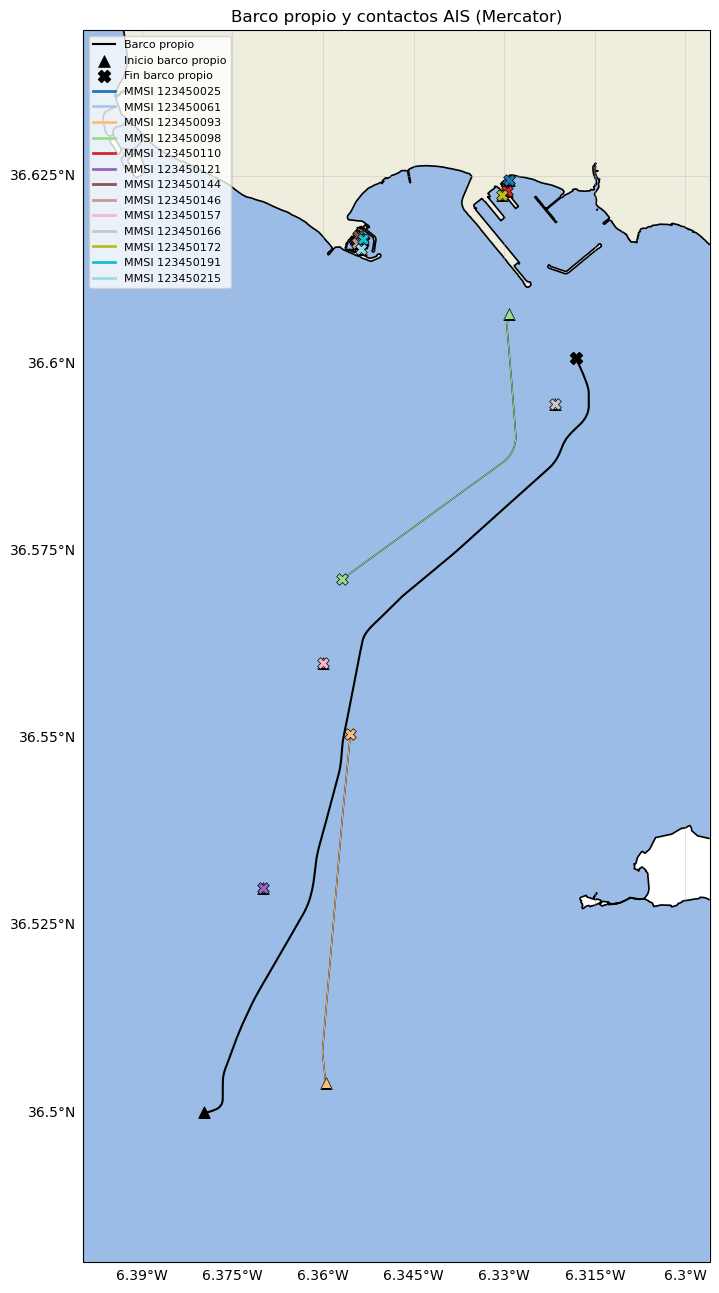

'figuras/bloque10_mapa_general.png'

In [172]:
plot_own_and_contacts_mercator(own_df, contacts_dict)

In [173]:
# ============================================================
# BLOQUE 11 CREACIÓN DEL DATAFRAME COMPLETO DEL BARCO PROPIO (LIMPIO + COMPLETO)
# ============================================================

import pandas as pd

# --------------------------------------------------
# Filtrado inicial: solo NMEA del barco propio
# --------------------------------------------------
df_nmea = df_barco_nmea.copy()
df_nmea = (
    df_nmea
    .dropna(subset=["time"])
    .sort_values("time")
    .reset_index(drop=True)
)

# --------------------------------------------------
# Helpers básicos de parseo NMEA
# --------------------------------------------------

def dm_to_deg(dm: str, is_lon: bool) -> float:
    deg_len = 3 if is_lon else 2
    deg = float(dm[:deg_len])
    minutes = float(dm[deg_len:])
    return deg + minutes / 60.0


def parse_gpgll(s: str):
    parts = s.split("*", 1)[0].split(",")
    if len(parts) < 6:
        return None
    lat_raw, lat_hemi = parts[1], parts[2]
    lon_raw, lon_hemi = parts[3], parts[4]
    if not lat_raw or not lon_raw:
        return None

    lat = dm_to_deg(lat_raw, is_lon=False)
    lon = dm_to_deg(lon_raw, is_lon=True)

    if lat_hemi == "S":
        lat = -lat
    if lon_hemi == "W":
        lon = -lon

    return {"lat": lat, "lon": lon}


def parse_gpvtg(s: str):
    parts = s.split("*", 1)[0].split(",")
    if len(parts) < 9:
        return None

    def f(x):
        try:
            return float(x)
        except:
            return None

    return {
        "cog_deg": f(parts[1]),
        "sog_kn": f(parts[5]),
    }


def parse_gphdt(s: str):
    parts = s.split("*", 1)[0].split(",")
    if len(parts) < 3:
        return None
    try:
        return {"heading": float(parts[1])}
    except:
        return None


def parse_vdvbw(s: str):
    parts = s.split("*", 1)[0].split(",")
    if len(parts) < 3:
        return None

    def f(x):
        try:
            return float(x)
        except:
            return None

    return {
        "water_speed": f(parts[1])
    }

# --------------------------------------------------
# Dispatcher de parsers (solo lo necesario)
# --------------------------------------------------
PARSERS = {
    "$GPGLL": parse_gpgll,
    "$GPVTG": parse_gpvtg,
    "$GPHDT": parse_gphdt,
    "$VDVBW": parse_vdvbw,
}

# --------------------------------------------------
# Construcción del DF "estado por segundo"
# --------------------------------------------------

rows = []

df_nmea["time_sec"] = df_nmea["time"].dt.floor("1s")

for t_sec, grp in df_nmea.groupby("time_sec"):
    row = {"time": t_sec}

    for s in grp["sentence"]:
        prefix = s.split(",", 1)[0]
        parser = PARSERS.get(prefix)
        if parser:
            d = parser(s)
            if d:
                row.update(d)

    rows.append(row)

own_full_df = (
    pd.DataFrame(rows)
    .sort_values("time")
    .reset_index(drop=True)
)



# --------------------------------------------------
# Eliminar velocidades físicamente imposibles
# --------------------------------------------------
own_full_df = own_full_df[
    own_full_df["sog_kn"].isna() | (own_full_df["sog_kn"] <= 40)
].reset_index(drop=True)

# --------------------------------------------------
# Selección FINAL de columnas (solo las útiles)
# --------------------------------------------------
KEEP_COLS = [
    "time",
    "lat",
    "lon",
    "cog_deg",
    "sog_kn",
    "water_speed",
    "heading",
]

own_full_df = own_full_df[[c for c in KEEP_COLS if c in own_full_df.columns]]

# --------------------------------------------------
# Guardado final
# --------------------------------------------------
own_full_df.to_csv("own_ship_full.csv", index=False)
print(f"own_ship_full.csv generado: {len(own_full_df)} filas")

display(own_full_df.head(100))


own_ship_full.csv generado: 3038 filas


,time,lat,lon,cog_deg,sog_kn,water_speed,heading
0,2026-03-12 11:17:40,NaN,NaN,NaN,NaN,0.0,90.0
1,2026-03-12 11:17:42,NaN,NaN,NaN,NaN,NaN,90.0
2,2026-03-12 11:17:45,NaN,NaN,NaN,NaN,0.0,90.0
3,2026-03-12 11:17:48,NaN,NaN,NaN,NaN,NaN,90.0
4,2026-03-12 11:17:51,NaN,NaN,NaN,NaN,0.0,90.0
...,...,...,...,...,...,...,...
95,2026-03-12 11:23:35,NaN,NaN,NaN,NaN,NaN,90.0
96,2026-03-12 11:23:38,NaN,NaN,NaN,NaN,0.0,90.0
97,2026-03-12 11:23:41,NaN,NaN,NaN,NaN,NaN,90.0
98,2026-03-12 11:23:44,NaN,NaN,NaN,NaN,0.0,90.0


In [174]:
# ============================================================
# BLOQUE 12 RELLENO INTERPOLADO DE VELOCIDAD Y RUMBO DE SUPERFICIE
# ============================================================

import numpy as np

# Asegurar índice temporal continuo a 1 Hz
own_full_df = own_full_df.set_index("time")

full_index = pd.date_range(
    own_full_df.index.min(),
    own_full_df.index.max(),
    freq="1s"
)

own_full_df = own_full_df.reindex(full_index)
own_full_df.index.name = "time"

# --------------------------------------------------
# Interpolación lineal para water_speed
# --------------------------------------------------
if "water_speed" in own_full_df.columns:
    own_full_df["water_speed"] = own_full_df["water_speed"].interpolate(
        method="linear",
        limit_direction="both"
    )

# Si sigue habiendo huecos → usar SOG
if "water_speed" in own_full_df.columns and "sog_kn" in own_full_df.columns:
    own_full_df["water_speed"] = own_full_df["water_speed"].fillna(
        own_full_df["sog_kn"]
    )

# --------------------------------------------------
# Interpolación angular correcta para heading
# --------------------------------------------------
def interpolate_angle(series):
    rad = np.deg2rad(series)
    sin = np.sin(rad)
    cos = np.cos(rad)

    sin_interp = pd.Series(sin, index=series.index).interpolate(limit_direction="both")
    cos_interp = pd.Series(cos, index=series.index).interpolate(limit_direction="both")

    angle = np.rad2deg(np.arctan2(sin_interp, cos_interp))
    return (angle + 360) % 360

if "heading" in own_full_df.columns:
    own_full_df["heading"] = interpolate_angle(own_full_df["heading"])

# Si aún falta heading → usar COG
if "heading" in own_full_df.columns and "cog_deg" in own_full_df.columns:
    own_full_df["heading"] = own_full_df["heading"].fillna(
        own_full_df["cog_deg"]
    )

own_full_df = own_full_df.reset_index()
own_full_df.to_csv("own_ship_full.csv", index=False)
print("own_ship_full.csv sobrescrito correctamente")


own_ship_full.csv sobrescrito correctamente


In [175]:
# ============================================================
# BLOQUE 13 SUAVIZA LA VELOCIDAD DEL PROPIO BARCO
# ============================================================

from pathlib import Path
import pandas as pd
from scipy.signal import savgol_filter

# -----------------------------------------------------
# ARCHIVO DE ENTRADA
# -----------------------------------------------------
csv_file = Path("own_ship_full.csv")   # ajusta el nombre si no coincide exactamente

# -----------------------------------------------------
# FUNCIÓN DE SUAVIZADO
# -----------------------------------------------------
def suavizar_velocidad(v, window=21, poly=1):
    v = pd.to_numeric(v, errors="coerce")

    # quitar NaN temporalmente para evitar problemas con Savitzky-Golay
    if v.notna().sum() < 3:
        return v

    v_interp = v.interpolate(limit_direction="both")

    # ajustar ventana si el tamaño es pequeño
    n = len(v_interp)
    if n < window:
        window = n if n % 2 == 1 else n - 1

    if window < 3:
        return v_interp

    if window % 2 == 0:
        window += 1
        if window > n:
            window -= 2

    poly = min(poly, window - 1)

    return savgol_filter(v_interp.to_numpy(), window_length=window, polyorder=poly)

# -----------------------------------------------------
# CARGA Y SUAVIZADO
# -----------------------------------------------------
df = pd.read_csv(csv_file, parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)

# usa la columna de velocidad que tenga tu own_ship_full
# cambia "sog_kn" por el nombre real si fuese distinto
vel_raw = df["sog_kn"].copy()

vel_s = suavizar_velocidad(vel_raw, window=21, poly=1)

# sobrescribir la columna original
df["sog_kn"] = vel_s

# guardar sobrescribiendo el archivo original
df.to_csv(csv_file, index=False)

print(f"{csv_file.name} → sog_kn sobrescrito con velocidad suavizada")

own_ship_full.csv → sog_kn sobrescrito con velocidad suavizada


In [176]:
# ============================================================
# BLOQUE 14 Recorta el tiempo del contacto posterior a la finalización del buque propio
# ============================================================
def limit_contact_to_own_time_and_report(df_contact, own_df, csv_name):

    df_contact["time"] = pd.to_datetime(df_contact["time"])
    own_df["time"] = pd.to_datetime(own_df["time"])

    t_end_own = own_df["time"].max()
    n_before = len(df_contact)

    df_filtered = df_contact[df_contact["time"] <= t_end_own].copy()
    n_after = len(df_filtered)

    removed = n_before - n_after

    if removed > 0:
        print(f"✓ {csv_name} recortado al tiempo del barco propio "
              f"({removed} filas eliminadas)")
    else:
        print(f"✓ {csv_name} ya estaba dentro del intervalo temporal")

    return df_filtered

In [177]:
from pathlib import Path

CONTACTS_DIR = Path("ais_contacts")
ais_contacts = list(CONTACTS_DIR.glob("*.csv"))

print(f"{len(ais_contacts)} contactos detectados")


13 contactos detectados


In [178]:
for csv_path in ais_contacts:

    df_contact = pd.read_csv(csv_path)

    df_contact = limit_contact_to_own_time_and_report(
        df_contact,
        own_df,
        csv_path.name
    )

    df_contact.to_csv(csv_path, index=False)

print("\n✔ Filtrado temporal de contactos completado correctamente.")



✓ ais_123450025.csv ya estaba dentro del intervalo temporal
✓ ais_123450061.csv ya estaba dentro del intervalo temporal
✓ ais_123450093.csv ya estaba dentro del intervalo temporal
✓ ais_123450098.csv ya estaba dentro del intervalo temporal
✓ ais_123450110.csv ya estaba dentro del intervalo temporal
✓ ais_123450121.csv ya estaba dentro del intervalo temporal
✓ ais_123450144.csv ya estaba dentro del intervalo temporal
✓ ais_123450146.csv ya estaba dentro del intervalo temporal
✓ ais_123450157.csv ya estaba dentro del intervalo temporal
✓ ais_123450166.csv ya estaba dentro del intervalo temporal
✓ ais_123450172.csv ya estaba dentro del intervalo temporal
✓ ais_123450191.csv ya estaba dentro del intervalo temporal
✓ ais_123450215.csv ya estaba dentro del intervalo temporal

✔ Filtrado temporal de contactos completado correctamente.


In [179]:
# ============================================================
# BLOQUE 15 Depurado información contactos
# ============================================================

from pathlib import Path
import pandas as pd
import shutil

# =====================================================
# PARÁMETROS
# =====================================================
INPUT_DIR = Path("ais_contacts")
OVERWRITE = True          # pon False si quieres una carpeta nueva

OUTPUT_DIR = Path("ais_contacts_cleaned")

if OVERWRITE:
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)  # elimina carpeta completa
    OUTPUT_DIR.mkdir()
else:
    OUTPUT_DIR.mkdir(exist_ok=True)

# ORDEN FINAL EXACTO (COMO EN LA IMAGEN)
FINAL_COLUMNS = [
    "mmsi",
    "lat",
    "lon",
    "cog_deg",
    "sog_kn",
    "heading_deg",
    "time",
    "length",
    "beam"
]

# =====================================================
# PROCESAR CSV AIS
# =====================================================
for csv_file in sorted(INPUT_DIR.glob("ais_*.csv")):

    df = pd.read_csv(csv_file)

    # Comprobación estricta
    missing = [c for c in FINAL_COLUMNS if c not in df.columns]
    if missing:
        print(f"⚠️ {csv_file.name} → faltan columnas: {missing}")
        continue

    # Depuración y reordenación
    df_clean = df[FINAL_COLUMNS].copy()

    # Guardado
    if OVERWRITE:
        df_clean.to_csv(csv_file, index=False)
        print(f"✓ Depurado: {csv_file.name}")
    else:
        out = OUTPUT_DIR / csv_file.name
        df_clean.to_csv(out, index=False)
        print(f"✓ Depurado: {out.name}")


✓ Depurado: ais_123450025.csv
✓ Depurado: ais_123450061.csv
✓ Depurado: ais_123450093.csv
✓ Depurado: ais_123450098.csv
✓ Depurado: ais_123450110.csv
✓ Depurado: ais_123450121.csv
✓ Depurado: ais_123450144.csv
✓ Depurado: ais_123450146.csv
✓ Depurado: ais_123450157.csv
✓ Depurado: ais_123450166.csv
✓ Depurado: ais_123450172.csv
✓ Depurado: ais_123450191.csv
✓ Depurado: ais_123450215.csv


In [180]:
# =====================================================
# BLOQUE 16 - FILTRO 1: ELIMINAR BARCOS EN PUERTO
# Criterio:
#   - SIEMPRE dentro de alguna de las ZONAS DE PUERTO
# =====================================================

from shapely.geometry import Point, Polygon
import pandas as pd

def _rect_from_center(lat_c, lon_c, d_lat, d_lon, name):
    return {
        "name": name,
        "lat_min": lat_c - d_lat, "lat_max": lat_c + d_lat,
        "lon_min": lon_c - d_lon, "lon_max": lon_c + d_lon
    }

def _rect_from_bbox(lat_min, lat_max, lon_min, lon_max, name):
    return {
        "name": name,
        "lat_min": lat_min, "lat_max": lat_max,
        "lon_min": lon_min, "lon_max": lon_max
    }

def _poly_from_points(points, name):
    """
    points = [(lat, lon), (lat, lon), ...]
    """
    return {
        "name": name,
        "points": points
    }

# -----------------------------------------------------
# ZONAS DE PUERTO (ROTA)
# -----------------------------------------------------
PORT_ZONES = [

    # 1) Base Naval de Rota
    _rect_from_bbox(
        lat_min=36 + 34.5/60,
        lat_max=36 + 35.0/60,
        lon_min=-(6 + 15.8/60),
        lon_max=-(6 + 14.8/60),
        name="Base Naval de Rota"
    ),

    # 2) Puerto de Rota
    _rect_from_bbox(
        lat_min=36 + 36.8/60,
        lat_max=36 + 37.2/60,
        lon_min=-(6 + 21.5/60),
        lon_max=-(6 + 21.1/60),
        name="Puerto de Rota"
    ),

    # 3) Entrada puerto / dique exterior
    _poly_from_points(
        points=[
            (36 + 37.3/60, -(6 + 20.2/60)),
            (36 + 36.6/60, -(6 + 19.5/60)),
            (36 + 37.3/60, -(6 + 19.1/60)),
            (36 + 37.7/60, -(6 + 19.5/60)),
        ],
        name="Entrada puerto Rota"
    ),
]

def point_in_zone(lat, lon, z):
    """
    Compatible con:
    - zonas rectangulares (lat/lon min-max)
    - zonas poligonales (points)
    """
    if all(k in z for k in ["lat_min", "lat_max", "lon_min", "lon_max"]):
        return (
            z["lat_min"] <= lat <= z["lat_max"]
            and z["lon_min"] <= lon <= z["lon_max"]
        )

    elif "points" in z:
        p = Point(lon, lat)
        poly = Polygon([(lo, la) for la, lo in z["points"]])
        return poly.contains(p) or poly.touches(p)

    return False

def point_in_any_zone(lat, lon, zones):
    for z in zones:
        if point_in_zone(lat, lon, z):
            return True
    return False

# -----------------------------------------------------
# DETECCIÓN
# -----------------------------------------------------
mmsi_in_port = []
mmsi_port_zone = {}

for mmsi, dfc in list(contacts_dict.items()):

    if dfc is None or dfc.empty:
        continue
    if not {"lat", "lon"}.issubset(dfc.columns):
        continue

    lats = pd.to_numeric(dfc["lat"], errors="coerce")
    lons = pd.to_numeric(dfc["lon"], errors="coerce")
    valid = lats.notna() & lons.notna()

    if valid.sum() == 0:
        continue

    inside_flags = []
    zones_hit = set()

    for lat, lon in zip(lats[valid], lons[valid]):
        in_any = False
        for z in PORT_ZONES:
            if point_in_zone(lat, lon, z):
                in_any = True
                zones_hit.add(z["name"])
                break
        inside_flags.append(in_any)

    # Se considera en puerto si TODOS sus puntos válidos están dentro
    if inside_flags and all(inside_flags):
        mmsi_in_port.append(mmsi)
        mmsi_port_zone[mmsi] = ", ".join(sorted(zones_hit)) if zones_hit else "Zona puerto"

# -----------------------------------------------------
# RESULTADO
# -----------------------------------------------------
print("\n🛑 CONTACTOS ELIMINADOS POR ESTAR SIEMPRE DENTRO DE ZONAS DE PUERTO:")
if mmsi_in_port:
    for m in mmsi_in_port:
        print(f" - MMSI {m}  |  Zona(s): {mmsi_port_zone.get(m, '—')}")
else:
    print("Ninguno")

# -----------------------------------------------------
# ELIMINACIÓN REAL
# -----------------------------------------------------
for m in mmsi_in_port:
    contacts_dict.pop(m, None)

print(f"\nContactos restantes tras filtro de puerto: {len(contacts_dict)}")



🛑 CONTACTOS ELIMINADOS POR ESTAR SIEMPRE DENTRO DE ZONAS DE PUERTO:
 - MMSI 123450025  |  Zona(s): Entrada puerto Rota
 - MMSI 123450061  |  Zona(s): Puerto de Rota
 - MMSI 123450110  |  Zona(s): Entrada puerto Rota
 - MMSI 123450144  |  Zona(s): Puerto de Rota
 - MMSI 123450146  |  Zona(s): Puerto de Rota
 - MMSI 123450172  |  Zona(s): Entrada puerto Rota
 - MMSI 123450191  |  Zona(s): Puerto de Rota
 - MMSI 123450215  |  Zona(s): Puerto de Rota

Contactos restantes tras filtro de puerto: 5



🚫 Contactos eliminados por estar siempre a > 4 MN:
  Ninguno

✅ Contactos restantes tras filtro de distancia: 5

📍 Representación tras eliminar contactos lejanos y contactos en puerto


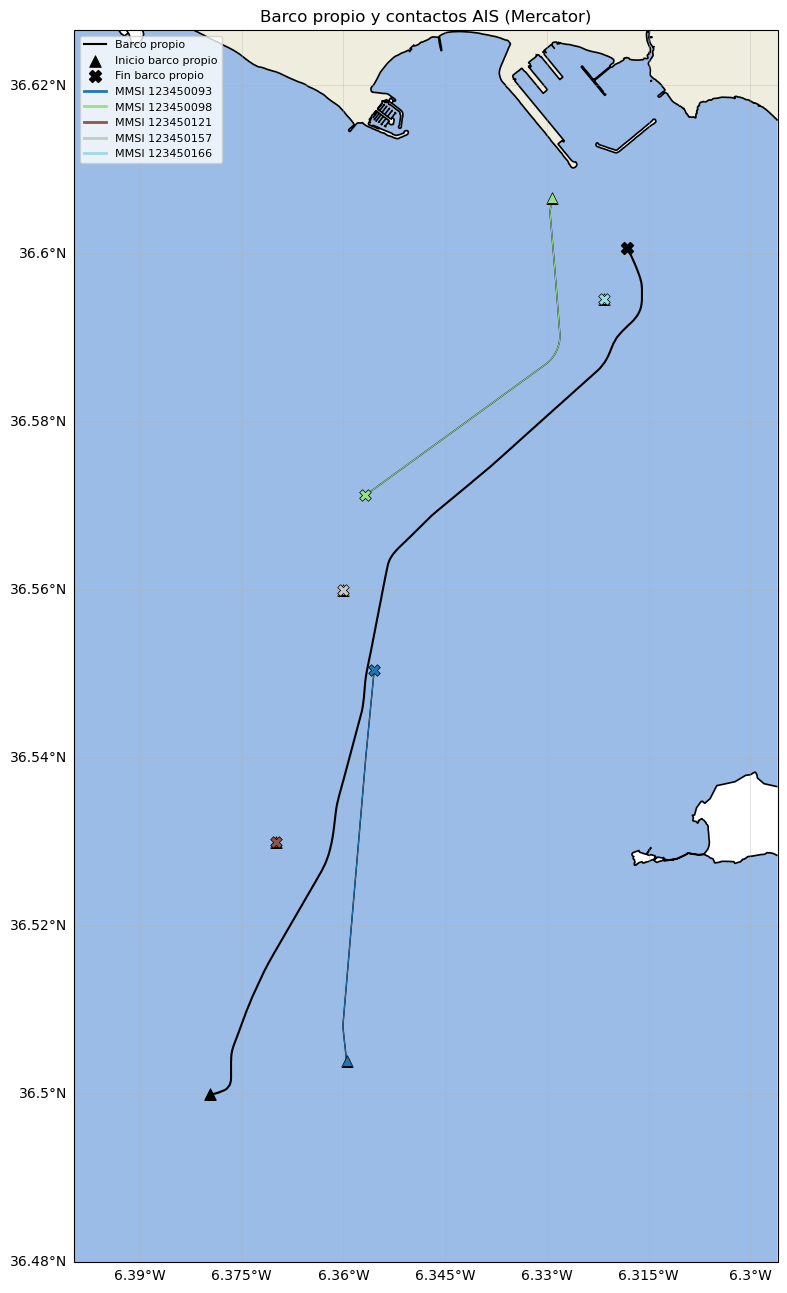


📁 Imagen guardada en:
figuras/bloque11_post_filtro_distancia.png


In [181]:
# =====================================================
# BLOQUE 17 — FILTRO POR DISTANCIA AL BARCO PROPIO (> 4 MN)
# + REPRESENTACIÓN con costa
# =====================================================
import numpy as np
import pandas as pd

MAX_DIST_MN = 4
MAX_DIST_M = MAX_DIST_MN * 1852  # metros

def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371000  # radio Tierra en metros
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# -------------------------
# Copia del diccionario (para no destruir el original)
# -------------------------
contacts_dict_filtrado = {k: v.copy() for k, v in contacts_dict.items() if v is not None}

removed_far = []

for mmsi, dfc in list(contacts_dict_filtrado.items()):

    if dfc is None or dfc.empty:
        removed_far.append(mmsi)
        del contacts_dict_filtrado[mmsi]
        continue

    # Asegurar datetime (por si acaso)
    if "time" in own_df.columns:
        own_df["time"] = pd.to_datetime(own_df["time"], errors="coerce")
    if "time" in dfc.columns:
        dfc["time"] = pd.to_datetime(dfc["time"], errors="coerce")

    # Cruce temporal exacto
    merged = pd.merge(
        own_df[["time", "lat", "lon"]],
        dfc[["time", "lat", "lon"]],
        on="time",
        suffixes=("_own", "_ctc")
    )

    if merged.empty:
        removed_far.append(mmsi)
        del contacts_dict_filtrado[mmsi]
        continue

    # Cálculo de distancias
    merged["dist_m"] = haversine_vec(
        merged["lat_own"].values,
        merged["lon_own"].values,
        merged["lat_ctc"].values,
        merged["lon_ctc"].values
    )

    min_dist = merged["dist_m"].min()

    # Filtro por distancia
    if min_dist > MAX_DIST_M:
        removed_far.append(mmsi)
        del contacts_dict_filtrado[mmsi]
        continue

    # Guardar distancia sin conflictos
    if "dist_m" in dfc.columns:
        dfc = dfc.drop(columns=["dist_m"])

    dist_map = merged.set_index("time")["dist_m"]
    dfc["dist_m"] = dfc["time"].map(dist_map)

    contacts_dict_filtrado[mmsi] = dfc

# -------------------------
# INFORME
# -------------------------
print(f"\n🚫 Contactos eliminados por estar siempre a > {MAX_DIST_MN} MN:")
if removed_far:
    for m in removed_far:
        print(f"  - MMSI {m}")
else:
    print("  Ninguno")

print(f"\n✅ Contactos restantes tras filtro de distancia: {len(contacts_dict_filtrado)}")
print("\n📍 Representación tras eliminar contactos lejanos y contactos en puerto")

# -------------------------
# REPRESENTACIÓN (misma costa)
# -------------------------
if not contacts_dict_filtrado:
    print("No quedan contactos AIS relevantes para representar.")
    ruta_imagen_2 = None
else:
    ruta_imagen_2 = plot_own_and_contacts_mercator(
        own_df=own_df,
        contacts_dict=contacts_dict_filtrado,
        margin_deg=0.02,
        save_path="figuras/bloque11_post_filtro_distancia.png",
        # opcional: mismos parámetros de fondo
        coast_step_deg=0.00005,
        land_fc="#efeede",
        sea_fc="#9bbce6"
    )

print("\n📁 Imagen guardada en:")
print(ruta_imagen_2)

# Si quieres que a partir de aquí el resto del pipeline use el filtrado:
# contacts_dict = contacts_dict_filtrado

In [182]:
# Comprobar detección
print("Puerto:", mmsi_in_port)
print("Lejanos:", removed_far)


Puerto: [123450025, 123450061, 123450110, 123450144, 123450146, 123450172, 123450191, 123450215]
Lejanos: []


In [183]:
# =====================================================
# BLOQUE 18- CREAR CARPETA CON CONTACTOS DEFINITIVOS A ANALIZAR
# =====================================================
from pathlib import Path
import shutil

SOURCE_DIR = Path("ais_contacts")
TARGET_DIR = Path("contacts_to_analyse")

if OVERWRITE:
    if TARGET_DIR.exists():
        shutil.rmtree(TARGET_DIR)  # elimina carpeta completa
    TARGET_DIR.mkdir()
else:
    TARGET_DIR.mkdir(exist_ok=True)

print("\n📁 Creando carpeta 'contacts_to_analyse' con contactos válidos\n")

copied = 0

for mmsi in contacts_dict.keys():
    src = SOURCE_DIR / f"ais_{mmsi}.csv"
    dst = TARGET_DIR / f"ais_{mmsi}.csv"

    if src.exists():
        shutil.copy(src, dst)
        copied += 1
        print(f"  ✔ Copiado MMSI {mmsi}")
    else:
        print(f"  ⚠ No encontrado CSV para MMSI {mmsi}")

print(f"\n✅ Contactos copiados para análisis: {copied}")
print(f"📂 Carpeta final: {TARGET_DIR.resolve()}")



📁 Creando carpeta 'contacts_to_analyse' con contactos válidos

  ✔ Copiado MMSI 123450093
  ✔ Copiado MMSI 123450098
  ✔ Copiado MMSI 123450121
  ✔ Copiado MMSI 123450157
  ✔ Copiado MMSI 123450166

✅ Contactos copiados para análisis: 5
📂 Carpeta final: C:\Users\rodri\OneDrive\Escritorio\PROGRAMACION\VERSIONES FINALES\RIPAM\RIPAM ROTA\contacts_to_analyse


In [184]:
#Bloque 19 reordenar contactos por el orden lógico y riguroso
import os
import glob
import pandas as pd

# =====================================================
# PARÁMETROS
# =====================================================
INPUT_DIR = "contacts_to_analyse"          # carpeta de entrada
OVERWRITE = True                    # True = sobrescribe / False = guarda copia



# Columnas finales deseadas (orden exacto)
FINAL_COLUMNS = [
    "mmsi",
    "time",
    "lat",
    "lon",
    "cog_deg",
    "sog_kn",
    "heading_deg",
    "length",
    "beam"
]

# =====================================================
# PROCESAR TODOS LOS CSV
# =====================================================
for filepath in glob.glob(os.path.join(INPUT_DIR, "*.csv")):

    df = pd.read_csv(filepath)

    # Comprobar columnas mínimas necesarias
    missing = [c for c in FINAL_COLUMNS if c not in df.columns]
    if missing:
        print(f" {os.path.basename(filepath)}: faltan columnas {missing}")
        continue

    # Reordenar y eliminar el resto
    df_clean = df[FINAL_COLUMNS].copy()

    # Guardar resultado
    if OVERWRITE:
        df_clean.to_csv(filepath, index=False)
        print(f"✓ Sobrescrito: {os.path.basename(filepath)}")
    else:
        out = os.path.join(OUTPUT_DIR, os.path.basename(filepath))
        df_clean.to_csv(out, index=False)
        print(f"✓ Guardado limpio: {out}")


✓ Sobrescrito: ais_123450093.csv
✓ Sobrescrito: ais_123450098.csv
✓ Sobrescrito: ais_123450121.csv
✓ Sobrescrito: ais_123450157.csv
✓ Sobrescrito: ais_123450166.csv


In [185]:
#Bloque 20- Información conjunta buque propio y contacto

from pathlib import Path
import pandas as pd

AIS_DIR = Path("contacts_to_analyse")
OWN_SHIP_FILE = Path("own_ship_full.csv")

MAX_TIME_DIFF = pd.Timedelta(seconds=5)

# -------------------------------------------------
# BARCO PROPIO
# -------------------------------------------------
own = pd.read_csv(OWN_SHIP_FILE)
own["time"] = pd.to_datetime(own["time"], errors="coerce")

own = own[
    ["time", "lat", "lon", "cog_deg", "sog_kn", "water_speed", "heading"]
].rename(
    columns={
        "lat": "lat_ship",
        "lon": "lon_ship",
        "cog_deg": "cog_deg_ship",
        "sog_kn": "sog_kn_ship",
        "water_speed": "water_speed_ship",
        "heading": "heading_ship"
    }
)

own = own.sort_values("time").reset_index(drop=True)

# -------------------------------------------------
# CONTACTOS AIS
# -------------------------------------------------
for csv_file in AIS_DIR.glob("ais_*.csv"):

    df = pd.read_csv(csv_file)
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.sort_values("time").reset_index(drop=True)

    # Merge temporal limpio
    df = pd.merge_asof(
        df,
        own,
        on="time",
        direction="nearest",
        tolerance=MAX_TIME_DIFF
    )

    # Asegurar columnas opcionales
    for col in ["length", "beam"]:
        if col not in df.columns:
            df[col] = pd.NA

    # Orden final EXACTO
    final_cols = [
        "mmsi",
        "time",
        "lat", "lat_ship",
        "lon", "lon_ship",
        "cog_deg","cog_deg_ship",
        "sog_kn","sog_kn_ship","water_speed_ship",
        "heading_deg","heading_ship",
        "length",
        "beam"
    ]

    df = df[final_cols]

    # Guardar
    df.to_csv(csv_file, index=False)

    print(f"✓ Sincronizado y normalizado → {csv_file.name}")

    #creada una tabla en contacts table que recoge toda la informacion de ais mas los contactos

✓ Sincronizado y normalizado → ais_123450093.csv
✓ Sincronizado y normalizado → ais_123450098.csv
✓ Sincronizado y normalizado → ais_123450121.csv
✓ Sincronizado y normalizado → ais_123450157.csv
✓ Sincronizado y normalizado → ais_123450166.csv


In [186]:
# Bloque 21 Interpolación información ausente

from pathlib import Path
import pandas as pd
import numpy as np

AIS_DIR = Path("contacts_to_analyse")

CRITICAL_COLS = [
    "lat_ship",
    "lon_ship",
    "cog_deg_ship",
    "sog_kn_ship"
]

print("=== INTERPOLACIÓN QUIRÚRGICA (SIN REINDEXAR) ===\n")

def interpolate_angle(series):
    rad = np.deg2rad(series)
    sin = np.sin(rad)
    cos = np.cos(rad)

    sin_interp = pd.Series(sin, index=series.index).interpolate(limit_direction="both")
    cos_interp = pd.Series(cos, index=series.index).interpolate(limit_direction="both")

    angle = np.rad2deg(np.arctan2(sin_interp, cos_interp))
    return (angle + 360) % 360


for csv_file in AIS_DIR.glob("ais_*.csv"):

    df = pd.read_csv(csv_file)

    missing_cols = [c for c in CRITICAL_COLS if c not in df.columns]
    if missing_cols:
        print(f"❌ {csv_file.name} → columnas inexistentes: {missing_cols}")
        continue

    # Comprobar si hay NaN
    if not df[CRITICAL_COLS].isna().any().any():
        print(f"✓ {csv_file.name} → sin NaN (no modificado)")
        continue

    print(f"⚙ {csv_file.name} → interpolando columnas críticas...")

    # Interpolación lineal (sin tocar estructura temporal)
    for col in ["lat_ship", "lon_ship", "sog_kn_ship"]:
        df[col] = df[col].interpolate(method="linear", limit_direction="both")

    # Interpolación angular para COG
    df["cog_deg_ship"] = interpolate_angle(df["cog_deg_ship"])

    df.to_csv(csv_file, index=False)

    print(f"✓ {csv_file.name} → corregido y sobrescrito")

print("\n=== FIN ===")


=== INTERPOLACIÓN QUIRÚRGICA (SIN REINDEXAR) ===

⚙ ais_123450093.csv → interpolando columnas críticas...
✓ ais_123450093.csv → corregido y sobrescrito
⚙ ais_123450098.csv → interpolando columnas críticas...
✓ ais_123450098.csv → corregido y sobrescrito
⚙ ais_123450121.csv → interpolando columnas críticas...
✓ ais_123450121.csv → corregido y sobrescrito
⚙ ais_123450157.csv → interpolando columnas críticas...
✓ ais_123450157.csv → corregido y sobrescrito
⚙ ais_123450166.csv → interpolando columnas críticas...
✓ ais_123450166.csv → corregido y sobrescrito

=== FIN ===


In [187]:
#Bloque 22- Comprobación información actualizada

from pathlib import Path
import pandas as pd

AIS_DIR = Path("contacts_to_analyse")

COLUMNS_TO_CHECK = [
    "mmsi",
    "time",
    "lat", "lat_ship",
    "lon", "lon_ship",
    "cog_deg", "cog_deg_ship",
    "sog_kn", "sog_kn_ship",
    "water_speed_ship",
    "heading_deg", "heading_ship",
    "length",
    "beam"
]

print("=== CALIDAD DE DATOS POR ARCHIVO ===\n")

for csv_file in AIS_DIR.glob("ais_*.csv"):

    df = pd.read_csv(csv_file)
    total_rows = len(df)

    print(f"\n📄 {csv_file.name} (filas: {total_rows})")

    for col in COLUMNS_TO_CHECK:

        if col not in df.columns:
            print(f"  ❌ {col:<20} → columna inexistente")
            continue

        missing = df[col].isna().sum()
        pct = (missing / total_rows * 100) if total_rows > 0 else 0

        print(
            f"  {col:<20} → {missing:>6} sin datos "
            f"({pct:6.2f} %)"
        )

        # 🔥 Mostrar filas con NaN (máximo 5 para no saturar)
        if missing > 0:
            print("     → Ejemplo de filas con datos faltantes:")
            print(
                df[df[col].isna()]
                .head(5)[["time", col]]
            )

    print("-" * 60)

print("\n=== FIN DEL INFORME ===")

=== CALIDAD DE DATOS POR ARCHIVO ===


📄 ais_123450093.csv (filas: 543)
  mmsi                 →      0 sin datos (  0.00 %)
  time                 →      0 sin datos (  0.00 %)
  lat                  →      0 sin datos (  0.00 %)
  lat_ship             →      0 sin datos (  0.00 %)
  lon                  →      0 sin datos (  0.00 %)
  lon_ship             →      0 sin datos (  0.00 %)
  cog_deg              →      0 sin datos (  0.00 %)
  cog_deg_ship         →      0 sin datos (  0.00 %)
  sog_kn               →      0 sin datos (  0.00 %)
  sog_kn_ship          →      0 sin datos (  0.00 %)
  water_speed_ship     →      0 sin datos (  0.00 %)
  heading_deg          →      0 sin datos (  0.00 %)
  heading_ship         →      0 sin datos (  0.00 %)
  length               →      0 sin datos (  0.00 %)
  beam                 →      0 sin datos (  0.00 %)
------------------------------------------------------------

📄 ais_123450098.csv (filas: 543)
  mmsi                 →      0 sin da

In [188]:
#Bloque 23- Cálculo de la marcación relativa y demora

from pathlib import Path
import pandas as pd
import numpy as np

AIS_DIR = Path("contacts_to_analyse")

print("=== CÁLCULO DE MARCACIÓN RELATIVA Y DEMORA ===\n")

def bearing_relative(lat_ship, lon_ship, lat_tgt, lon_tgt, cog_ship):
    """
    Calcula la marcación relativa (0–359°)
    desde el barco propio hacia el contacto AIS
    """
    # Convertir a radianes
    lat1 = np.radians(lat_ship)
    lat2 = np.radians(lat_tgt)
    dlon = np.radians(lon_tgt - lon_ship)

    # Bearing absoluto (respecto al norte)
    x = np.sin(dlon) * np.cos(lat2)
    y = (
        np.cos(lat1) * np.sin(lat2)
        - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    )

    bearing_abs = (np.degrees(np.arctan2(x, y)) + 360) % 360

    # Marcación relativa a la proa
    bearing_rel = (bearing_abs - cog_ship) % 360

    return bearing_rel,bearing_abs


for csv_file in AIS_DIR.glob("ais_*.csv"):

    df = pd.read_csv(csv_file)
    total_rows = len(df)

    # Obtener ambas marcaciones
    bearing_rel, bearing_true = bearing_relative(
        df["lat_ship"],
        df["lon_ship"],
        df["lat"],
        df["lon"],
        df["cog_deg_ship"]
    )

    # Guardarlas en columnas separadas
    df["bearing"] = bearing_rel.round(2)
    df["bearing_true"] = bearing_true.round(2)

    # Reordenar columnas: poner ambas después de lon_ship
    cols = list(df.columns)
    cols.remove("bearing")
    cols.remove("bearing_true")

    idx = cols.index("lon_ship") + 1
    cols.insert(idx, "bearing")
    cols.insert(idx + 1, "bearing_true")

    df = df[cols]

    df.to_csv(csv_file, index=False)

    print(f"✓ {csv_file.name} → marcaciones calculadas ({total_rows} filas)")

print("\n=== FIN DEL CÁLCULO DE MARCACIÓN Y DEMORA ===")



=== CÁLCULO DE MARCACIÓN RELATIVA Y DEMORA ===

✓ ais_123450093.csv → marcaciones calculadas (543 filas)
✓ ais_123450098.csv → marcaciones calculadas (543 filas)
✓ ais_123450121.csv → marcaciones calculadas (543 filas)
✓ ais_123450157.csv → marcaciones calculadas (543 filas)
✓ ais_123450166.csv → marcaciones calculadas (543 filas)

=== FIN DEL CÁLCULO DE MARCACIÓN Y DEMORA ===


In [189]:
#BLOQUE 24- CALCULO DISTANCIA ENTRE EL BARCO Y LOS CONTACTOS (EN YARDAS)
from pathlib import Path
import pandas as pd
import numpy as np

AIS_DIR = Path("contacts_to_analyse")

print("=== CÁLCULO DE DISTANCIA A YARDAS ===\n")

def haversine_nm(lat1, lon1, lat2, lon2):
    R = 3440.065  # Radio de la Tierra en millas náuticas

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


NM_TO_YARDS = 2025.37183

for csv_file in AIS_DIR.glob("ais_*.csv"):

    df = pd.read_csv(csv_file)

    # Distancia en yardas (2 decimales)
    df["distance"] = (
        haversine_nm(
            df["lat_ship"],
            df["lon_ship"],
            df["lat"],
            df["lon"]
        ) * NM_TO_YARDS
    ).round(2)

    # Colocar distance justo después de bearing
    cols = list(df.columns)
    cols.remove("distance")

    if "bearing" in cols:
        idx = cols.index("bearing") + 1
    else:
        idx = cols.index("lon_ship") + 1

    cols.insert(idx, "distance")
    df = df[cols]

    df.to_csv(csv_file, index=False)

    print(f"✓ {csv_file.name} → distancia calculada en yardas")

print("\n=== FIN DEL CÁLCULO ===")


=== CÁLCULO DE DISTANCIA A YARDAS ===

✓ ais_123450093.csv → distancia calculada en yardas
✓ ais_123450098.csv → distancia calculada en yardas
✓ ais_123450121.csv → distancia calculada en yardas
✓ ais_123450157.csv → distancia calculada en yardas
✓ ais_123450166.csv → distancia calculada en yardas

=== FIN DEL CÁLCULO ===


In [190]:
#Bloque 25 Cálculo de DCPA y TCPA

from pathlib import Path
import pandas as pd
import numpy as np

AIS_DIR = Path("contacts_to_analyse")

NM_TO_YARDS = 2025.37183
KNOTS_TO_YARDS_PER_SEC = NM_TO_YARDS / 3600

print("=== CÁLCULO DE DCPA / TCPA ===\n")


def compute_cpa_tcpa(row):
    # -------------------------
    # 1) Posición relativa inicial (yardas)
    # -------------------------
    mean_lat = np.radians((row["lat"] + row["lat_ship"]) / 2)

    dx = (row["lon"] - row["lon_ship"]) * 60 * np.cos(mean_lat) * NM_TO_YARDS
    dy = (row["lat"] - row["lat_ship"]) * 60 * NM_TO_YARDS

    r0 = np.array([dx, dy])

    # -------------------------
    # 2) Velocidades (yardas/s)
    # -------------------------
    cog_tgt = np.radians(row["cog_deg"])
    cog_ship = np.radians(row["cog_deg_ship"])

    vt = row["sog_kn"] * KNOTS_TO_YARDS_PER_SEC
    vs = row["sog_kn_ship"] * KNOTS_TO_YARDS_PER_SEC

    v_tgt = np.array([
        vt * np.sin(cog_tgt),
        vt * np.cos(cog_tgt)
    ])

    v_ship = np.array([
        vs * np.sin(cog_ship),
        vs * np.cos(cog_ship)
    ])

    # -------------------------
    # 3) Velocidad relativa
    # -------------------------
    v_rel = v_tgt - v_ship
    v_rel_sq = np.dot(v_rel, v_rel)

    if v_rel_sq < 1e-6:
        return pd.Series([np.linalg.norm(r0), 0.0])

    # -------------------------
    # 4) TCPA
    # -------------------------
    tcpa = - np.dot(r0, v_rel) / v_rel_sq

    # -------------------------
    # 5) CPA
    # -------------------------
    r_cpa = r0 + v_rel * tcpa
    cpa = np.linalg.norm(r_cpa)

    return pd.Series([cpa, tcpa])


for csv_file in AIS_DIR.glob("ais_*.csv"):

    df = pd.read_csv(csv_file)

    # Calcular CPA y TCPA
    df[["dcpa", "tcpa"]] = df.apply(compute_cpa_tcpa, axis=1)

    df["dcpa"] = df["dcpa"].round(2)     # yardas
    df["tcpa"] = df["tcpa"].round(1)   # segundos

    # --- ORDEN: justo después de distance ---
    cols = list(df.columns)
    cols.remove("dcpa")
    cols.remove("tcpa")

    idx = cols.index("distance") + 1
    cols.insert(idx, "dcpa")
    cols.insert(idx + 1, "tcpa")

    df = df[cols]

    df.to_csv(csv_file, index=False)

    print(f"✓ {csv_file.name} → DCPA y TCPA añadidos tras distance")

print("\n=== FIN DEL BLOQUE DCPA / TCPA ===")


=== CÁLCULO DE DCPA / TCPA ===

✓ ais_123450093.csv → DCPA y TCPA añadidos tras distance
✓ ais_123450098.csv → DCPA y TCPA añadidos tras distance
✓ ais_123450121.csv → DCPA y TCPA añadidos tras distance
✓ ais_123450157.csv → DCPA y TCPA añadidos tras distance
✓ ais_123450166.csv → DCPA y TCPA añadidos tras distance

=== FIN DEL BLOQUE DCPA / TCPA ===


In [191]:
# Bloque 26 Suavizado de la velocidad buque propio

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

INPUT_DIR = Path("contacts_to_analyse")
OUTPUT_DIR = Path("contacts_to_analyse")  # mismo sitio = sobrescribe los CSV

def suavizar_velocidad(v, window=21, poly=1):
    v = pd.to_numeric(v, errors="coerce")
    if len(v) < window:
        return v
    # Savgol necesita window impar y poly < window
    if window % 2 == 0:
        window += 1
    poly = min(poly, window - 1)
    return savgol_filter(v.to_numpy(), window, poly)

for csv_file in INPUT_DIR.glob("*.csv"):

    df = pd.read_csv(csv_file, parse_dates=["time"])
    df = df.sort_values("time").reset_index(drop=True)

    # Señal original (solo para comparar en la gráfica)
    vel_raw = df["sog_kn_ship"].copy()

    # Señal suavizada
    vel_s = suavizar_velocidad(vel_raw)

    # ✅ Sobrescribir la columna original (sin crear columna nueva)
    df["sog_kn_ship"] = vel_s

    print(f"{csv_file.name} → sog_kn_ship sobrescrito con velocidad suavizada")

ais_123450093.csv → sog_kn_ship sobrescrito con velocidad suavizada
ais_123450098.csv → sog_kn_ship sobrescrito con velocidad suavizada
ais_123450121.csv → sog_kn_ship sobrescrito con velocidad suavizada
ais_123450157.csv → sog_kn_ship sobrescrito con velocidad suavizada
ais_123450166.csv → sog_kn_ship sobrescrito con velocidad suavizada


In [192]:
# =====================================================
# BLOQUE 27— CORRECCIÓN ROBUSTA DE RUMBOS ERRÁTICOS
# EN TRAMOS DE BAJA VELOCIDAD PARA CONTACTOS
# =====================================================

import pandas as pd
import numpy as np
import glob
import os

CONTACTS_DIR = "contacts_to_analyse"

# -------------------------
# PARÁMETROS
# -------------------------
STOP_SOG = 0.5              # kn
MIN_TRAMO = 5               # mínimo nº de muestras consecutivas
RUMBO_STD_MIN = 20          # dispersión mínima para considerar errático
JUMP_ANGLE = 45             # salto angular grande entre muestras
JUMP_RATIO_MIN = 0.35       # % mínimo de saltos grandes dentro del tramo
VENTANA_REF = 8             # muestras antes/después para fijar rumbo

files = glob.glob(os.path.join(CONTACTS_DIR, "*.csv"))

print(f"\n🔎 Analizando {len(files)} contactos...\n")

# -----------------------------------------------------
# HELPERS
# -----------------------------------------------------
def circular_mean_deg(angles_deg):
    a = pd.to_numeric(pd.Series(angles_deg), errors="coerce").dropna()
    if a.empty:
        return np.nan

    rad = np.deg2rad(a)
    s = np.sin(rad).mean()
    c = np.cos(rad).mean()
    ang = np.rad2deg(np.arctan2(s, c))

    if ang < 0:
        ang += 360
    return ang

def angular_diff_deg(a, b):
    d = abs(a - b) % 360
    return min(d, 360 - d)

def circular_std_deg(angles_deg):
    a = pd.to_numeric(pd.Series(angles_deg), errors="coerce").dropna()
    if len(a) < 2:
        return 0.0

    m = circular_mean_deg(a)
    diffs = [angular_diff_deg(x, m) for x in a]
    return float(np.std(diffs))

def get_true_segments(mask):
    mask = np.asarray(mask, dtype=bool)
    segs = []
    start = None

    for i, val in enumerate(mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            segs.append((start, i - 1))
            start = None

    if start is not None:
        segs.append((start, len(mask) - 1))

    return segs

def jump_ratio_deg(series, jump_angle=45):
    s = pd.to_numeric(pd.Series(series), errors="coerce").dropna().to_numpy()
    if len(s) < 2:
        return 0.0

    diffs = []
    for i in range(1, len(s)):
        d = abs(s[i] - s[i - 1]) % 360
        d = min(d, 360 - d)
        diffs.append(d)

    diffs = np.array(diffs)
    return float((diffs > jump_angle).mean())

def rumbo_referencia(df, start, end, col="cog_deg", ventana=8):
    antes = pd.to_numeric(df.loc[max(0, start - ventana):start - 1, col], errors="coerce").dropna()
    despues = pd.to_numeric(df.loc[end + 1:min(len(df) - 1, end + ventana), col], errors="coerce").dropna()
    tramo = pd.to_numeric(df.loc[start:end, col], errors="coerce").dropna()

    candidatos = pd.concat([antes, despues], ignore_index=True)

    if len(candidatos) >= 2:
        return circular_mean_deg(candidatos)

    if len(tramo) >= 1:
        return circular_mean_deg(tramo)

    return np.nan

# -----------------------------------------------------
# PROCESADO
# -----------------------------------------------------
total_archivos = 0
total_tramos = 0

for file in files:
    df = pd.read_csv(file)

    if not {"cog_deg", "sog_kn"}.issubset(df.columns):
        continue

    df["sog_kn"] = pd.to_numeric(df["sog_kn"], errors="coerce")
    df["cog_deg"] = pd.to_numeric(df["cog_deg"], errors="coerce")

    mask_low_speed = df["sog_kn"].fillna(999) < STOP_SOG
    segments = get_true_segments(mask_low_speed)

    cambios = 0

    for start, end in segments:
        n = end - start + 1
        if n < MIN_TRAMO:
            continue

        tramo_cog = df.loc[start:end, "cog_deg"]
        tramo_sog = df.loc[start:end, "sog_kn"]

        std_tramo = circular_std_deg(tramo_cog)
        ratio_saltos = jump_ratio_deg(tramo_cog, jump_angle=JUMP_ANGLE)
        sog_media = tramo_sog.mean()

        # detector robusto de rumbo errático en barco parado/fondeado
        rumbo_erratico = (
            (std_tramo >= RUMBO_STD_MIN) or
            (ratio_saltos >= JUMP_RATIO_MIN)
        )

        velocidad_baja = sog_media < STOP_SOG

        if not (velocidad_baja and rumbo_erratico):
            continue

        rumbo_fijo = rumbo_referencia(df, start, end, col="cog_deg", ventana=VENTANA_REF)

        # si no hay referencia buena, usar primer valor válido del tramo
        if pd.isna(rumbo_fijo):
            validos = tramo_cog.dropna()
            if len(validos) == 0:
                continue
            rumbo_fijo = float(validos.iloc[0])

        df.loc[start:end, "cog_deg"] = rumbo_fijo
        cambios += 1
        total_tramos += 1

    if cambios > 0:
        df.to_csv(file, index=False)
        total_archivos += 1
        mmsi = df["mmsi"].iloc[0] if "mmsi" in df.columns else "?"
        print(f"⚓ {os.path.basename(file)} | MMSI {mmsi} -> {cambios} tramo(s) corregido(s)")

print(f"\n✅ Archivos corregidos: {total_archivos}")
print(f"✅ Tramos corregidos: {total_tramos}")


🔎 Analizando 5 contactos...


✅ Archivos corregidos: 0
✅ Tramos corregidos: 0


In [193]:
#Suavizado velocidad
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

INPUT_DIR = Path("critical_sections")
OUTPUT_DIR = Path("critical_sections")  # mismo sitio = sobrescribe los CSV

def suavizar_velocidad(v, window=21, poly=1):
    v = pd.to_numeric(v, errors="coerce")
    if len(v) < window:
        return v
    # Savgol necesita window impar y poly < window
    if window % 2 == 0:
        window += 1
    poly = min(poly, window - 1)
    return savgol_filter(v.to_numpy(), window, poly)

for csv_file in INPUT_DIR.glob("*.csv"):

    df = pd.read_csv(csv_file, parse_dates=["time"])
    df = df.sort_values("time").reset_index(drop=True)

    # Señal original (solo para comparar en la gráfica)
    vel_raw = df["sog_kn_ship"].copy()

    # Señal suavizada
    vel_s = suavizar_velocidad(vel_raw)

    # ✅ Sobrescribir la columna original (sin crear columna nueva)
    df["sog_kn_ship"] = vel_s

    print(csv_file.name)
    plt.figure(figsize=(8, 4))
    plt.plot(df["time"], vel_raw, label="SOG raw")
    plt.plot(df["time"], df["sog_kn_ship"], label="SOG suavizada")
    plt.xticks(rotation=45)
    plt.xlabel("Tiempo")
    plt.ylabel("SOG (kn)")
    plt.title("Perfil de velocidad (raw vs suavizada)")
    plt.grid(True)
    plt.legend()
    plt.show()

    out_file = OUTPUT_DIR / csv_file.name
    df.to_csv(out_file, index=False)

    print(f"{csv_file.name} → sog_kn_ship sobrescrito con velocidad suavizada")


In [194]:
# =====================================================
# BLOQUE 28- VISUALIZACIÓN INTERACTIVA DE CONTACTOS (4 GRÁFICAS)
# =====================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
from IPython.display import display
import geopandas as gpd
from shapely.geometry import box, LineString, Point
from shapely.ops import unary_union, polygonize
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# =====================================================
# PARÁMETROS
# =====================================================
CONTACTS_DIR = "contacts_to_analyse"
DCPA_THRESHOLD_YD = 2000  # yardas
CPA_THRESHOLD_YD = 2000   # yardas

# Costa (la misma que en Bloque 10/11)
RUTA_COSTA = r"datos_2/COSTA.shp"
CRS_WGS84 = "EPSG:4326"
_COSTA_CACHE = {}

# =====================================================
# LISTA DE ARCHIVOS
# =====================================================
files = glob.glob(os.path.join(CONTACTS_DIR, "*.csv"))
print(f"{len(files)} contactos detectados")

# =====================================================
# Para mejorar la representación de los rumbos (360→0)
# =====================================================
def break_angle_jumps(series, threshold=180):
    s = series.copy()
    diff = np.abs(np.diff(s))
    jump_idx = np.where(diff > threshold)[0]
    s = s.astype(float)
    for idx in jump_idx:
        s.iloc[idx + 1] = np.nan
    return s

# =====================================================
# COSTA: helpers (igual que el bloque anterior)
# =====================================================
def _densify_line(line, step_deg: float):
    if line is None or line.is_empty or line.length == 0:
        return line
    distances = np.arange(0, line.length, step_deg)
    pts = [line.interpolate(d) for d in distances]
    pts.append(line.interpolate(line.length))
    return LineString(pts)

def _prepare_costa(extent, step_deg=0.00005, filtrar_features=True):
    min_lon, max_lon, min_lat, max_lat = extent
    key = (min_lon, max_lon, min_lat, max_lat, step_deg, filtrar_features)

    if key in _COSTA_CACHE:
        return _COSTA_CACHE[key]

    gdf = gpd.read_file(RUTA_COSTA)

    if gdf.crs is not None and str(gdf.crs) != CRS_WGS84:
        gdf = gdf.to_crs(CRS_WGS84)
    elif gdf.crs is None:
        # Si tu shapefile está en lon/lat pero sin CRS, descomenta:
        # gdf = gdf.set_crs(CRS_WGS84)
        pass

    bbox_geom = box(min_lon, min_lat, max_lon, max_lat)
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_geom], crs=CRS_WGS84)
    gdf = gpd.clip(gdf, bbox_gdf)

    if filtrar_features and "FEATURE" in gdf.columns:
        gdf = gdf[~gdf["FEATURE"].isin(["DEPCNT", "RIVERS"])].copy()

    geom = unary_union(gdf.geometry)

    if step_deg and step_deg > 0 and (geom is not None) and (not geom.is_empty):
        if geom.geom_type == "MultiLineString":
            geom = unary_union([_densify_line(l, step_deg) for l in geom.geoms])
        elif geom.geom_type == "LineString":
            geom = _densify_line(geom, step_deg)

    _COSTA_CACHE[key] = geom
    return geom

def add_land_sea_from_costa(
    ax,
    extent,
    own_track=None,            # <- NUEVO
    coast_step_deg=0.00005,
    land_fc="#efeede",
    sea_fc="#9bbce6",
    coast_ec="black",
    coast_lw=1.2,
    zorder_fill=0,
    zorder_coast=2
):
    """
    Rellena mar/tierra usando COSTA.shp.
    Estrategia robusta:
      - polygonize(costa + bbox)
      - el polígono que contiene la derrota del barco propio se considera MAR
      - el resto se considera TIERRA
    """

    min_lon, max_lon, min_lat, max_lat = extent

    costa_geom = _prepare_costa(extent, step_deg=coast_step_deg, filtrar_features=True)

    # fallback limpio
    if costa_geom is None or costa_geom.is_empty:
        ax.set_facecolor(sea_fc)
        ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=zorder_fill+1)
        return

    bbox_poly = box(min_lon, min_lat, max_lon, max_lat)
    merged_lines = unary_union([costa_geom, bbox_poly.exterior])
    polys = list(polygonize(merged_lines))

    if len(polys) == 0:
        ax.set_facecolor(sea_fc)
        ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=zorder_fill+1)
        ax.add_geometries([costa_geom], crs=ccrs.PlateCarree(),
                          facecolor="none", edgecolor=coast_ec,
                          linewidth=coast_lw, zorder=zorder_coast)
        return

    sea_polys = []
    land_polys = []

    # -------------------------------------------------
    # 1) BUSCAR SEMILLA DE MAR EN LA DERROTA DEL PROPIO
    # -------------------------------------------------
    sea_seed = None

    if own_track is not None and len(own_track) > 0:
        for lon, lat in own_track:
            if pd.notna(lon) and pd.notna(lat):
                p = Point(lon, lat)
                # nos quedamos con el primer punto válido dentro del extent
                if bbox_poly.contains(p) or bbox_poly.touches(p):
                    sea_seed = p
                    break

    # -------------------------------------------------
    # 2) CLASIFICAR POLÍGONOS
    # -------------------------------------------------
    sea_poly_idx = None

    if sea_seed is not None:
        for i, poly in enumerate(polys):
            if poly.buffer(1e-10).contains(sea_seed) or poly.buffer(1e-10).touches(sea_seed):
                sea_poly_idx = i
                break

    # Si encontramos el mar por la derrota, perfecto
    if sea_poly_idx is not None:
        for i, poly in enumerate(polys):
            if i == sea_poly_idx:
                sea_polys.append(poly)
            else:
                land_polys.append(poly)
    else:
        # -------------------------------------------------
        # 3) FALLBACK
        # Si falla la semilla, usamos la esquina SW como mar,
        # pero solo como respaldo
        # -------------------------------------------------
        eps = 1e-6
        p_sea = Point(min_lon + eps, min_lat + eps)

        for poly in polys:
            if poly.buffer(1e-10).contains(p_sea) or poly.buffer(1e-10).touches(p_sea):
                sea_polys.append(poly)
            else:
                land_polys.append(poly)

    # -------------------------------------------------
    # 4) DIBUJO
    # -------------------------------------------------
    if sea_polys:
        ax.add_geometries(sea_polys, crs=ccrs.PlateCarree(),
                          facecolor=sea_fc, edgecolor="none",
                          zorder=zorder_fill)
    else:
        ax.set_facecolor(sea_fc)

    if land_polys:
        ax.add_geometries(land_polys, crs=ccrs.PlateCarree(),
                          facecolor=land_fc, edgecolor="none",
                          zorder=zorder_fill+1)

    ax.add_geometries([costa_geom], crs=ccrs.PlateCarree(),
                      facecolor="none", edgecolor=coast_ec,
                      linewidth=coast_lw, zorder=zorder_coast)
# =====================================================
# FUNCIÓN DE DIBUJO (ACTUALIZADA)
# =====================================================
def plot_contact(index, save=False, save_path=None,
                 coast_step_deg=0.00005, land_fc="#efeede", sea_fc="#9bbce6"):

    if len(files) == 0:
        print("No hay archivos CSV en la carpeta.")
        return None

    filepath = files[index]
    df = pd.read_csv(filepath)

    required_cols = [
        "lat_ship", "lon_ship",
        "lat", "lon",
        "dcpa", "distance",
        "time",
        "cog_deg_ship", "cog_deg",
        "sog_kn_ship", "sog_kn"
    ]

    if not all(c in df.columns for c in required_cols):
        print(f"⚠️ {os.path.basename(filepath)}: columnas insuficientes")
        return None

    df = df.dropna(subset=required_cols)
    if df.empty:
        print("DataFrame vacío tras limpieza")
        return None

    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    mmsi = df["mmsi"].iloc[0] if "mmsi" in df.columns else "desconocido"

    # ==================================================
    # FIGURA
    # ==================================================
    fig = plt.figure(figsize=(10, 17))
    gs = fig.add_gridspec(4, 1, height_ratios=[3.5, 1.2, 1.2, 1.2], hspace=0.4)

    # ==================================================
    # 1) MAPA (ACTUALIZADO)
    # ==================================================
    proj = ccrs.PlateCarree()
    ax = fig.add_subplot(gs[0], projection=proj)

    # Extent
    all_lats = pd.concat([df["lat_ship"], df["lat"]])
    all_lons = pd.concat([df["lon_ship"], df["lon"]])
    margin = max(0.01, (all_lats.max() - all_lats.min()) * 0.3)

    min_lon = all_lons.min() - margin
    max_lon = all_lons.max() + margin
    min_lat = all_lats.min() - margin
    max_lat = all_lats.max() + margin
    extent = (min_lon, max_lon, min_lat, max_lat)

    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=proj)

    # Fondo mar/tierra limitado por TU costa
    add_land_sea_from_costa(
    ax,
    extent=extent,
    coast_step_deg=coast_step_deg,
    land_fc=land_fc,
    sea_fc=sea_fc,
    coast_ec="black",
    coast_lw=1.2,
    zorder_fill=0,
    zorder_coast=1
)

    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5, linewidth=0.4)
    gl.top_labels = False
    gl.right_labels = False

    # --- Trayectoria barco propio ---
    ax.plot(df["lon_ship"], df["lat_ship"],
            color="blue", linewidth=2.0,
            label="Barco propio", transform=proj, zorder=5)

    ax.scatter(df["lon_ship"].iloc[0], df["lat_ship"].iloc[0],
               color="blue", s=80, marker="^",
               transform=proj, label="Inicio propio", zorder=6)

    ax.scatter(df["lon_ship"].iloc[-1], df["lat_ship"].iloc[-1],
               color="blue", s=80, marker="x",
               transform=proj, label="Fin propio", zorder=6)

    # --- Zonas de riesgo segmentadas ---
    mask_risk = df["dcpa"] < DCPA_THRESHOLD_YD
    if mask_risk.any():
        idx = np.where(mask_risk)[0]
        groups = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)

        for g in groups:
            ax.plot(df.loc[g, "lon_ship"], df.loc[g, "lat_ship"],
                    color="red", linewidth=4.0, alpha=0.9,
                    transform=proj, zorder=7,
                    label="Zona de riesgo" if g is groups[0] else None)

            ax.plot(df.loc[g, "lon_ship"], df.loc[g, "lat_ship"],
                    color="blue", linewidth=2.0,
                    transform=proj, zorder=8)

    # --- Trayectoria contacto ---
    ax.plot(df["lon"], df["lat"],
            color="green", linewidth=2.0,
            label="Contacto", transform=proj, zorder=5)

    ax.scatter(df["lon"].iloc[0], df["lat"].iloc[0],
               color="green", s=80, marker="^",
               transform=proj, label="Inicio contacto", zorder=6)

    ax.scatter(df["lon"].iloc[-1], df["lat"].iloc[-1],
               color="green", s=80, marker="x",
               transform=proj, label="Fin contacto", zorder=6)

    ax.legend()
    ax.set_title(
        f"Trayectoria con zonas de riesgo (DCPA < {CPA_THRESHOLD_YD} yd)\nContacto MMSI {mmsi}"
    )

    # ==================================================
    # 2) RUMBOS (SIN CRUCES 360→0)
    # ==================================================
    ax2 = fig.add_subplot(gs[1])

    cog_ship_plot = break_angle_jumps(df["cog_deg_ship"])
    cog_contact_plot = break_angle_jumps(df["cog_deg"])

    ax2.plot(df["time"], cog_ship_plot, label="Rumbo barco propio")
    ax2.plot(df["time"], cog_contact_plot, label="Rumbo contacto", linestyle="--")

    ax2.set_ylim(0, 360)
    ax2.grid(True)
    ax2.legend()

    # ==================================================
    # 3) VELOCIDADES
    # ==================================================
    ax3 = fig.add_subplot(gs[2], sharex=ax2)
    ax3.plot(df["time"], df["sog_kn_ship"], label="Velocidad propio")
    ax3.plot(df["time"], df["sog_kn"], label="Velocidad contacto", linestyle="--")
    ax3.grid(True)
    ax3.legend()

    # ==================================================
    # 4) DCPA + DISTANCIA
    # ==================================================
    ax4 = fig.add_subplot(gs[3], sharex=ax2)
    ax4.plot(df["time"], df["dcpa"], label="DCPA (yardas)")
    ax4.plot(df["time"], df["distance"], linestyle="--", label="Distancia real")
    ax4.axhline(CPA_THRESHOLD_YD, color="red", linestyle="--", label="Umbral DCPA")
    ax4.grid(True)
    ax4.legend()

    # ==================================================
    # GUARDADO
    # ==================================================
    if save:
        os.makedirs("figuras/contactos", exist_ok=True)
        if save_path is None:
            save_path = f"figuras/contactos/contacto_{mmsi}.png"

        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Imagen guardada: {save_path}")

    plt.show()
    plt.close(fig)

    return save_path if save else None

# =====================================================
# SLIDER
# =====================================================
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(files)-1 if len(files) > 0 else 0,
    step=1,
    description="Contacto:"
)

widgets.interact(
    lambda index: plot_contact(index, save=False),
    index=slider
)

# =====================================================
# EXPORTAR TODOS LOS CONTACTOS AUTOMÁTICAMENTE
# =====================================================
def generar_imagenes_contactos():

    rutas = []

    if len(files) == 0:
        print("No hay contactos.")
        return rutas

    print("\n📸 Generando imágenes de todos los contactos...\n")

    for i in range(len(files)):
        ruta = plot_contact(i, save=True)
        if ruta:
            rutas.append(ruta)

    print("\n✅ Exportación completada.")
    print(f"Total imágenes generadas: {len(rutas)}")

    return rutas

5 contactos detectados


interactive(children=(IntSlider(value=0, description='Contacto:', max=4), Output()), _dom_classes=('widget-int…


📸 Generando imágenes de todos los contactos...

Imagen guardada: figuras/contactos/contacto_123450093.png


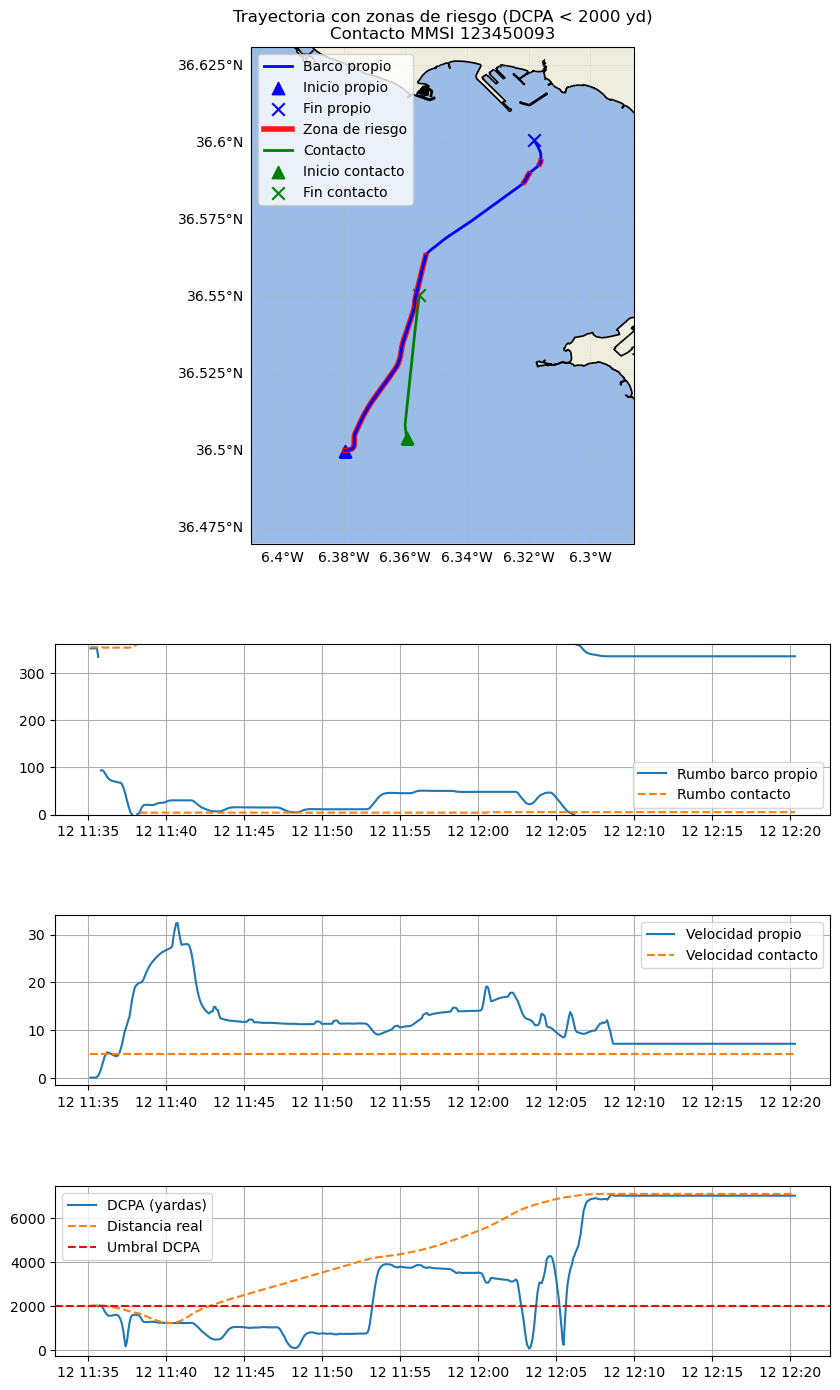

Imagen guardada: figuras/contactos/contacto_123450098.png


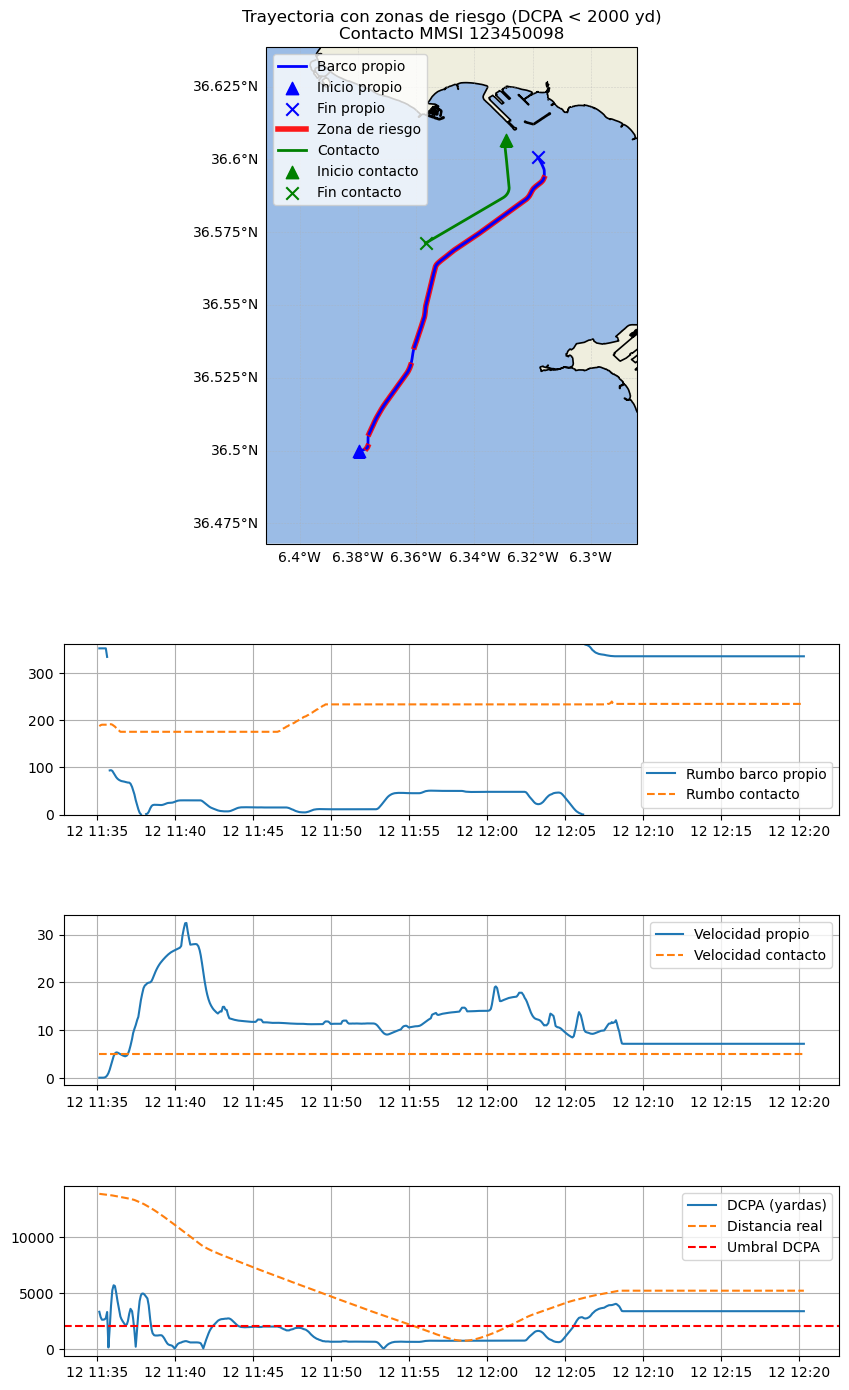

Imagen guardada: figuras/contactos/contacto_123450121.png


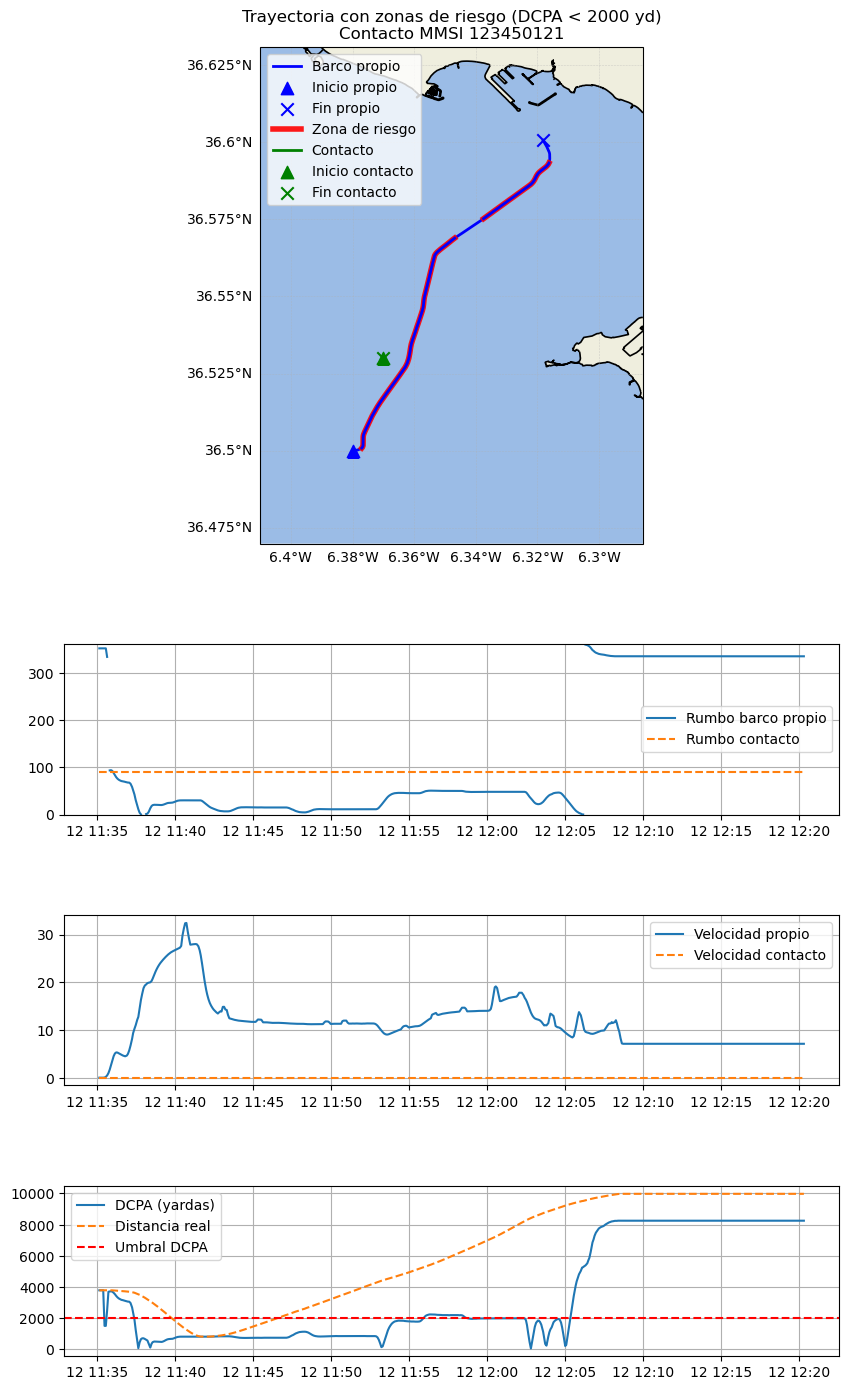

Imagen guardada: figuras/contactos/contacto_123450157.png


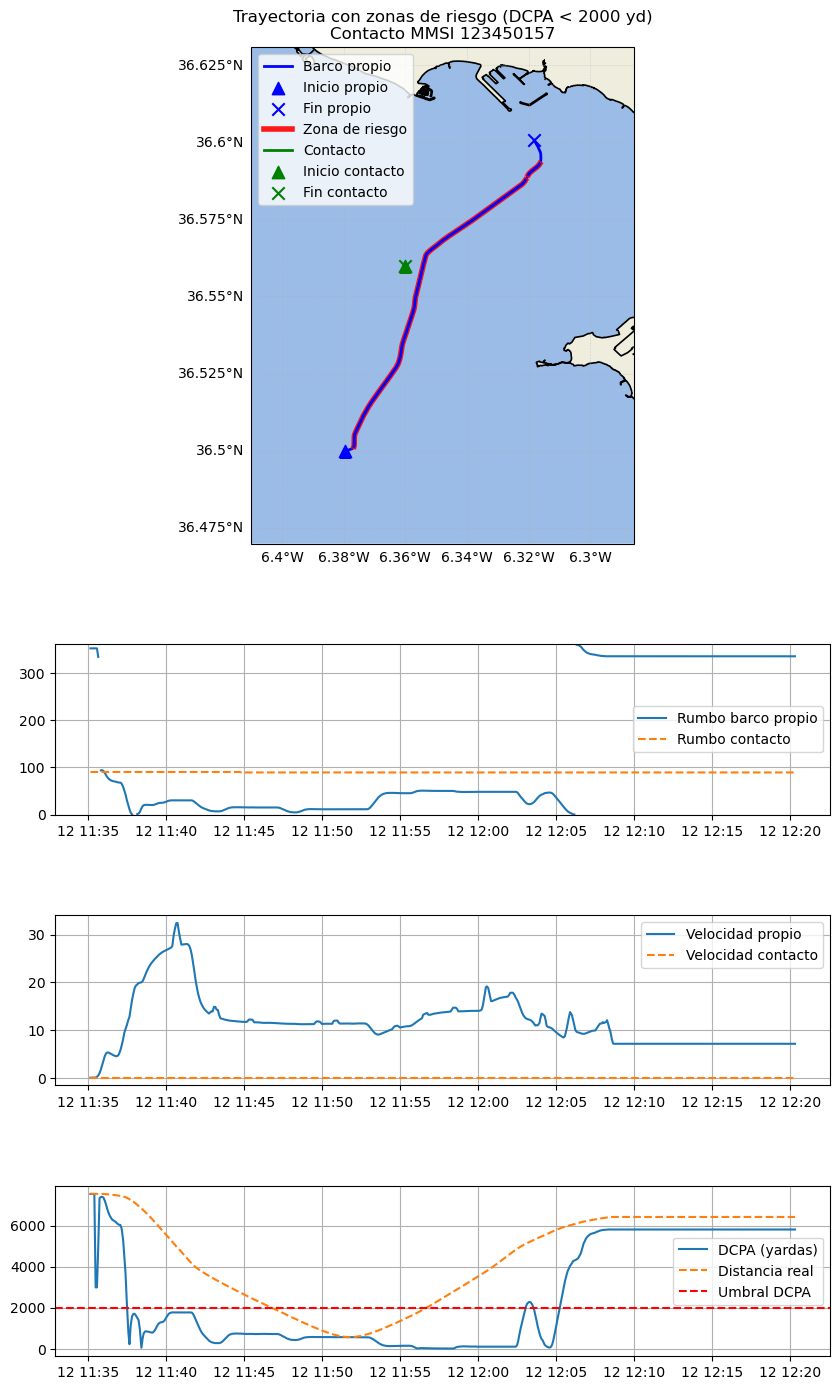

Imagen guardada: figuras/contactos/contacto_123450166.png


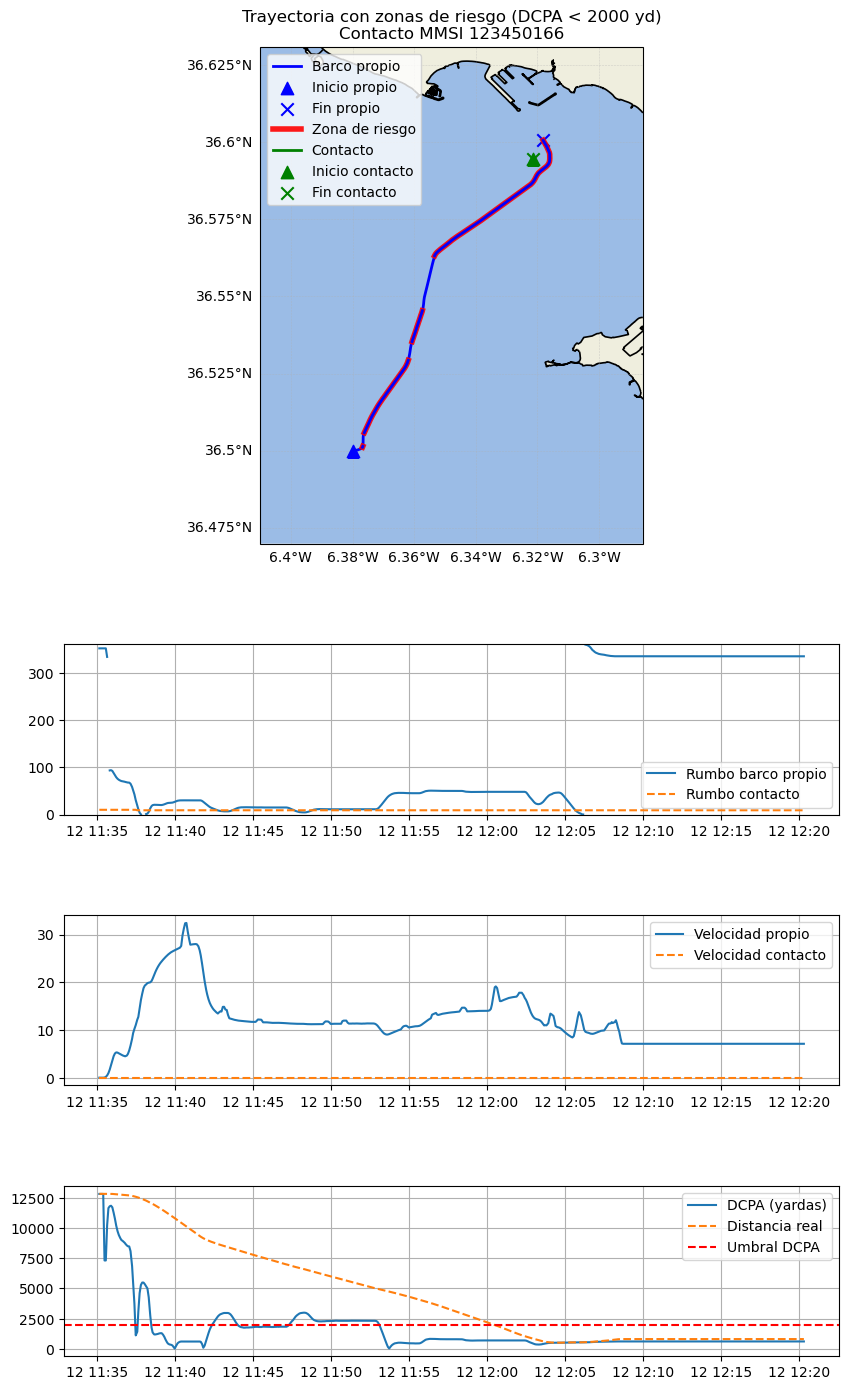


✅ Exportación completada.
Total imágenes generadas: 5


In [195]:
rutas_imagenes_contactos = generar_imagenes_contactos()


In [196]:
# =====================================================
# BLOQUE 29 – DETECCIÓN CRÍTICOS SOLO POR DISTANCIA MÍNIMA
# =====================================================

import os
import glob
import pandas as pd
from datetime import timedelta

# -----------------------------------------------------
# PARÁMETROS
# -----------------------------------------------------
CONTACTS_DIR = "contacts_to_analyse"
OUTPUT_DIR = "critical_sections"

#if OVERWRITE:
    #if OUTPUT_DIR.exists():
        #shutil.rmtree(OUTPUT_DIR)  # elimina carpeta completa
   #OUTPUT_DIR.mkdir()
#else:
    #OUTPUT_DIR.mkdir(exist_ok=True)

WINDOW_BEFORE = timedelta(minutes=5)
WINDOW_AFTER = timedelta(minutes=1)

MIN_EVENT_DURATION = timedelta(minutes=4)

EXTRA_MARGIN_YD = 200  # margen sobre la distancia mínima

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------------------------------
# FUNCIONES AUXILIARES
# -----------------------------------------------------
def extract_window(df, center_time):
    start = center_time - WINDOW_BEFORE
    end = center_time + WINDOW_AFTER
    return df[(df["time"] >= start) & (df["time"] <= end)].copy()


def overlaps(section, existing_sections):
    for sec in existing_sections:
        if not (
            section["time"].max() < sec["time"].min() or
            section["time"].min() > sec["time"].max()
        ):
            return True
    return False


# =====================================================
# PROCESO PRINCIPAL (SOLO DISTANCIA)
# =====================================================

for filepath in glob.glob(os.path.join(CONTACTS_DIR, "*.csv")):

    df = pd.read_csv(filepath)

    required_cols = ["time", "distance"]
    if not all(c in df.columns for c in required_cols):
        continue

    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.dropna(subset=["time", "distance"]).sort_values("time")

    if df.empty:
        continue

    mmsi = df["mmsi"].iloc[0] if "mmsi" in df.columns else "unknown"
    print(f"\n📍 Contacto {mmsi}")

    critical_sections = []
    dist_counter = 0

    # =====================================================
    # DETECCIÓN POR DISTANCIA
    # =====================================================

    global_min_dist = df["distance"].min()
    threshold_dist = global_min_dist + EXTRA_MARGIN_YD

    mask_dist = df["distance"] <= threshold_dist
    block_id_dist = (mask_dist != mask_dist.shift()).cumsum()
    df["block_dist"] = block_id_dist

    for b in df.loc[mask_dist, "block_dist"].unique():

        block_df = df[(df["block_dist"] == b) & mask_dist]
        if block_df.empty:
            continue

        idx_min = block_df["distance"].idxmin()
        t_min = df.loc[idx_min, "time"]

        section = extract_window(df, t_min)

        if not overlaps(section, critical_sections):

            section = section.drop(columns=["block_dist"], errors="ignore")

            critical_sections.append(section)

            dist_counter += 1

            out_name = f"{mmsi}_critical_dist_{dist_counter}.csv"
            section.to_csv(os.path.join(OUTPUT_DIR, out_name), index=False)

            print(f" ➜ DIST {dist_counter}")

print("\n✔ Detección completada.")

# =====================================================
# FILTRO FINAL POR DURACIÓN
# =====================================================

print("\n=== FILTRO FINAL DURACIÓN ≥ 4 MIN ===\n")

removed = 0

for filepath in glob.glob(os.path.join(OUTPUT_DIR, "*.csv")):

    df = pd.read_csv(filepath, parse_dates=["time"])

    if df.empty:
        os.remove(filepath)
        removed += 1
        continue

    duration = df["time"].max() - df["time"].min()

    if duration < MIN_EVENT_DURATION:
        os.remove(filepath)
        removed += 1
        print(f"❌ Eliminado {os.path.basename(filepath)} "
              f"(duración {duration})")

print(f"\nTotal eliminados por duración < 4 min: {removed}")
print("✔ Filtro final aplicado correctamente.")



📍 Contacto 123450093
 ➜ DIST 1

📍 Contacto 123450098
 ➜ DIST 1

📍 Contacto 123450121
 ➜ DIST 1

📍 Contacto 123450157
 ➜ DIST 1

📍 Contacto 123450166
 ➜ DIST 1

✔ Detección completada.

=== FILTRO FINAL DURACIÓN ≥ 4 MIN ===


Total eliminados por duración < 4 min: 0
✔ Filtro final aplicado correctamente.


In [197]:
# =====================================================
# BLOQUE 30 – CLASIFICACIÓN RIPAM EN EVENTOS CRÍTICOS
# (Adaptado a critical_sections DIST + CPA)
# =====================================================

from pathlib import Path
import pandas as pd
import numpy as np
from collections import deque

# -------------------------------------------------
# DIRECTORIOS
# -------------------------------------------------
INPUT_DIR = Path("critical_sections")
OUTPUT_DIR = Path("critical_sections_ripam")
if OVERWRITE:
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)  # elimina carpeta completa
    OUTPUT_DIR.mkdir()
else:
    OUTPUT_DIR.mkdir(exist_ok=True)

# -------------------------------------------------
# PARÁMETROS
# -------------------------------------------------
CONSENSUS_WINDOW = 10  # estabilización ligera

print("=== CLASIFICACIÓN RIPAM EN EVENTOS CRÍTICOS ===\n")

# -------------------------------------------------
# FUNCIONES AUXILIARES
# -------------------------------------------------
def angle_diff(a, b):
    return abs((a - b + 180) % 360 - 180)


def in_sector(angle, start, end):
    if start <= end:
        return start <= angle <= end
    else:
        return angle >= start or angle <= end


def classify_row(r):

    # Verificación básica
    required = ["bearing","bearing_true","cog_deg","cog_deg_ship","sog_kn"]

    if not all(col in r for col in required):
        return "NO_CLASIFICADO"

    # 1️⃣ FONDEADO
    if r["sog_kn"] < 0.5:
        return "FONDEADO"

    # 2️⃣ VUELTA ENCONTRADA
    if (
        (in_sector(r["bearing"], 354, 360) or in_sector(r["bearing"], 0, 6))
        and angle_diff(r["cog_deg"], r["cog_deg_ship"]) > 170
    ):
        return "VUELTA_ENCONTRADA"

    # 3️⃣ ALCANZANDO
    # Bearing relativo desde el contacto hacia own
    bearing_true_from_contact = (r["bearing_true"] + 180) % 360
    bearing_rel_from_contact = (bearing_true_from_contact - r["cog_deg"]) % 360

    if (r["sog_kn_ship"] > r["sog_kn"] and in_sector(bearing_rel_from_contact, 112.5, 247.5)) and  angle_diff(r["cog_deg_ship"], r["cog_deg"]) <= 67.5:
        return "ALCANZANDO"

    # 4️⃣ ALCANZADO
    if (r["sog_kn"] > r["sog_kn_ship"] and in_sector(r["bearing"], 112.5, 247.5)) and angle_diff(r["cog_deg_ship"], r["cog_deg"]) <= 67.5:
        return "ALCANZADO"

    #SITUACIONES DE CRUCE

    # 5️⃣ CRUCE POR ESTRIBOR
    if in_sector(r["bearing"], 0, 112.5):
    
        # ¿Me ve por su estribor?
        contact_sees_me_starboard = in_sector(bearing_rel_from_contact, 0, 112.5)
    
        if contact_sees_me_starboard:
            return "CRUCE_ER_ER"
    
        return "CRUCE_ER"


    # 6️⃣ CRUCE POR BABOR
    if in_sector(r["bearing"], 247.5, 360):

        # ¿Me ve por su babor?
        contact_sees_me_port = in_sector(bearing_rel_from_contact, 247.5, 360)
    
        if contact_sees_me_port:
            return "CRUCE_BR_BR"

        return "CRUCE_BR"


    # 7️⃣ ALEJAMIENTO
    if angle_diff(r["cog_deg"], r["cog_deg_ship"]) > 120:
        return "ALEJAMIENTO"

    return "NO_CLASIFICADO"


# =====================================================
# PROCESO PRINCIPAL
# =====================================================
for csv_file in INPUT_DIR.glob("*.csv"):

    df = pd.read_csv(csv_file, parse_dates=["time"])
    df = df.sort_values("time").reset_index(drop=True)

    if df.empty:
        continue

    required_cols = [
        "bearing",
        "cog_deg",
        "cog_deg_ship",
        "sog_kn",
        "sog_kn_ship",
    ]

    if not all(c in df.columns for c in required_cols):
        print(f"⚠️ {csv_file.name}: faltan columnas necesarias")
        continue

    # -------------------------------------------------
    # CLASIFICACIÓN INSTANTÁNEA
    # -------------------------------------------------
    df["ripam_raw"] = df.apply(classify_row, axis=1)

    # -------------------------------------------------
    # ESTABILIZACIÓN TEMPORAL
    # -------------------------------------------------
    stable_types = []
    buffer = deque(maxlen=CONSENSUS_WINDOW)
    current_type = df["ripam_raw"].iloc[0]

    for rtype in df["ripam_raw"]:
        buffer.append(rtype)

        if len(buffer) == CONSENSUS_WINDOW and all(x == buffer[0] for x in buffer):
            current_type = buffer[0]

        stable_types.append(current_type)

    df["ripam"] = stable_types

    # -------------------------------------------------
    # LIMPIEZA
    # -------------------------------------------------
    df.drop(columns=["ripam_raw"], inplace=True)

    # -------------------------------------------------
    # GUARDADO
    # -------------------------------------------------
    out_file = OUTPUT_DIR / csv_file.name
    df.to_csv(out_file, index=False)

    print(f"{csv_file.name} → Clasificado RIPAM")

print("\n=== FIN CLASIFICACIÓN RIPAM ===")



=== CLASIFICACIÓN RIPAM EN EVENTOS CRÍTICOS ===

123450093_critical_dist_1.csv → Clasificado RIPAM
123450098_critical_dist_1.csv → Clasificado RIPAM
123450121_critical_dist_1.csv → Clasificado RIPAM
123450157_critical_dist_1.csv → Clasificado RIPAM
123450166_critical_dist_1.csv → Clasificado RIPAM

=== FIN CLASIFICACIÓN RIPAM ===


In [198]:
# =====================================================
# BLOQUE 31 – DETECCIÓN DE CORTE DE PROA
# (Adaptado a eventos críticos DIST + CPA)
# =====================================================

from pathlib import Path
import pandas as pd
import numpy as np

# -------------------------------------------------
# DIRECTORIOS
# -------------------------------------------------
INPUT_DIR = Path("critical_sections_ripam")
OUTPUT_DIR = Path("critical_sections_ripam_proa")
if OVERWRITE:
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)  # elimina carpeta completa
    OUTPUT_DIR.mkdir()
else:
    OUTPUT_DIR.mkdir(exist_ok=True)

print("=== DETECCIÓN DE CORTE DE PROA (FONDEADO = NQR) ===\n")

# -------------------------------------------------
# FUNCIÓN – POSICIÓN RELATIVA EN METROS
# -------------------------------------------------
def relative_position_m_from_df(df):
    """
    Calcula vector propio → contacto en metros (Este, Norte)
    """
    lat0 = np.radians(df["lat_ship"])

    df["dx_m"] = (df["lon"] - df["lon_ship"]) * 111320 * np.cos(lat0)
    df["dy_m"] = (df["lat"] - df["lat_ship"]) * 111320

    return df


# -------------------------------------------------
# FUNCIÓN – DETECCIÓN CORTE DE PROA
# -------------------------------------------------
def detect_corto_proa(df):

    # Inicializar columnas
    df["corto_proa_inst"] = False
    df["corto_proa_evento"] = False

    # Si todo el evento es FONDEADO → NQR
    if df["ripam"].eq("FONDEADO").all():
        df["corto_proa_inst"] = "NQR"
        df["corto_proa_evento"] = "NQR"
        return df

    # -------------------------------------------------
    # Eliminar filas sin rumbo válido
    # -------------------------------------------------
    df_valid = df.dropna(subset=["cog_deg", "dx_m", "dy_m"]).copy()

    if df_valid.empty:
        return df

    # -------------------------------------------------
    # Análisis geométrico
    # -------------------------------------------------
    # Vector contacto → propio
    dx = -df_valid["dx_m"]
    dy = -df_valid["dy_m"]

    heading = np.deg2rad(df_valid["cog_deg"])

    # Eje longitudinal (proa contacto)
    x_long = dx * np.sin(heading) + dy * np.cos(heading)

    # Eje transversal (babor-estribor contacto)
    x_trans = dx * np.cos(heading) - dy * np.sin(heading)

    delante = x_long > 0

    corto_inst = np.zeros(len(df_valid), dtype=bool)

    for i in range(1, len(df_valid)):

        # No analizar si esa fila está fondeado
        if df_valid["ripam"].iloc[i] == "FONDEADO":
            continue

        # Solo si propio está delante del contacto en ambas filas
        if delante.iloc[i] and delante.iloc[i-1]:

            # Cambio de banda (babor ↔ estribor)
            if np.sign(x_trans.iloc[i-1]) != np.sign(x_trans.iloc[i]):
                corto_inst[i] = True

    # Reasignar resultados al DF original
    df.loc[df_valid.index, "corto_proa_inst"] = corto_inst

    # Resumen del evento
    df["corto_proa_evento"] = df["corto_proa_inst"].eq(True).any()

    return df


# -------------------------------------------------
# PROCESO PRINCIPAL
# -------------------------------------------------
for csv_file in INPUT_DIR.glob("*.csv"):

    df = pd.read_csv(csv_file, parse_dates=["time"])
    df = df.sort_values("time").reset_index(drop=True)

    if df.empty:
        continue

    required_cols = [
        "lat", "lon",
        "lat_ship", "lon_ship",
        "cog_deg",
        "ripam"
    ]

    if not all(c in df.columns for c in required_cols):
        print(f"⚠️ {csv_file.name}: faltan columnas necesarias")
        continue

    df = relative_position_m_from_df(df)
    df = detect_corto_proa(df)

    # Opcional: eliminar columnas geométricas si no las quieres exportar
    # df = df.drop(columns=["dx_m", "dy_m"], errors="ignore")

    out_file = OUTPUT_DIR / csv_file.name
    df.to_csv(out_file, index=False)

    print(
        f"{csv_file.name} → Corte de proa: "
        f"{df['corto_proa_evento'].iloc[0]}"
    )

print("\n=== FIN DETECCIÓN CORTE DE PROA ===")


=== DETECCIÓN DE CORTE DE PROA (FONDEADO = NQR) ===

123450093_critical_dist_1.csv → Corte de proa: False
123450098_critical_dist_1.csv → Corte de proa: False
123450121_critical_dist_1.csv → Corte de proa: NQR
123450157_critical_dist_1.csv → Corte de proa: NQR
123450166_critical_dist_1.csv → Corte de proa: NQR

=== FIN DETECCIÓN CORTE DE PROA ===


In [199]:
#Bloque 32- Detección de maniobra

from pathlib import Path
import pandas as pd
import numpy as np
import shutil

INPUT_DIR = Path("critical_sections_ripam_proa")
OUTPUT_DIR = Path("critical_sections_ripam_proa_delta")

if OVERWRITE:
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)
    OUTPUT_DIR.mkdir()
else:
    OUTPUT_DIR.mkdir(exist_ok=True)

MIN_TOTAL_CHANGE = 6        # grados
MIN_SPEED_CHANGE = 0.8      # nudos

print("=== DETECCIÓN ACUMULATIVA MANIOBRA (FASE COMPLETA DE ACERCAMIENTO) ===\n")

def unwrap_deg(series):
    return np.rad2deg(np.unwrap(np.deg2rad(series)))

for csv_file in INPUT_DIR.glob("*.csv"):

    df = pd.read_csv(csv_file, parse_dates=["time"])
    df = df.sort_values("time").reset_index(drop=True)

    if df.empty:
        continue

    if not all(c in df.columns for c in ["cog_deg_ship", "sog_kn_ship", "distance"]):
        continue

    # --------------------------------------------------
    # INSTANTE CRÍTICO (CPA)
    # --------------------------------------------------
    idx_min = df["distance"].idxmin()

    # --------------------------------------------------
    # FASE COMPLETA DE ACERCAMIENTO
    # --------------------------------------------------
    df["distance_diff"] = df["distance"].diff()

    start_idx = idx_min

    for i in range(idx_min, 0, -1):
        if df.loc[i, "distance_diff"] < 0:
            start_idx = i
        else:
            break

    df_pre = df.loc[start_idx:idx_min].copy()

    if len(df_pre) < 5:
        continue

    # ==================================================
    # =================== RUMBO ========================
    # ==================================================

    df_pre["cog_unwrapped"] = unwrap_deg(df_pre["cog_deg_ship"])
    df_pre["delta_cog"] = df_pre["cog_unwrapped"].diff()
    df_pre["delta_cog_smooth"] = df_pre["delta_cog"].rolling(3, center=True).mean()

    valid_deltas = df_pre["delta_cog_smooth"].dropna()

    caida_estribor = valid_deltas[valid_deltas > 0].sum()
    caida_babor = -valid_deltas[valid_deltas < 0].sum()

    caida_estribor = round(caida_estribor, 2)
    caida_babor = round(caida_babor, 2)

    # CAMBIO GLOBAL ACUMULADO (como querías)
    cambio_global = round(caida_estribor - caida_babor, 2)

    if (
        abs(cambio_global) >= MIN_TOTAL_CHANGE
        or caida_estribor >= MIN_TOTAL_CHANGE
        or caida_babor >= MIN_TOTAL_CHANGE
    ):

        maniobra_rumbo = True

        delta_cog = cambio_global
        delta_cog_er = caida_estribor
        delta_cog_br = caida_babor

        if caida_estribor > caida_babor:
            sentido = "ESTRIBOR"
        elif caida_babor > caida_estribor:
            sentido = "BABOR"
        else:
            sentido = "COMPENSADO"

    else:
        maniobra_rumbo = False
        delta_cog = 0.0
        delta_cog_er = 0.0
        delta_cog_br = 0.0
        sentido = "NO_RESEÑABLE"

    # ==================================================
    # ================== VELOCIDAD =====================
    # ==================================================

    if "sog_kn_ship" not in df_pre.columns:
        continue

    df_pre["delta_v"] = df_pre["sog_kn_ship"].diff()
    df_pre["delta_v_smooth"] = df_pre["delta_v"].rolling(3, center=True).mean()

    valid_deltas_v = df_pre["delta_v_smooth"].dropna()

    sog_up = valid_deltas_v[valid_deltas_v > 0].sum()
    sog_down = -valid_deltas_v[valid_deltas_v < 0].sum()

    sog_up = round(sog_up, 2)
    sog_down = round(sog_down, 2)

    N = 5
    sog_start = df_pre["sog_kn_ship"].iloc[:N].mean()
    sog_end = df_pre["sog_kn_ship"].iloc[-N:].mean()

    delta_sog = round(sog_end - sog_start, 2)

    if (
        abs(delta_sog) >= MIN_SPEED_CHANGE
        or sog_up >= MIN_SPEED_CHANGE
        or sog_down >= MIN_SPEED_CHANGE
    ):

        maniobra_vel = True

        delta_sog_net = delta_sog
        delta_sog_up = sog_up
        delta_sog_down = sog_down

        if sog_end > sog_start:
            tendencia_vel = "ACELERACION"
        elif sog_start > sog_end:
            tendencia_vel = "REDUCCION"
        else:
            tendencia_vel = "COMPENSADA"

    else:
        maniobra_vel = False
        delta_sog_net = 0.0
        delta_sog_up = 0.0
        delta_sog_down = 0.0
        tendencia_vel = "NO_RESEÑABLE"

    # ==================================================
    # ==================== RESULTADO ===================
    # ==================================================

    maniobra_total = maniobra_rumbo or maniobra_vel

    df["delta_cog_br"] = delta_cog_br
    df["delta_cog_er"] = delta_cog_er
    df["delta_cog_propio_pre_evento"] = delta_cog
    df["sentido_giro_propio_pre_evento"] = sentido

    df["delta_sog_up"] = delta_sog_up
    df["delta_sog_down"] = delta_sog_down
    df["delta_sog_propio_pre_evento"] = delta_sog_net
    df["tendencia_velocidad_pre_evento"] = tendencia_vel

    df["maniobra_propio_pre_evento_rumbo"] = maniobra_rumbo
    df["maniobra_propio_pre_evento_vel"] = maniobra_vel
    df["maniobra_propio_pre_evento_total"] = maniobra_total

    df.to_csv(OUTPUT_DIR / csv_file.name, index=False)

    print(csv_file.name)
    print(f"  Δ rumbo neto acumulado: {delta_cog:.2f}° ({sentido})")
    print(f"  Δ rumbo ER acumulado: {delta_cog_er:.2f}°")
    print(f"  Δ rumbo BR acumulado: {delta_cog_br:.2f}°")
    print(f"  Δ velocidad neta: {delta_sog_net:.2f} kn")
    print(f"  Δ aumento velocidad: {delta_sog_up:.2f} kn")
    print(f"  Δ disminución velocidad: {delta_sog_down:.2f} kn")
    print(f"  Maniobra rumbo: {maniobra_rumbo}")
    print(f"  Maniobra velocidad: {maniobra_vel}")
    print(f"  Maniobra total: {maniobra_total}")
    print("-" * 50)

print("\n=== FIN DETECCIÓN ACUMULATIVA ===")



=== DETECCIÓN ACUMULATIVA MANIOBRA (FASE COMPLETA DE ACERCAMIENTO) ===

123450098_critical_dist_1.csv
  Δ rumbo neto acumulado: 12.30° (ESTRIBOR)
  Δ rumbo ER acumulado: 13.83°
  Δ rumbo BR acumulado: 1.53°
  Δ velocidad neta: 5.09 kn
  Δ aumento velocidad: 5.97 kn
  Δ disminución velocidad: 0.52 kn
  Maniobra rumbo: True
  Maniobra velocidad: True
  Maniobra total: True
--------------------------------------------------
123450121_critical_dist_1.csv
  Δ rumbo neto acumulado: -40.07° (BABOR)
  Δ rumbo ER acumulado: 30.80°
  Δ rumbo BR acumulado: 70.87°
  Δ velocidad neta: 16.75 kn
  Δ aumento velocidad: 26.27 kn
  Δ disminución velocidad: 9.98 kn
  Maniobra rumbo: True
  Maniobra velocidad: True
  Maniobra total: True
--------------------------------------------------
123450157_critical_dist_1.csv
  Δ rumbo neto acumulado: -4.00° (BABOR)
  Δ rumbo ER acumulado: 7.00°
  Δ rumbo BR acumulado: 11.00°
  Δ velocidad neta: -0.08 kn
  Δ aumento velocidad: 1.28 kn
  Δ disminución velocidad: 1.

In [200]:
# =====================================================
# BLOQUE 33 – RESUMEN GLOBAL DE EVENTOS CRÍTICOS
# =====================================================
from pathlib import Path
import pandas as pd

INPUT_DIR = Path("critical_sections_ripam_proa_delta")
SUMMARY_FILE = "resumen_eventos_criticos.csv"

print("=== RESUMEN GLOBAL DE EVENTOS CRÍTICOS ===\n")

summary_rows = []

for csv_file in INPUT_DIR.glob("*.csv"):

    df = pd.read_csv(csv_file, parse_dates=["time"])
    df = df.sort_values("time")

    if df.empty:
        continue

    # -------------------------------------------------
    # IDENTIFICACIÓN
    # -------------------------------------------------
    mmsi = df["mmsi"].iloc[0] if "mmsi" in df.columns else "DESCONOCIDO"
    tipo_evento = "DCPA" if "_dcpa_" in csv_file.name else "DIST"

    # -------------------------------------------------
    # INFORMACIÓN TEMPORAL
    # -------------------------------------------------
    t_inicio = df["time"].iloc[0]
    t_fin = df["time"].iloc[-1]
    duracion = (t_fin - t_inicio).total_seconds()

    # -------------------------------------------------
    # DISTANCIA MÍNIMA
    # -------------------------------------------------
    dist_min = df["distance"].min() if "distance" in df.columns else None

    # -------------------------------------------------
    # DCPA MÍNIMO SOSTENIDO
    # -------------------------------------------------
    if "dcpa" in df.columns and df["dcpa"].notna().any():
        dcpa_values = df["dcpa"].dropna()
        n_vals = min(5, len(dcpa_values))
        dcpa_min = dcpa_values.nsmallest(n_vals).mean()
    else:
        dcpa_min = None

    # -------------------------------------------------
    # RIPAM
    # -------------------------------------------------
    ripam_dom = df["ripam"].mode()[0] if "ripam" in df.columns else None

    # -------------------------------------------------
    # CORTE DE PROA
    # -------------------------------------------------
    corto_proa = (
        df["corto_proa_evento"].iloc[0]
        if "corto_proa_evento" in df.columns
        else None
    )

    # -------------------------------------------------
    # MANIOBRA PROPIA – NUEVO BLOQUE COMPLETO
    # -------------------------------------------------
    delta_cog = df.get("delta_cog_propio_pre_evento", [0])[0]
    delta_cog_br = df.get("delta_cog_br", [0])[0]
    delta_cog_er = df.get("delta_cog_er", [0])[0]

    sentido_giro = df.get("sentido_giro_propio_pre_evento", [None])[0]

    delta_sog = df.get("delta_sog_propio_pre_evento", [0])[0]
    delta_sog_up = df.get("delta_sog_up", [0])[0]
    delta_sog_down = df.get("delta_sog_down", [0])[0]

    tendencia_vel = df.get("tendencia_velocidad_pre_evento", [None])[0]

    maniobra_rumbo = df.get("maniobra_propio_pre_evento_rumbo", [False])[0]
    maniobra_vel = df.get("maniobra_propio_pre_evento_vel", [False])[0]
    maniobra_total = df.get("maniobra_propio_pre_evento_total", [False])[0]

    # -------------------------------------------------
    # GUARDAR FILA RESUMEN
    # -------------------------------------------------
    summary_rows.append({
        "archivo": csv_file.name,
        "tipo_evento": tipo_evento,
        "mmsi": mmsi,
        "inicio": t_inicio,
        "fin": t_fin,
        "duracion_seg": duracion,
        "dist_min_yd": dist_min,
        "dcpa_min_yd_sostenido": dcpa_min,
        "ripam_dominante": ripam_dom,
        "corto_proa": corto_proa,

        # MANIOBRA
        "maniobra_total": maniobra_total,
        "maniobra_rumbo": maniobra_rumbo,
        "maniobra_velocidad": maniobra_vel,

        "delta_cog_propio_deg": delta_cog,
        "delta_cog_er_deg": delta_cog_er,
        "delta_cog_br_deg": delta_cog_br,
        "sentido_giro_propio": sentido_giro,

        "delta_sog_propio_kn": delta_sog,
        "delta_sog_up_kn": delta_sog_up,
        "delta_sog_down_kn": delta_sog_down,
        "tendencia_velocidad": tendencia_vel
    })

    # -------------------------------------------------
    # MOSTRAR EN PANTALLA
    # -------------------------------------------------
    print(f"Evento: {csv_file.name}")
    print(f"  Tipo: {tipo_evento}")
    print(f"  MMSI: {mmsi}")
    print(f"  Duración: {duracion:.0f} s")

    if dist_min is not None:
        print(f"  Dist mínima: {dist_min:.1f} yd")

    if dcpa_min is not None:
        print(f"  DCPA mínimo sostenido: {dcpa_min:.1f} yd")

    print(f"  RIPAM dominante: {ripam_dom}")
    print(f"  Corte de proa: {corto_proa}")

    print(f"  Maniobra total: {maniobra_total}")
    print(f"    - Rumbo: {maniobra_rumbo}")
    print(f"    - Velocidad: {maniobra_vel}")

    print(f"  Δ rumbo neto: {delta_cog:.2f}° ({sentido_giro})")
    print(f"    ER acumulado: {delta_cog_er:.2f}°")
    print(f"    BR acumulado: {delta_cog_br:.2f}°")

    print(f"  Δ velocidad neta: {delta_sog:.2f} kn")
    print(f"    Aumento acumulado: {delta_sog_up:.2f} kn")
    print(f"    Disminución acumulada: {delta_sog_down:.2f} kn")
    print(f"    Tendencia: {tendencia_vel}")

    print("-" * 60)


# -------------------------------------------------
# GUARDAR CSV GLOBAL
# -------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_FILE, index=False)

print("\nResumen global guardado en:", SUMMARY_FILE)
print("\n=== FIN RESUMEN EVENTOS ===")


=== RESUMEN GLOBAL DE EVENTOS CRÍTICOS ===

Evento: 123450098_critical_dist_1.csv
  Tipo: DIST
  MMSI: 123450098
  Duración: 354 s
  Dist mínima: 723.9 yd
  DCPA mínimo sostenido: 381.3 yd
  RIPAM dominante: CRUCE_BR_BR
  Corte de proa: False
  Maniobra total: True
    - Rumbo: True
    - Velocidad: True
  Δ rumbo neto: 12.30° (ESTRIBOR)
    ER acumulado: 13.83°
    BR acumulado: 1.53°
  Δ velocidad neta: 5.09 kn
    Aumento acumulado: 5.97 kn
    Disminución acumulada: 0.52 kn
    Tendencia: ACELERACION
------------------------------------------------------------
Evento: 123450121_critical_dist_1.csv
  Tipo: DIST
  MMSI: 123450121
  Duración: 359 s
  Dist mínima: 779.3 yd
  DCPA mínimo sostenido: 239.2 yd
  RIPAM dominante: FONDEADO
  Corte de proa: NQR
  Maniobra total: True
    - Rumbo: True
    - Velocidad: True
  Δ rumbo neto: -40.07° (BABOR)
    ER acumulado: 30.80°
    BR acumulado: 70.87°
  Δ velocidad neta: 16.75 kn
    Aumento acumulado: 26.27 kn
    Disminución acumulada: 9.

In [201]:
# =====================================================
# VISUALIZACIÓN Y EXPORTACIÓN DE TABLAS
# + GUARDAR TABLAS COMO FIGURAS (PNG)
# + EXPORTAR TODAS LAS TABLAS AUTOMÁTICAMENTE
# =====================================================

import os
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets

CRITICAL_DIR = "critical_sections_ripam_proa_delta"

files = glob.glob(os.path.join(CRITICAL_DIR, "*.csv"))
print(f"{len(files)} eventos críticos detectados")

# =====================================================
# GUARDADO DE TABLAS
# =====================================================
TABLES_DIR = Path("figuras/tablas_eventos")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Si False, no vuelve a guardar si ya existe el PNG
OVERWRITE_TABLES = False

# -----------------------------------------------------
# Helpers de formato / estilo
# -----------------------------------------------------
def _si_no(v):
    """Convierte booleanos (o strings 'true/false') a 'Sí/No'. Lo demás se deja igual."""
    if v is None:
        return "N/A"
    try:
        if pd.isna(v):
            return "N/A"
    except Exception:
        pass

    if isinstance(v, (bool, np.bool_)):
        return "Sí" if bool(v) else "No"

    if isinstance(v, str):
        lv = v.strip().lower()
        if lv == "true":
            return "Sí"
        if lv == "false":
            return "No"

    return v

def _aplicar_estilo_tabla(matplotlib_table, table_data):
    """
    Estiliza:
    - Fila 0 (MMSI) con color distinto
    - Filas 'Δ rumbo neto' y 'Δ velocidad neta' destacadas
    """
    nrows = len(table_data)
    ncols = len(table_data[0]) if nrows > 0 else 0

    # Primera fila (MMSI)
    header_face = "#d9e8ff"
    for c in range(ncols):
        cell = matplotlib_table[(0, c)]
        cell.set_facecolor(header_face)
        cell.set_text_props(weight="bold")

    # Destacar netos
    labels = [r[0] for r in table_data]
    highlight_face = "#fff2cc"
    targets = ["Δ rumbo neto (°)", "Δ velocidad neta (kn)"]

    for t in targets:
        if t in labels:
            r_idx = labels.index(t)
            for c in range(ncols):
                cell = matplotlib_table[(r_idx, c)]
                cell.set_facecolor(highlight_face)
                cell.set_text_props(weight="bold")

def guardar_tabla_png(table_data, out_path: Path):
    """
    Guarda la tabla como figura PNG.
    """
    fig_tab = plt.figure(figsize=(6, 8))
    ax_tab = fig_tab.add_subplot(111)
    ax_tab.axis("off")

    tabla = ax_tab.table(
        cellText=table_data,
        loc="center",
        cellLoc="left"
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(1.2, 1.5)

    _aplicar_estilo_tabla(tabla, table_data)

    fig_tab.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.close(fig_tab)

def construir_table_data(df: pd.DataFrame, filepath: str, mmsi: str):
    """
    Construye los datos de la tabla.
    """
    ripam_dom = df["ripam"].mode()[0] if "ripam" in df.columns and not df["ripam"].dropna().empty else "N/A"
    corto_proa = df["corto_proa_evento"].iloc[0] if "corto_proa_evento" in df.columns else "N/A"

    maniobra_rumbo = df["maniobra_propio_pre_evento_rumbo"].iloc[0] if "maniobra_propio_pre_evento_rumbo" in df.columns else False
    maniobra_vel = df["maniobra_propio_pre_evento_vel"].iloc[0] if "maniobra_propio_pre_evento_vel" in df.columns else False
    maniobra_total = df["maniobra_propio_pre_evento_total"].iloc[0] if "maniobra_propio_pre_evento_total" in df.columns else False

    delta_cog = df["delta_cog_propio_pre_evento"].iloc[0] if "delta_cog_propio_pre_evento" in df.columns else 0
    delta_cog_br = df["delta_cog_br"].iloc[0] if "delta_cog_br" in df.columns else 0
    delta_cog_er = df["delta_cog_er"].iloc[0] if "delta_cog_er" in df.columns else 0
    sentido = df["sentido_giro_propio_pre_evento"].iloc[0] if "sentido_giro_propio_pre_evento" in df.columns else ""

    delta_sog = df["delta_sog_propio_pre_evento"].iloc[0] if "delta_sog_propio_pre_evento" in df.columns else 0
    delta_sog_up = df["delta_sog_up"].iloc[0] if "delta_sog_up" in df.columns else 0
    delta_sog_down = df["delta_sog_down"].iloc[0] if "delta_sog_down" in df.columns else 0
    tendencia_vel = df["tendencia_velocidad_pre_evento"].iloc[0] if "tendencia_velocidad_pre_evento" in df.columns else ""

    dist_min = float(pd.to_numeric(df["distance"], errors="coerce").min()) if "distance" in df.columns else np.nan
    dcpa_min = float(pd.to_numeric(df["dcpa"], errors="coerce").min()) if "dcpa" in df.columns else np.nan

    table_data = [
        ["MMSI", f"{mmsi}"],
        ["RIPAM", str(ripam_dom)],
        ["Dist mín (yd)", f"{dist_min:.1f}" if np.isfinite(dist_min) else "N/A"],
        ["DCPA mín (yd)", f"{dcpa_min:.1f}" if np.isfinite(dcpa_min) else "N/A"],
        ["Corte de proa al contacto", _si_no(corto_proa)],
        ["Maniobra total", _si_no(maniobra_total)],
        ["Maniobra rumbo", _si_no(maniobra_rumbo)],
        ["Maniobra velocidad", _si_no(maniobra_vel)],
        ["Δ rumbo neto (°)", f"{float(delta_cog):.1f} {sentido}".strip()],
        ["Δ rumbo BABOR (°)", f"{float(delta_cog_br):.1f}"],
        ["Δ rumbo ESTRIBOR (°)", f"{float(delta_cog_er):.1f}"],
        ["Δ velocidad neta (kn)", f"{float(delta_sog):.2f}"],
        ["Δ aumento vel (kn)", f"{float(delta_sog_up):.2f}"],
        ["Δ reducción vel (kn)", f"{float(delta_sog_down):.2f}"],
        ["Tendencia velocidad", str(tendencia_vel)]
    ]

    return table_data, ripam_dom

def guardar_tabla_del_evento(df: pd.DataFrame, filepath: str):
    """
    Guarda la tabla PNG asociada al CSV.
    """
    mmsi = df["mmsi"].iloc[0] if "mmsi" in df.columns else "DESCONOCIDO"
    mmsi = str(mmsi)
    table_data, ripam_dom = construir_table_data(df, filepath, mmsi)

    out_name = f"tabla_{Path(filepath).stem}_mmsi_{mmsi}.png".replace(os.sep, "_")
    out_path = TABLES_DIR / out_name

    if OVERWRITE_TABLES or (not out_path.exists()):
        guardar_tabla_png(table_data, out_path)
        print(f"🖼️ Tabla guardada: {out_path}")

    return table_data, ripam_dom, mmsi

def mostrar_tabla_evento(index):
    """
    Muestra solo la tabla del evento seleccionado.
    """
    if len(files) == 0:
        print("No hay eventos críticos.")
        return

    filepath = files[index]
    df = pd.read_csv(filepath)

    if df.empty:
        print("El archivo está vacío.")
        return

    table_data, ripam_dom, mmsi = guardar_tabla_del_evento(df, filepath)

    fig = plt.figure(figsize=(7, 8))
    ax = fig.add_subplot(111)
    ax.axis("off")

    tabla = ax.table(
        cellText=table_data,
        loc="center",
        cellLoc="left"
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(1.2, 1.5)

    _aplicar_estilo_tabla(tabla, table_data)

    ax.set_title(f"EVENTO CRÍTICO – MMSI {mmsi}", fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()

# =====================================================
# EXPORTAR TODAS LAS TABLAS AUTOMÁTICAMENTE
# =====================================================
def exportar_todas_las_tablas():
    if len(files) == 0:
        print("No hay eventos críticos.")
        return

    print("\n📦 Exportando todas las tablas...\n")
    total = 0

    for filepath in files:
        df = pd.read_csv(filepath)

        if "distance" not in df.columns or "dcpa" not in df.columns:
            continue

        mmsi = df["mmsi"].iloc[0] if "mmsi" in df.columns else "DESCONOCIDO"
        mmsi = str(mmsi)
        table_data, _ripam_dom = construir_table_data(df, filepath, mmsi)

        out_name = f"tabla_{Path(filepath).stem}_mmsi_{mmsi}.png".replace(os.sep, "_")
        out_path = TABLES_DIR / out_name

        if OVERWRITE_TABLES or (not out_path.exists()):
            guardar_tabla_png(table_data, out_path)
            total += 1

    print(f"✅ Exportadas {total} tablas en: {TABLES_DIR.resolve()}")

# =====================================================
# INTERACTIVO SOLO PARA TABLAS
# =====================================================
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(files)-1 if len(files) > 0 else 0,
    step=1,
    description="Evento:"
)

widgets.interact(mostrar_tabla_evento, index=slider)

# =====================================================
# GENERAR TODAS AUTOMÁTICAMENTE
# =====================================================
exportar_todas_las_tablas()


4 eventos críticos detectados


interactive(children=(IntSlider(value=0, description='Evento:', max=3), Output(outputs=({'name': 'stdout', 'te…


📦 Exportando todas las tablas...

✅ Exportadas 3 tablas en: C:\Users\rodri\OneDrive\Escritorio\PROGRAMACION\VERSIONES FINALES\RIPAM\RIPAM ROTA\figuras\tablas_eventos



Procesando 123450098_critical_dist_1.csv
Imagen guardada en: figuras/contactos\situacion_123450098_123450098_critical_dist_1.png


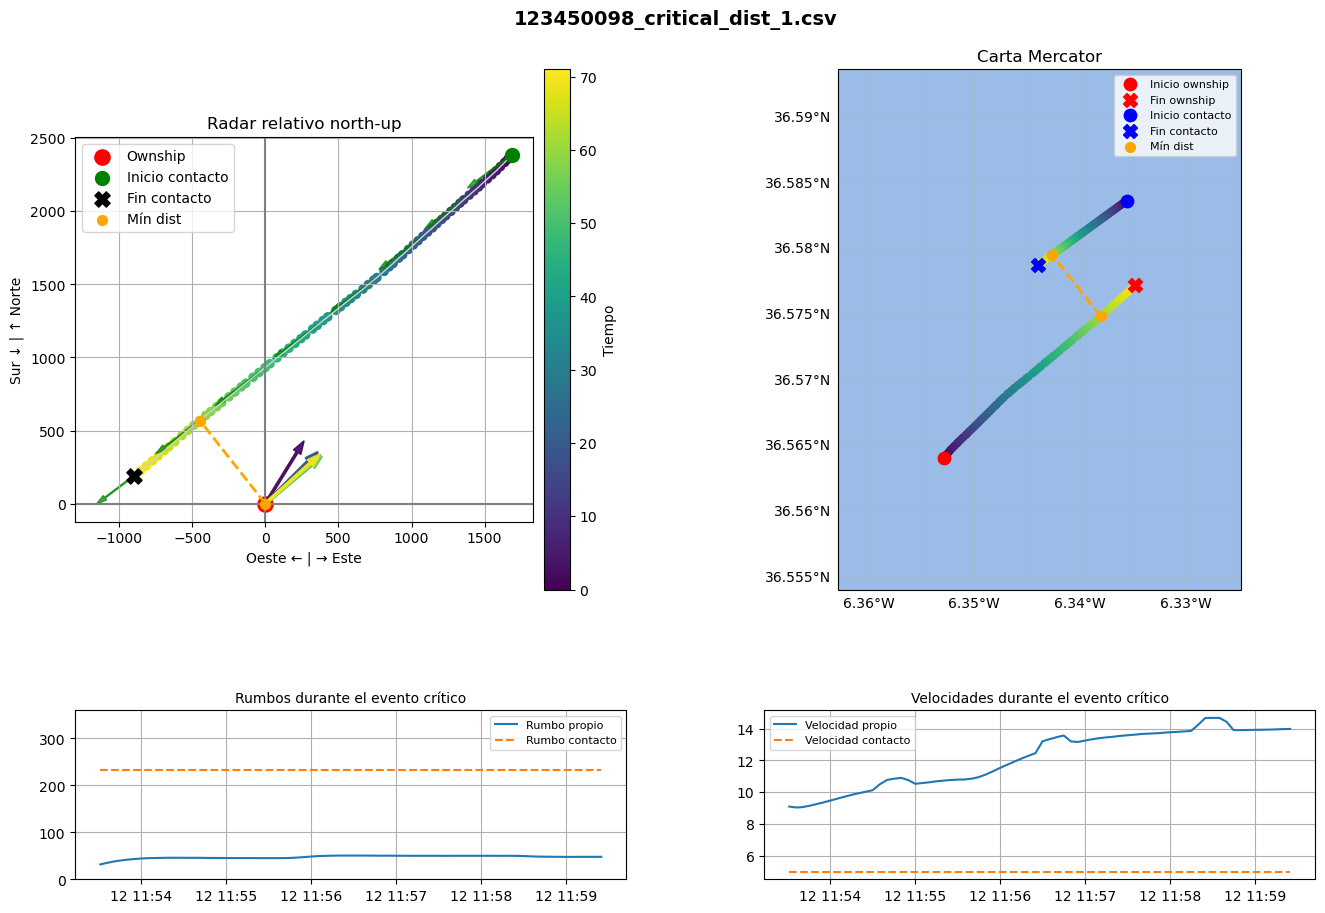


Procesando 123450121_critical_dist_1.csv
Imagen guardada en: figuras/contactos\situacion_123450121_123450121_critical_dist_1.png


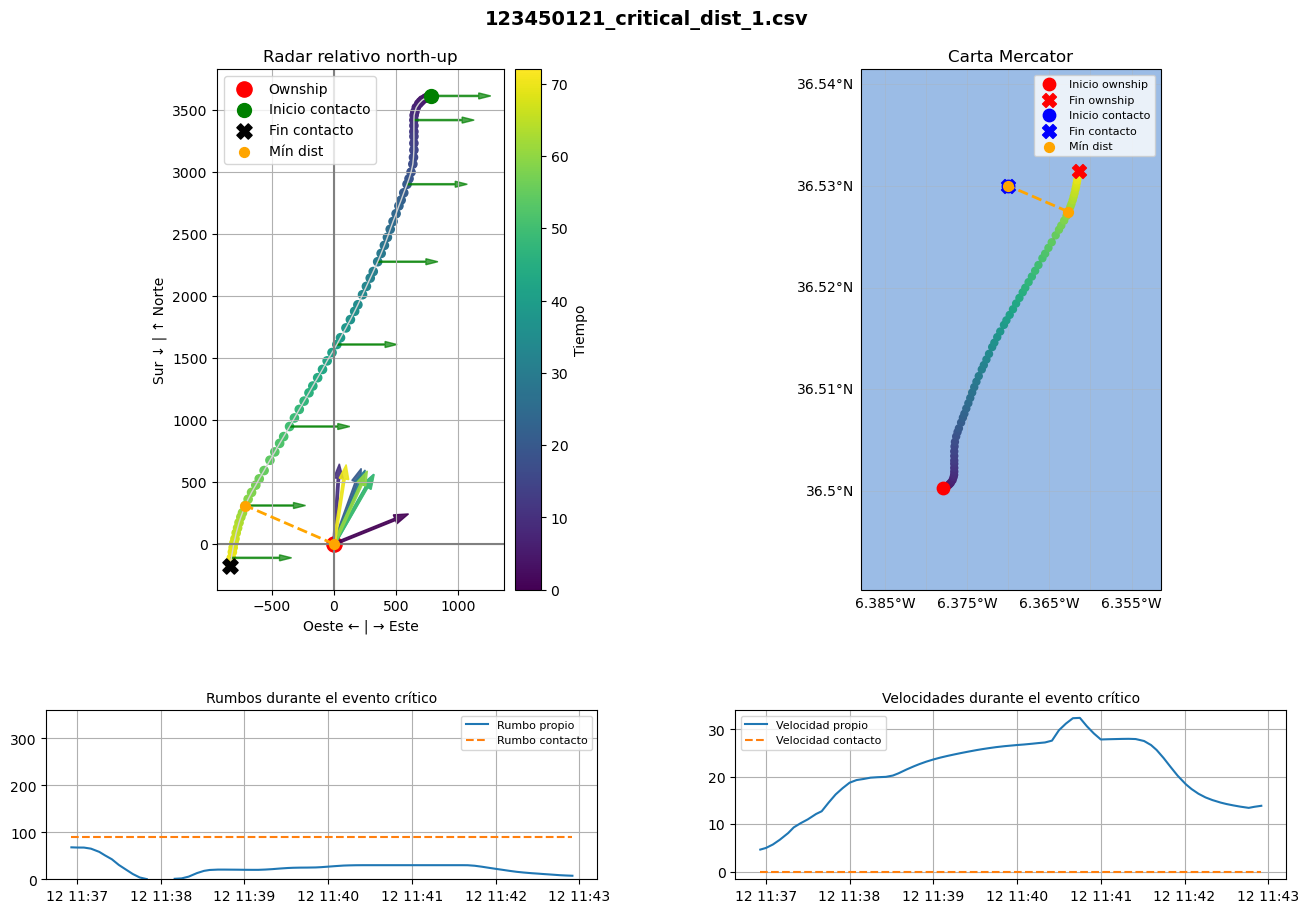


Procesando 123450157_critical_dist_1.csv
Imagen guardada en: figuras/contactos\situacion_123450157_123450157_critical_dist_1.png


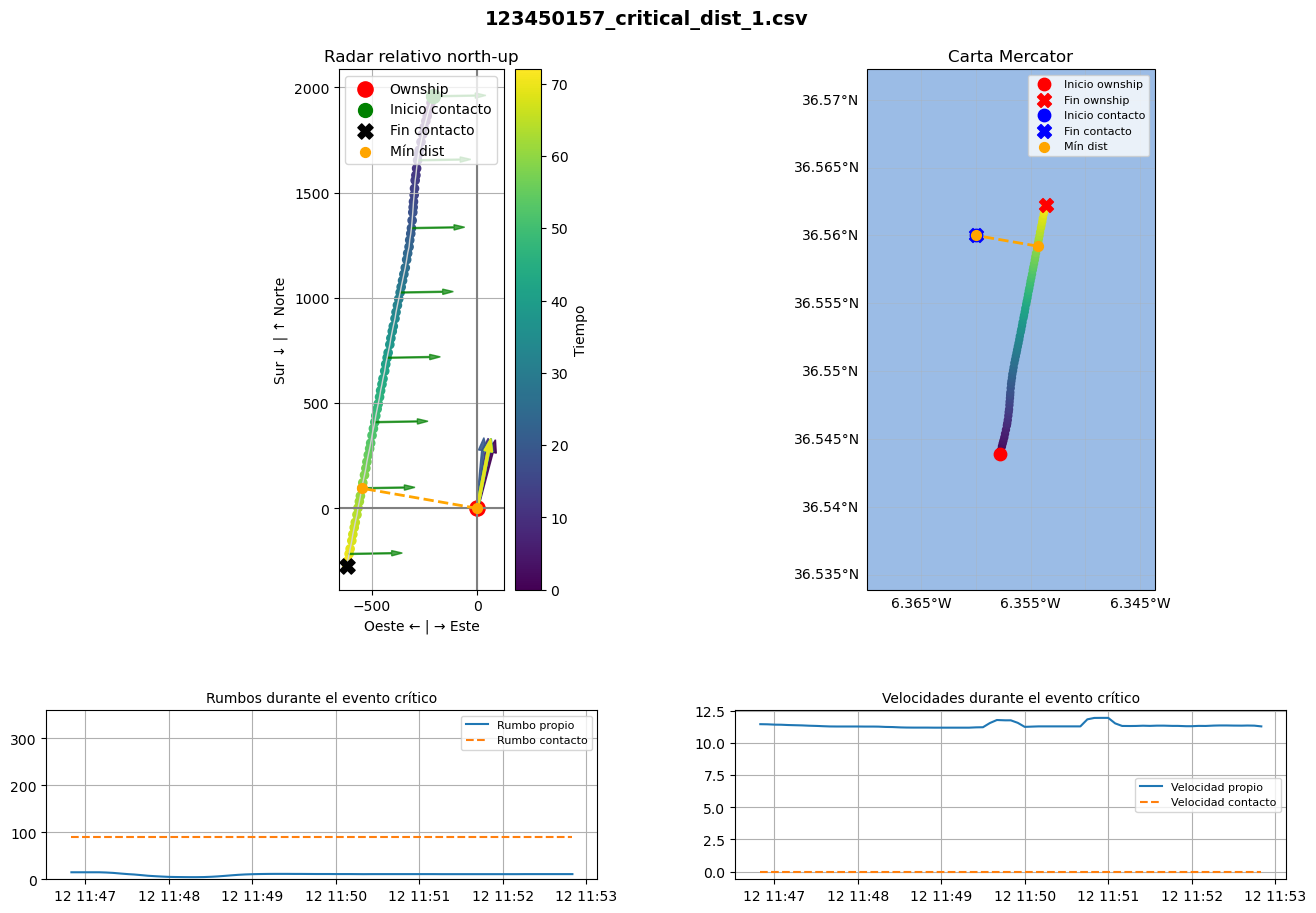


Procesando 123450166_critical_dist_1.csv
Imagen guardada en: figuras/contactos\situacion_123450166_123450166_critical_dist_1.png


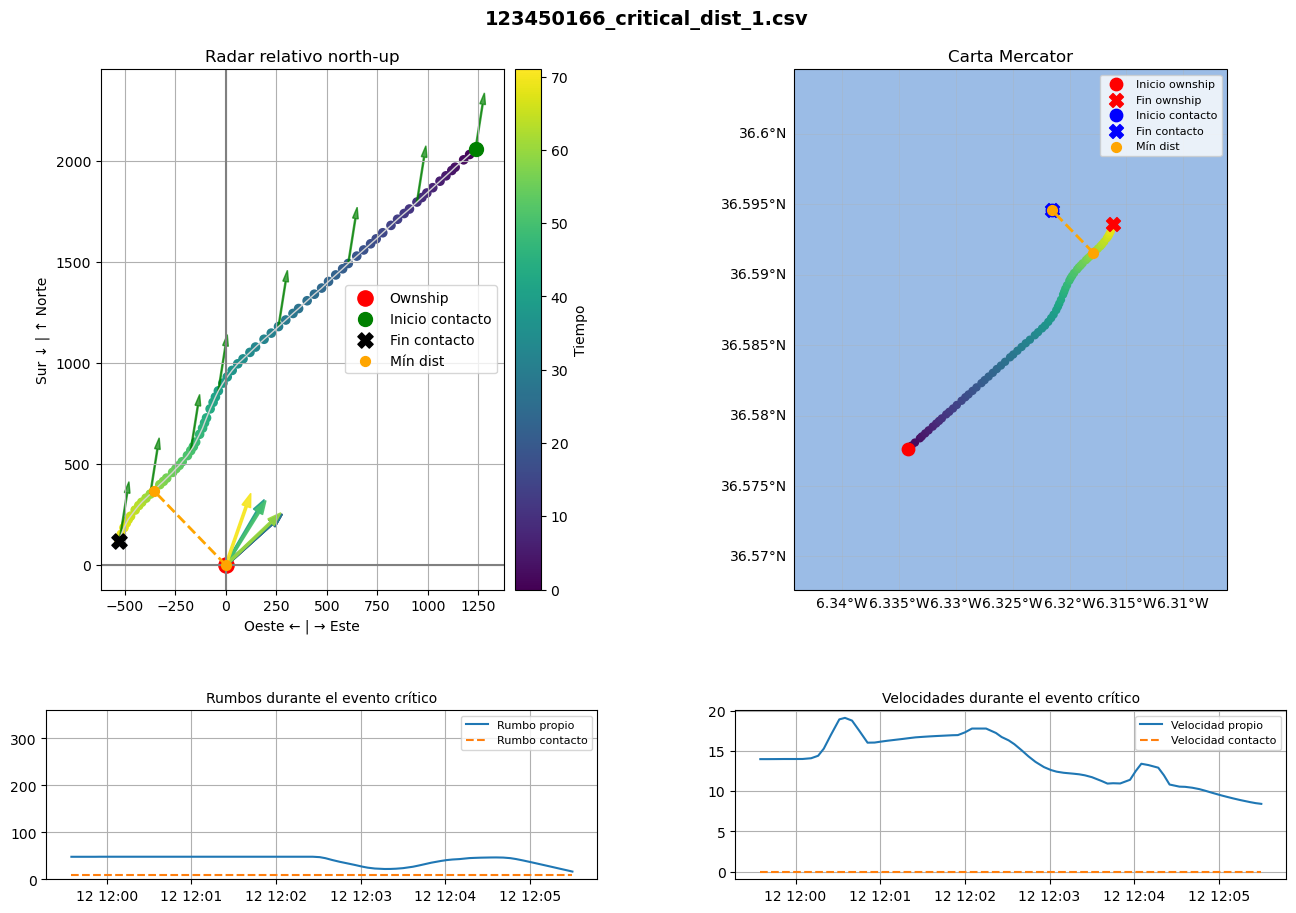

In [202]:
# =====================================================
# EVENTOS CRÍTICOS (RADAR + CARTA MERCATOR + RUMBOS + VELOCIDADES)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob, os
import geopandas as gpd
from shapely.geometry import box, LineString, Point
from shapely.ops import unary_union, polygonize
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# -------------------------
# Config costa
# -------------------------
RUTA_COSTA = r"datos_2/COSTA.shp"
CRS_WGS84 = "EPSG:4326"

# Caché
_COSTA_CACHE = {}

def _densify_line(line, step_deg: float):
    """Añade vértices cada step_deg (grados) a una LineString."""
    if line is None or line.is_empty or line.length == 0:
        return line
    distances = np.arange(0, line.length, step_deg)
    pts = [line.interpolate(d) for d in distances]
    pts.append(line.interpolate(line.length))
    return LineString(pts)

def _prepare_costa(extent, step_deg=0.00005, filtrar_features=True):
    """
    Carga COSTA.shp, recorta al extent (min_lon,max_lon,min_lat,max_lat),
    filtra y devuelve una geometría (LineString/MultiLineString) densificada.
    """
    min_lon, max_lon, min_lat, max_lat = extent
    key = (min_lon, max_lon, min_lat, max_lat, step_deg, filtrar_features)

    if key in _COSTA_CACHE:
        return _COSTA_CACHE[key]

    gdf = gpd.read_file(RUTA_COSTA)

    # CRS -> WGS84
    if gdf.crs is not None and str(gdf.crs) != CRS_WGS84:
        gdf = gdf.to_crs(CRS_WGS84)
    elif gdf.crs is None:
        # Si tu shapefile está en lon/lat pero sin CRS, descomenta:
        # gdf = gdf.set_crs(CRS_WGS84)
        pass

    # Recorte bbox
    bbox_geom = box(min_lon, min_lat, max_lon, max_lat)
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_geom], crs=CRS_WGS84)
    gdf = gpd.clip(gdf, bbox_gdf)

    # Filtros
    if filtrar_features and "FEATURE" in gdf.columns:
        gdf = gdf[~gdf["FEATURE"].isin(["DEPCNT", "RIVERS"])].copy()

    geom = unary_union(gdf.geometry)

    # Densificar
    if step_deg and step_deg > 0 and (geom is not None) and (not geom.is_empty):
        if geom.geom_type == "MultiLineString":
            geom = unary_union([_densify_line(l, step_deg) for l in geom.geoms])
        elif geom.geom_type == "LineString":
            geom = _densify_line(geom, step_deg)

    _COSTA_CACHE[key] = geom
    return geom

def add_land_sea_from_costa(
    ax,
    extent,
    own_track=None,
    coast_step_deg=0.00005,
    land_fc="#efeede",
    sea_fc="#9bbce6",
    coast_ec="black",
    coast_lw=1.2,
    zorder_fill=0,
    zorder_coast=2
):
    """
    1) Polygonize(costa + bbox)
    2) Clasifica como MAR el polígono que contiene la derrota del barco propio
    3) El resto se pinta como TIERRA
    4) Fallback si falla la semilla
    """
    min_lon, max_lon, min_lat, max_lat = extent

    costa_geom = _prepare_costa(extent, step_deg=coast_step_deg, filtrar_features=True)

    # Fondo por defecto
    ax.set_facecolor(sea_fc)

    if costa_geom is None or costa_geom.is_empty:
        ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=zorder_fill + 1)
        return

    bbox_poly = box(min_lon, min_lat, max_lon, max_lat)
    merged_lines = unary_union([costa_geom, bbox_poly.exterior])
    polys = list(polygonize(merged_lines))

    if len(polys) == 0:
        ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=zorder_fill + 1)
        ax.add_geometries([costa_geom], crs=ccrs.PlateCarree(),
                          facecolor="none", edgecolor=coast_ec,
                          linewidth=coast_lw, zorder=zorder_coast)
        return

    # -------------------------------------------------
    # Buscar semillas de mar en la derrota del propio
    # -------------------------------------------------
    sea_poly_scores = [0] * len(polys)

    if own_track is not None and len(own_track) > 0:
        for lon, lat in own_track:
            if pd.isna(lon) or pd.isna(lat):
                continue

            p = Point(lon, lat)

            for i, poly in enumerate(polys):
                if poly.buffer(1e-10).contains(p) or poly.buffer(1e-10).touches(p):
                    sea_poly_scores[i] += 1
                    break

    sea_polys = []
    land_polys = []

    # -------------------------------------------------
    # Clasificación principal: el polígono con más puntos
    # de la derrota del propio es el MAR
    # -------------------------------------------------
    if max(sea_poly_scores) > 0:
        sea_idx = int(np.argmax(sea_poly_scores))

        for i, poly in enumerate(polys):
            if i == sea_idx:
                sea_polys.append(poly)
            else:
                land_polys.append(poly)

    else:
        # -------------------------------------------------
        # Fallback: usar esquina SW como mar
        # -------------------------------------------------
        eps = 1e-6
        p_sea = Point(min_lon + eps, min_lat + eps)

        for poly in polys:
            if poly.buffer(1e-10).contains(p_sea) or poly.buffer(1e-10).touches(p_sea):
                sea_polys.append(poly)
            else:
                land_polys.append(poly)

    # Mar
    if sea_polys:
        ax.add_geometries(sea_polys, crs=ccrs.PlateCarree(),
                          facecolor=sea_fc, edgecolor="none",
                          zorder=zorder_fill)

    # Tierra
    if land_polys:
        ax.add_geometries(land_polys, crs=ccrs.PlateCarree(),
                          facecolor=land_fc, edgecolor="none",
                          zorder=zorder_fill + 1)

    # Costa encima
    ax.add_geometries([costa_geom], crs=ccrs.PlateCarree(),
                      facecolor="none", edgecolor=coast_ec,
                      linewidth=coast_lw, zorder=zorder_coast)

# =====================================================
# CONFIG
# =====================================================
CONTACTS_DIR = "critical_sections_ripam_proa_delta"
OUTPUT_DIR = "figuras/contactos"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================================================
# FUNCIÓN rumbos sin salto 360->0
# =====================================================
def break_angle_jumps(series, threshold=180):
    s = series.copy().astype(float)
    diff = np.abs(np.diff(s))
    jump_idx = np.where(diff > threshold)[0]
    for idx in jump_idx:
        s.iloc[idx + 1] = np.nan
    return s

# =====================================================
# BUCLE PRINCIPAL
# =====================================================
for filepath in sorted(glob.glob(f"{CONTACTS_DIR}/*.csv")):

    df = pd.read_csv(filepath, parse_dates=["time"])
    df = df.sort_values("time").reset_index(drop=True)

    if df.empty:
        continue

    print(f"\nProcesando {os.path.basename(filepath)}")

    # =====================================================
    # RECONSTRUCCIÓN RADAR DESDE BEARING RELATIVO
    # =====================================================
    bearing_rel = df["bearing"].astype(float)
    r = df["distance"].astype(float)
    heading_own = df["cog_deg_ship"].astype(float)

    bearing_abs = (heading_own + bearing_rel) % 360
    theta = np.deg2rad(bearing_abs)

    x = r * np.sin(theta)
    y = r * np.cos(theta)

    cog_contact = df["cog_deg"].astype(float)
    cog_own = df["cog_deg_ship"].astype(float)

    lat_own = df["lat_ship"].astype(float)
    lon_own = df["lon_ship"].astype(float)
    lat_c = df["lat"].astype(float)
    lon_c = df["lon"].astype(float)

    # =====================================================
    # FIGURA
    # =====================================================
    fig = plt.figure(figsize=(16, 10))

    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[4, 1.3],
        hspace=0.35,
        wspace=0.25
    )

    ax1 = fig.add_subplot(gs[0, 0])                             # radar
    ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.Mercator()) # carta
    ax3 = fig.add_subplot(gs[1, 0])                             # rumbos
    ax4 = fig.add_subplot(gs[1, 1])                             # velocidades

    # =====================================================
    # RADAR NORTH-UP
    # =====================================================
    idx = np.arange(len(df))
    norm = plt.Normalize(idx.min(), idx.max())
    cmap = plt.cm.viridis

    ax1.plot(x, y, color="lightgray", linewidth=1)
    ax1.scatter(x, y, c=idx, cmap="viridis", s=35)

    ax1.scatter(0, 0, c="red", s=120, label="Ownship")

    ax1.scatter(x.iloc[0], y.iloc[0],
                color="green", marker="o", s=100,
                label="Inicio contacto", zorder=5)

    ax1.scatter(x.iloc[-1], y.iloc[-1],
                color="black", marker="X", s=120,
                label="Fin contacto", zorder=6)

    L_base = r.mean() * 0.08

    N_OWN = 10
    for i, heading in enumerate(cog_own):
        if i % N_OWN != 0:
            continue
        L = L_base * 4
        dx_arrow = L * np.sin(np.deg2rad(heading))
        dy_arrow = L * np.cos(np.deg2rad(heading))
        ax1.arrow(
            0, 0, dx_arrow, dy_arrow,
            width=L * 0.03,
            head_width=L * 0.12,
            head_length=L * 0.18,
            fc=cmap(norm(i)),
            ec=cmap(norm(i)),
            alpha=0.9,
            length_includes_head=True
        )

    N_C = 10
    for i, (xi, yi, cog) in enumerate(zip(x, y, cog_contact)):
        if i % N_C != 0:
            continue
        L = L_base * 3
        dx_arrow = L * np.sin(np.deg2rad(cog))
        dy_arrow = L * np.cos(np.deg2rad(cog))
        ax1.arrow(
            xi, yi, dx_arrow, dy_arrow,
            width=L * 0.02,
            head_width=L * 0.10,
            head_length=L * 0.20,
            fc="green",
            ec="green",
            alpha=0.7,
            length_includes_head=True
        )

    ax1.axhline(0, color="gray")
    ax1.axvline(0, color="gray")
    ax1.set_aspect("equal")
    ax1.grid(True)
    ax1.set_title("Radar relativo north-up")
    ax1.set_xlabel("Oeste ← | → Este")
    ax1.set_ylabel("Sur ↓ | ↑ Norte")

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax1,
        pad=0.02,
        label="Tiempo"
    )

    # =====================================================
    # MOMENTO DE MENOR DISTANCIA (RADAR)
    # =====================================================
    idx_min = df["distance"].idxmin()
    x_min = x.iloc[idx_min]
    y_min = y.iloc[idx_min]

    ax1.plot([0, x_min], [0, y_min],
             linestyle="--", color="orange", linewidth=2, zorder=6)

    ax1.scatter(x_min, y_min,
                color="orange", s=50, zorder=7, label="Mín dist")
    ax1.scatter(0, 0,
                color="orange", s=50, zorder=7)

    ax1.legend()

    # =====================================================
    # CARTA MERCATOR (DERECHA) — FONDO ROBUSTO
    # =====================================================
    margin = 0.01
    min_lon = min(lon_own.min(), lon_c.min()) - margin
    max_lon = max(lon_own.max(), lon_c.max()) + margin
    min_lat = min(lat_own.min(), lat_c.min()) - margin
    max_lat = max(lat_own.max(), lat_c.max()) + margin
    extent = (min_lon, max_lon, min_lat, max_lat)

    ax2.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    own_track = list(zip(lon_own, lat_own))

    add_land_sea_from_costa(
        ax2,
        extent=extent,
        own_track=own_track,
        coast_step_deg=0.00005,
        land_fc="#efeede",
        sea_fc="#9bbce6",
        coast_ec="black",
        coast_lw=1.2,
        zorder_fill=0,
        zorder_coast=1
    )

    gl = ax2.gridlines(draw_labels=True, linewidth=0.4, alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False

    ax2.plot(lon_own, lat_own, transform=ccrs.PlateCarree(), color="red", zorder=5)
    ax2.scatter(lon_own, lat_own, c=idx, cmap="viridis",
                s=25, transform=ccrs.PlateCarree(), zorder=6)

    ax2.plot(lon_c, lat_c, transform=ccrs.PlateCarree(), color="blue", zorder=5)
    ax2.scatter(lon_c, lat_c, c=idx, cmap="viridis",
                s=25, transform=ccrs.PlateCarree(), zorder=6)

    ax2.scatter(lon_own.iloc[0], lat_own.iloc[0],
                transform=ccrs.PlateCarree(),
                color="red", marker="o", s=80,
                label="Inicio ownship", zorder=7)

    ax2.scatter(lon_own.iloc[-1], lat_own.iloc[-1],
                transform=ccrs.PlateCarree(),
                color="red", marker="X", s=100,
                label="Fin ownship", zorder=7)

    ax2.scatter(lon_c.iloc[0], lat_c.iloc[0],
                transform=ccrs.PlateCarree(),
                color="blue", marker="o", s=80,
                label="Inicio contacto", zorder=7)

    ax2.scatter(lon_c.iloc[-1], lat_c.iloc[-1],
                transform=ccrs.PlateCarree(),
                color="blue", marker="X", s=100,
                label="Fin contacto", zorder=7)

    ax2.set_title("Carta Mercator")

    # =====================================================
    # MOMENTO DE MENOR DISTANCIA (CARTA)
    # =====================================================
    lon_own_min = lon_own.iloc[idx_min]
    lat_own_min = lat_own.iloc[idx_min]
    lon_c_min = lon_c.iloc[idx_min]
    lat_c_min = lat_c.iloc[idx_min]

    ax2.plot([lon_own_min, lon_c_min],
             [lat_own_min, lat_c_min],
             linestyle="--", color="orange", linewidth=2,
             transform=ccrs.PlateCarree(), zorder=8)

    ax2.scatter(lon_own_min, lat_own_min,
                transform=ccrs.PlateCarree(),
                color="orange", s=50, zorder=9)

    ax2.scatter(lon_c_min, lat_c_min,
                transform=ccrs.PlateCarree(),
                color="orange", s=50, zorder=9, label="Mín dist")

    ax2.legend(fontsize=8)

    # =====================================================
    # RUMBOS
    # =====================================================
    cog_ship_plot = break_angle_jumps(df["cog_deg_ship"])
    cog_contact_plot = break_angle_jumps(df["cog_deg"])

    ax3.plot(df["time"], cog_ship_plot, label="Rumbo propio")
    ax3.plot(df["time"], cog_contact_plot, linestyle="--", label="Rumbo contacto")
    ax3.set_ylim(0, 360)
    ax3.grid(True)
    ax3.legend(fontsize=8)
    ax3.set_title("Rumbos durante el evento crítico", fontsize=10)

    # =====================================================
    # VELOCIDADES
    # =====================================================
    ax4.plot(df["time"], df["sog_kn_ship"], label="Velocidad propio")
    ax4.plot(df["time"], df["sog_kn"], linestyle="--", label="Velocidad contacto")
    ax4.grid(True)
    ax4.legend(fontsize=8)
    ax4.set_title("Velocidades durante el evento crítico", fontsize=10)

    # =====================================================
    # GUARDAR
    # =====================================================
    mmsi = df["mmsi"].iloc[0] if "mmsi" in df.columns else "DESCONOCIDO"
    nombre_evento = Path(filepath).stem

    fig.suptitle(os.path.basename(filepath), fontsize=14, fontweight="bold")
    fig.subplots_adjust(top=0.92)

    output_path = os.path.join(OUTPUT_DIR, f"situacion_{mmsi}_{nombre_evento}.png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Imagen guardada en: {output_path}")

    plt.show()
    plt.close(fig)

In [203]:
#Creación de histogromas de evaluación
import numpy as np

def generar_circulos_desde_centro(
    DCPA_THRESHOLD_YD,
    incremento_pct=0.10,
    extension_factor=1.5,
    densidad_puntos_por_yarda=0.02
):
    """
    Genera círculos concéntricos desde el centro (0,0)
    hasta extension_factor * DCPA_THRESHOLD_YD.

    - Paso radial proporcional
    - Número de clusters constante
    - Densidad uniforme sobre la circunferencia
    """

    lista_circulos = []
    radios = []

    radio_max = DCPA_THRESHOLD_YD * extension_factor
    paso = DCPA_THRESHOLD_YD * incremento_pct

    radio = paso
    while radio <= radio_max:

        radios.append(radio)

        # Número de puntos proporcional a la circunferencia
        n_puntos = int(densidad_puntos_por_yarda * 2 * np.pi * radio)
        n_puntos = max(n_puntos, 12)

        theta = np.linspace(0, 2*np.pi, n_puntos, endpoint=False)

        x = radio * np.cos(theta)
        y = radio * np.sin(theta)

        puntos = np.column_stack((x, y))

        lista_circulos.append(puntos)

        radio += paso

    return lista_circulos, radios





In [204]:
# =====================================================
# GENERACIÓN DE CÍRCULOS CONCÉNTRICOS DESDE EL CENTRO
# =====================================================

circulos, radios = generar_circulos_desde_centro(
    DCPA_THRESHOLD_YD=2000,
    incremento_pct=0.10,
    extension_factor=1.5,
    densidad_puntos_por_yarda=0.02
)

print(radios)



[200.0, 400.0, 600.0, 800.0, 1000.0, 1200.0, 1400.0, 1600.0, 1800.0, 2000.0, 2200.0, 2400.0, 2600.0, 2800.0, 3000.0]


In [205]:
paso = DCPA_THRESHOLD_YD * 0.10
radio_max = DCPA_THRESHOLD_YD * 1.5

radio_real = np.sqrt(x**2 + y**2)
bins = np.arange(paso, radio_max + paso, paso)

cluster_real = np.digitize(radio_real, bins)

n_clusters = len(bins)





Procesando 123450098_critical_dist_1.csv
  Situación RIPAM: CRUCE_BR
  Eslora representativa: 88.0 m
  Categoría tamaño: GRANDE
  Umbral referencia: 0.250 MN = 506.3 yd
  ✔ CSV hist + imágenes generadas
  % fuera de rango (>150%): 87.5%
🖼️ Guardado combinado: figuras\histogramas_radiales\123450098_critical_dist_1_radar_hist.png


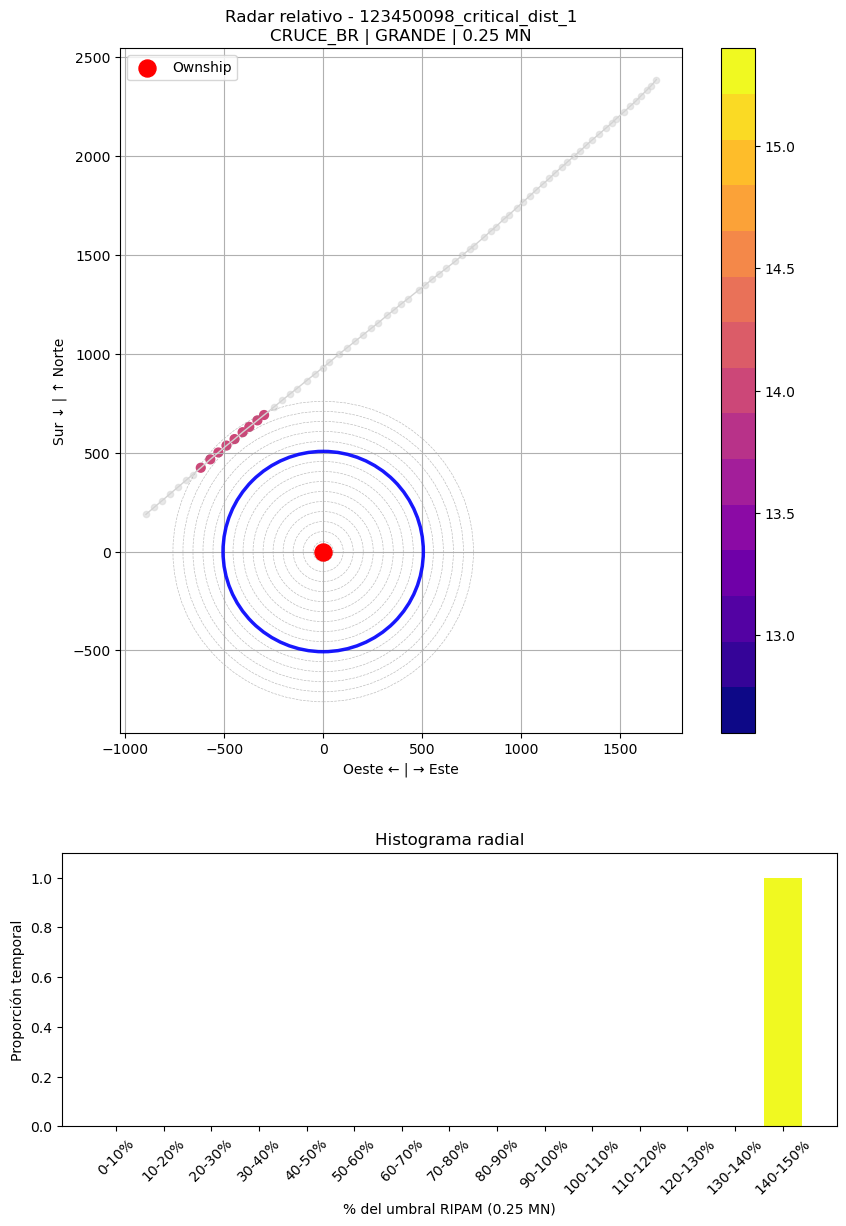


Procesando 123450121_critical_dist_1.csv
  Situación RIPAM: OTRO
  Eslora representativa: 68.0 m
  Categoría tamaño: GRANDE
  Umbral referencia: 0.250 MN = 506.3 yd
  ✔ CSV hist + imágenes generadas
  % fuera de rango (>150%): 100.0%
🖼️ Guardado combinado: figuras\histogramas_radiales\123450121_critical_dist_1_radar_hist.png


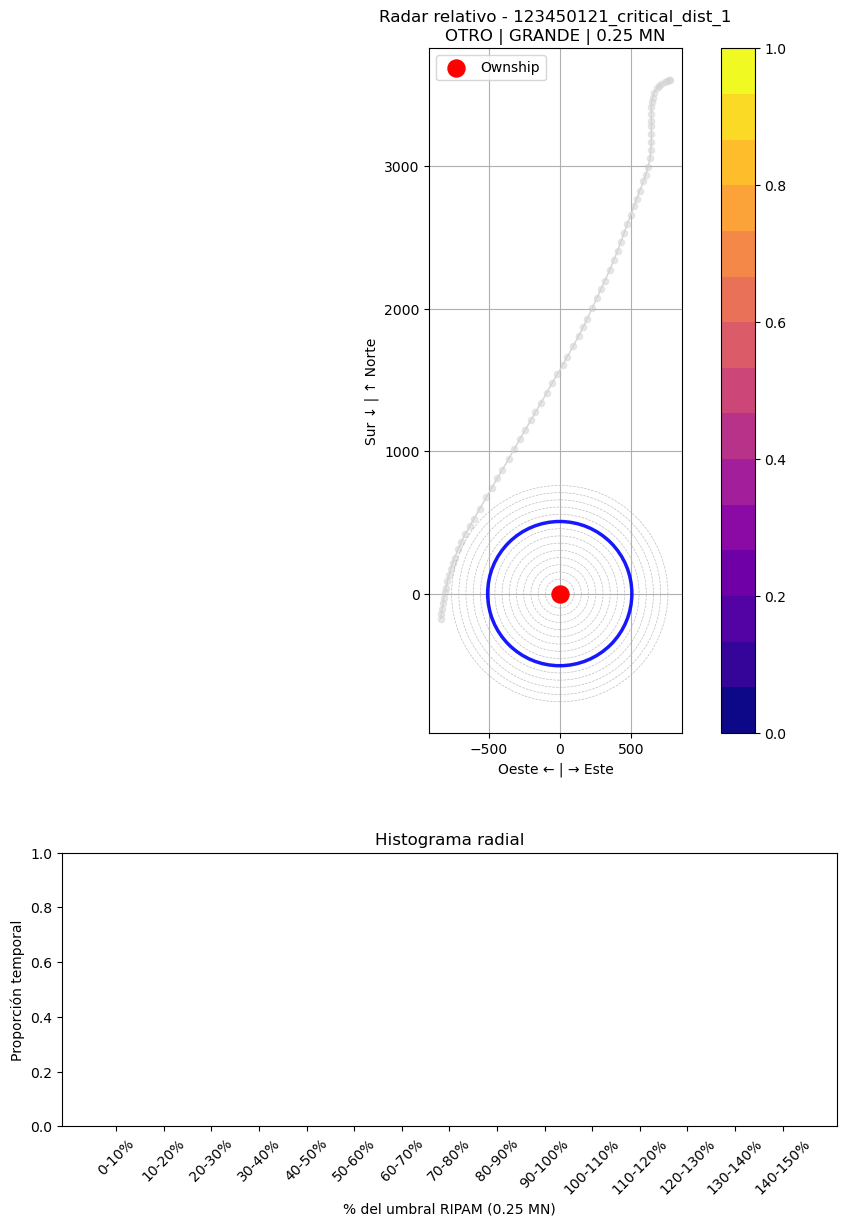


Procesando 123450157_critical_dist_1.csv
  Situación RIPAM: OTRO
  Eslora representativa: 136.0 m
  Categoría tamaño: GRANDE
  Umbral referencia: 0.250 MN = 506.3 yd
  ✔ CSV hist + imágenes generadas
  % fuera de rango (>150%): 60.3%
🖼️ Guardado combinado: figuras\histogramas_radiales\123450157_critical_dist_1_radar_hist.png


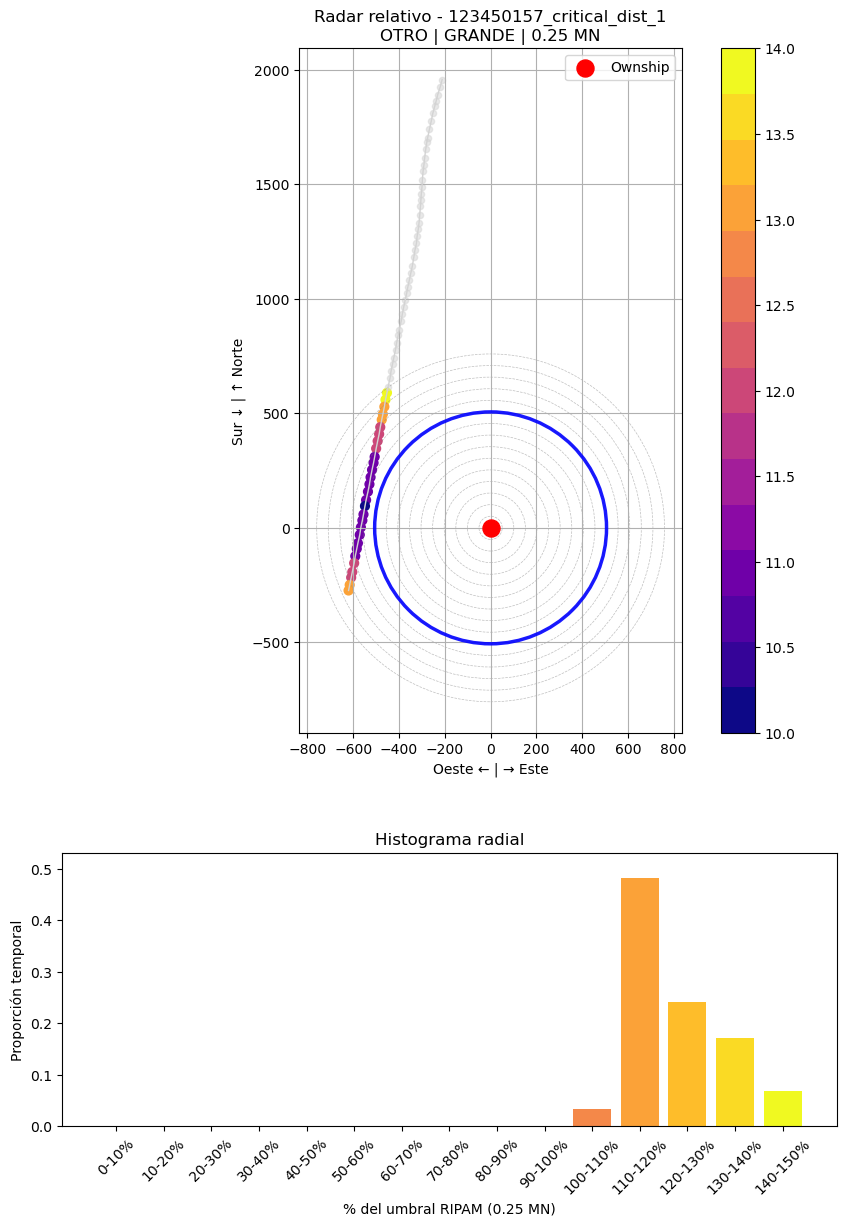


Procesando 123450166_critical_dist_1.csv
  Situación RIPAM: OTRO
  Eslora representativa: 136.0 m
  Categoría tamaño: GRANDE
  Umbral referencia: 0.250 MN = 506.3 yd
  ✔ CSV hist + imágenes generadas
  % fuera de rango (>150%): 61.1%
🖼️ Guardado combinado: figuras\histogramas_radiales\123450166_critical_dist_1_radar_hist.png


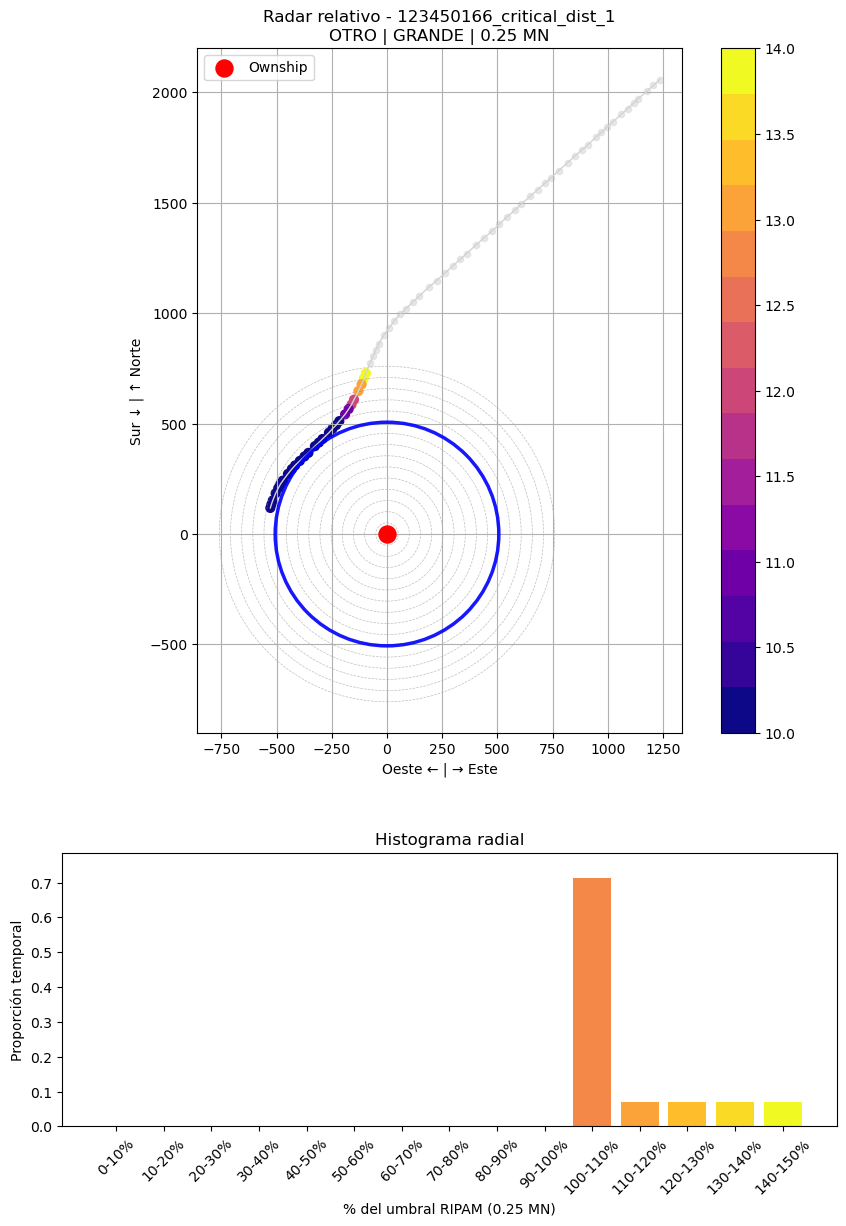


=== FIN BLOQUE ÚNICO RADAR + HISTOGRAMAS RADIALES ===


In [206]:
# =====================================================
# BLOQUE ÚNICO – HISTOGRAMA RADIAL + RADAR + FIGURA COMBINADA
# ADAPTADO: DISTANCIA DE REFERENCIA SEGÚN RIPAM + ESLORA
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os
from pathlib import Path

# ==============================
# CONFIGURACIÓN
# ==============================
CONTACTS_DIR = "critical_sections_ripam_proa_delta"

OUTPUT_FIG_DIR = Path("figuras/contactos_radar")
OUTPUT_HIST_DIR = Path("histogramas_radiales")
FIG_DIR = Path("figuras/histogramas_radiales")

incremento_pct = 0.10
extension_factor = 1.5  # 150%

OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_HIST_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# =====================================================
# CONVERSIONES
# =====================================================
YD_PER_NM = 2025.3718

# =====================================================
# CORTE DE ESLORA PARA CLASIFICAR TAMAÑO
# AJÚSTALO A TU CRITERIO
# =====================================================
ESLORA_UMBRAL_GRANDE_M = 50.0

# =====================================================
# UMBRALES MANUALES (MN)
# Puedes dejar uno o dos valores en la tupla:
#   (0.25,)          -> usa 0.25
#   (0.25, 0.50)     -> usa el mayor válido
# Si el segundo valor no existe, no pasa nada.
# =====================================================
UMBRALES_RANGO_MN = {
    "PEQUEÑO": {
        "ALCANCE": (0.25,),
        "VUELTA_ENCONTRADA": (0.25,),
        "CRUCE_ER": (0.25,),
        "CRUCE_BR": (0.25,),
        "OTRO": (0.25,),
    },
    "GRANDE": {
        "ALCANCE": (0.25,),
        "VUELTA_ENCONTRADA": (0.25,),
        "CRUCE_ER": (0.25,),
        "CRUCE_BR": (0.25,),
        "OTRO": (0.25,),
    }
}

DEFAULT_DISTANCE_MN = 0.25


# =====================================================
# HELPERS
# =====================================================
def normalizar_ripam(valor):
    if pd.isna(valor):
        return "OTRO"

    v = str(valor).strip().upper()

    equivalencias = {
        "HEAD_ON": "VUELTA_ENCONTRADA",
        "VUELTA": "VUELTA_ENCONTRADA",
        "ENCUENTRO": "VUELTA_ENCONTRADA",
        "OVERTAKING": "ALCANCE",
        "ADELANTAMIENTO": "ALCANCE",
        "CRUCE POR ESTRIBOR": "CRUCE_ER",
        "CRUCE POR BABOR": "CRUCE_BR",
        "CRUCE_ER_ER": "CRUCE_ER",
        "CRUCE_BR_BR": "CRUCE_BR",
    }

    return equivalencias.get(v, v if v in {"ALCANCE", "VUELTA_ENCONTRADA", "CRUCE_ER", "CRUCE_BR"} else "OTRO")


def obtener_situacion_representativa(df):
    """
    Usa la moda de la columna ripam.
    """
    if "ripam" not in df.columns:
        return "OTRO"

    s = df["ripam"].dropna().astype(str).map(normalizar_ripam)
    if s.empty:
        return "OTRO"

    return s.mode().iloc[0]


def obtener_eslora_representativa_m(df):
    """
    Usa la mediana de la eslora del contacto.
    """
    if "length" not in df.columns:
        return np.nan

    s = pd.to_numeric(df["length"], errors="coerce").dropna()
    if s.empty:
        return np.nan

    return float(s.median())


def clasificar_tamano_por_eslora(eslora_m, umbral_grande_m=ESLORA_UMBRAL_GRANDE_M):
    if pd.isna(eslora_m):
        return "PEQUEÑO"  # fallback conservador

    return "GRANDE" if eslora_m >= umbral_grande_m else "PEQUEÑO"


def extraer_distancia_mn_desde_tupla(valor, default_mn=DEFAULT_DISTANCE_MN):
    """
    Acepta:
      - número
      - tupla/lista con 1 o 2 elementos
    Toma el mayor valor válido.
    """
    if isinstance(valor, (int, float, np.integer, np.floating)):
        return float(valor)

    if isinstance(valor, (tuple, list)):
        vals = []
        for x in valor:
            try:
                if x is not None and not pd.isna(x):
                    vals.append(float(x))
            except Exception:
                pass

        if len(vals) > 0:
            return max(vals)

    return float(default_mn)


def obtener_umbral_referencia(df):
    """
    Devuelve:
    - situacion_ripam
    - eslora_representativa_m
    - categoria_tamano
    - distancia_referencia_mn
    - distancia_referencia_yd
    """
    situacion = obtener_situacion_representativa(df)
    eslora_m = obtener_eslora_representativa_m(df)
    categoria = clasificar_tamano_por_eslora(eslora_m)

    valor_dict = (
        UMBRALES_RANGO_MN
        .get(categoria, {})
        .get(situacion, UMBRALES_RANGO_MN.get(categoria, {}).get("OTRO", (DEFAULT_DISTANCE_MN,)))
    )

    distancia_mn = extraer_distancia_mn_desde_tupla(valor_dict, DEFAULT_DISTANCE_MN)
    distancia_yd = distancia_mn * YD_PER_NM

    return situacion, eslora_m, categoria, distancia_mn, distancia_yd


# =====================================================
# LOOP
# =====================================================
for filepath in sorted(glob.glob(os.path.join(CONTACTS_DIR, "*.csv"))):

    df = pd.read_csv(filepath)

    if "time" not in df.columns:
        continue

    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)

    if df.empty:
        continue

    nombre_base = os.path.splitext(os.path.basename(filepath))[0]
    print(f"\nProcesando {os.path.basename(filepath)}")

    # =====================================================
    # 1) UMBRAL DINÁMICO SEGÚN RIPAM + ESLORA
    # =====================================================
    situacion_ripam, eslora_m, categoria_tamano, distancia_ref_mn, DCPA_THRESHOLD_YD = obtener_umbral_referencia(df)

    print(f"  Situación RIPAM: {situacion_ripam}")
    print(f"  Eslora representativa: {eslora_m:.1f} m" if not pd.isna(eslora_m) else "  Eslora representativa: NaN")
    print(f"  Categoría tamaño: {categoria_tamano}")
    print(f"  Umbral referencia: {distancia_ref_mn:.3f} MN = {DCPA_THRESHOLD_YD:.1f} yd")

    # Bins porcentuales sobre el umbral dinámico
    bins_pct = np.arange(0, extension_factor + incremento_pct, incremento_pct)
    n_bins = len(bins_pct) - 1

    # =====================================================
    # 2) RECONSTRUCCIÓN RADAR
    # =====================================================
    bearing_rel = pd.to_numeric(df["bearing"], errors="coerce")
    r = pd.to_numeric(df["distance"], errors="coerce")
    heading_own = pd.to_numeric(df["cog_deg_ship"], errors="coerce")

    mask_base = bearing_rel.notna() & r.notna() & heading_own.notna()
    df_plot = df.loc[mask_base].copy()

    if df_plot.empty:
        print("  ⚠ Sin datos válidos para radar/histograma.")
        continue

    bearing_rel = bearing_rel[mask_base].astype(float).to_numpy()
    r = r[mask_base].astype(float).to_numpy()
    heading_own = heading_own[mask_base].astype(float).to_numpy()

    bearing_abs = (heading_own + bearing_rel) % 360
    theta = np.deg2rad(bearing_abs)

    x = r * np.sin(theta)
    y = r * np.cos(theta)

    # =====================================================
    # 3) CÁLCULO RADIAL + HISTOGRAMA
    # =====================================================
    radio_real = np.sqrt(x**2 + y**2)
    radio_pct = radio_real / DCPA_THRESHOLD_YD

    cluster_pct = np.digitize(radio_pct, bins_pct) - 1
    cluster_pct[radio_pct > extension_factor] = -1

    mask_valid = cluster_pct >= 0

    if np.sum(mask_valid) == 0:
        hist_pct = np.zeros(n_bins)
    else:
        hist_counts = (
            pd.Series(cluster_pct[mask_valid])
            .value_counts()
            .sort_index()
            .reindex(range(n_bins), fill_value=0)
        )
        hist_pct = (hist_counts / np.sum(mask_valid)).values

    pct_fuera_rango = float(np.mean(radio_pct > extension_factor))

    df_hist = pd.DataFrame({
        "ripam_referencia": [situacion_ripam] * n_bins,
        "eslora_representativa_m": [eslora_m] * n_bins,
        "categoria_tamano": [categoria_tamano] * n_bins,
        "distancia_referencia_mn": [distancia_ref_mn] * n_bins,
        "distancia_referencia_yd": [DCPA_THRESHOLD_YD] * n_bins,
        "bin_inicio_pct": bins_pct[:-1] * 100,
        "bin_fin_pct": bins_pct[1:] * 100,
        "bin_inicio_mn": bins_pct[:-1] * distancia_ref_mn,
        "bin_fin_mn": bins_pct[1:] * distancia_ref_mn,
        "bin_inicio_yd": bins_pct[:-1] * DCPA_THRESHOLD_YD,
        "bin_fin_yd": bins_pct[1:] * DCPA_THRESHOLD_YD,
        "proporcion_tiempo": hist_pct,
        "pct_fuera_rango": [pct_fuera_rango] * n_bins
    })

    output_hist_path = OUTPUT_HIST_DIR / f"{nombre_base}_histograma_radial.csv"
    df_hist.to_csv(output_hist_path, index=False)

    # =====================================================
    # 4) GUARDAR IMAGEN HISTOGRAMA
    # =====================================================
    fig_h, ax_h = plt.subplots(figsize=(10, 4))

    ax_h.bar(
        range(n_bins),
        hist_pct,
        color=plt.get_cmap("plasma", n_bins).colors
    )

    ax_h.set_xticks(range(n_bins))
    ax_h.set_xticklabels(
        [f"{int(bins_pct[i]*100)}-{int(bins_pct[i+1]*100)}%"
         for i in range(n_bins)],
        rotation=45
    )

    ax_h.set_xlabel(f"% del umbral RIPAM ({distancia_ref_mn:.2f} MN)")
    ax_h.set_ylabel("Proporción temporal")
    ax_h.set_title(f"Histograma radial - {nombre_base} ({situacion_ripam}, {categoria_tamano})")

    ax_h.set_ylim(0, max(hist_pct) * 1.1 if max(hist_pct) > 0 else 1)

    plt.tight_layout()

    img_output = OUTPUT_HIST_DIR / f"{nombre_base}_histograma_radial.png"
    plt.savefig(img_output, dpi=300)
    plt.close(fig_h)

    # =====================================================
    # 5) GUARDAR IMAGEN RADAR
    # =====================================================
    fig_r, ax1_r = plt.subplots(figsize=(8, 8))

    ax1_r.plot(x, y, color="lightgray", linewidth=1)

    cmap_clusters = plt.get_cmap("plasma", n_bins)

    scatter_r = ax1_r.scatter(
        x[mask_valid],
        y[mask_valid],
        c=cluster_pct[mask_valid],
        cmap=cmap_clusters,
        s=40
    )

    ax1_r.scatter(
        x[~mask_valid],
        y[~mask_valid],
        color="lightgray",
        s=20,
        alpha=0.5
    )

    for r_circle in bins_pct[1:] * DCPA_THRESHOLD_YD:
        circle = plt.Circle(
            (0, 0),
            r_circle,
            color="gray",
            fill=False,
            linestyle="--",
            linewidth=0.5,
            alpha=0.5
        )
        ax1_r.add_patch(circle)

    ax1_r.set_aspect("equal")
    ax1_r.set_xlim(-DCPA_THRESHOLD_YD * extension_factor,
                   DCPA_THRESHOLD_YD * extension_factor)
    ax1_r.set_ylim(-DCPA_THRESHOLD_YD * extension_factor,
                   DCPA_THRESHOLD_YD * extension_factor)

    ax1_r.set_title(f"Radar relativo ({situacion_ripam}, {categoria_tamano})")

    fig_r.colorbar(scatter_r, ax=ax1_r)

    output_fig_path = OUTPUT_FIG_DIR / f"{nombre_base}_radar.png"
    plt.savefig(output_fig_path, dpi=300, bbox_inches="tight")
    plt.close(fig_r)

    print(f"  ✔ CSV hist + imágenes generadas")
    print(f"  % fuera de rango (>150%): {pct_fuera_rango*100:.1f}%")

    # =====================================================
    # 6) FIGURA COMBINADA (RADAR + HIST)
    # =====================================================
    df_hist_read = pd.read_csv(output_hist_path)
    hist_pct_read = df_hist_read["proporcion_tiempo"].values

    fig = plt.figure(figsize=(10, 14))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1.2], hspace=0.25)

    # ===================== RADAR =====================
    ax1 = fig.add_subplot(gs[0])

    ax1.plot(x, y, color="lightgray", linewidth=1)

    cmap_clusters = plt.get_cmap("plasma", n_bins)

    scatter = ax1.scatter(
        x[mask_valid],
        y[mask_valid],
        c=cluster_pct[mask_valid],
        cmap=cmap_clusters,
        s=40
    )

    ax1.scatter(
        x[~mask_valid],
        y[~mask_valid],
        color="lightgray",
        s=20,
        alpha=0.5
    )

    ax1.scatter(0, 0, color="red", s=150, zorder=5, label="Ownship")

    for r_circle in bins_pct[1:] * DCPA_THRESHOLD_YD:
        circle = plt.Circle(
            (0, 0),
            r_circle,
            color="gray",
            fill=False,
            linestyle="--",
            linewidth=0.5,
            alpha=0.5
        )
        ax1.add_patch(circle)

    circle_ref = plt.Circle(
        (0, 0),
        DCPA_THRESHOLD_YD,
        color="blue",
        fill=False,
        linestyle="-",
        linewidth=2.5,
        alpha=0.9,
        zorder=4
    )
    ax1.add_patch(circle_ref)

    ax1.set_aspect("equal")
    ax1.grid(True)
    ax1.set_title(
        f"Radar relativo - {nombre_base}\n"
        f"{situacion_ripam} | {categoria_tamano} | {distancia_ref_mn:.2f} MN"
    )
    ax1.set_xlabel("Oeste ← | → Este")
    ax1.set_ylabel("Sur ↓ | ↑ Norte")

    fig.colorbar(scatter, ax=ax1)
    ax1.legend()

    # ===================== HISTOGRAMA =====================
    ax2 = fig.add_subplot(gs[1])

    ax2.bar(
        range(n_bins),
        hist_pct_read,
        color=plt.get_cmap("plasma", n_bins).colors
    )

    ax2.set_xticks(range(n_bins))
    ax2.set_xticklabels(
        [f"{int(bins_pct[i]*100)}-{int(bins_pct[i+1]*100)}%"
         for i in range(n_bins)],
        rotation=45
    )

    ax2.set_xlabel(f"% del umbral RIPAM ({distancia_ref_mn:.2f} MN)")
    ax2.set_ylabel("Proporción temporal")
    ax2.set_title("Histograma radial")

    ax2.set_ylim(0, max(hist_pct_read) * 1.1 if max(hist_pct_read) > 0 else 1)

    out_path = FIG_DIR / f"{nombre_base}_radar_hist.png"
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    print(f"🖼️ Guardado combinado: {out_path}")

    plt.show()
    plt.close(fig)

print("\n=== FIN BLOQUE ÚNICO RADAR + HISTOGRAMAS RADIALES ===")

In [207]:
# =====================================================
# BLOQUE — EVALUACIÓN POR HISTOGRAMA (MÚLTIPLES BINS) + MANIOBRA/DIRECCIÓN
# (SIN MEDIAS -> "peor zona" + permanencias)
# + Penalización CPA decreciente
# + Penalización corte de proa (excepto CRUCE_BR y VUELTA_ENCONTRADA)
#
# HISTOGRAMA:
#   - Ponderado por TIEMPO (columna time)
#   - 100% = DISTANCIA CRÍTICA DEL CASO (según RIPAM + tamaño)
#
# =====================================================

import os, glob
import numpy as np
import pandas as pd

YD_PER_NM = 2025.3718
COND_CRIT_MN = 0.25

# Penalizaciones de maniobra/dirección
PENAL_NO_MANIOBRA = 0.70
PENAL_MANIOBRA_INNECESARIA = 0.93
PENAL_DIRECCION_INCORRECTA = 0.85

# Penalizaciones adicionales
PENAL_CPA_DECRECIENTE = 0.90
PENAL_CORTE_PROA = 0.85

# Penalización del histograma
PENAL_BAJO_CRIT = 0.35

# Umbrales manuales (MN) — rango [min, max]
UMBRALES_RANGO_MN = {
    "PEQUEÑO": {
        "ALCANCE": (0.25, 0.50),
        "VUELTA_ENCONTRADA": (0.25, 0.50),
        "CRUCE_ER": (0.25, 0.50),
        "CRUCE_BR": (0.25, 0.50),
        "OTRO": (0.25, 0.50),
    },
    "GRANDE": {
        "ALCANCE": (0.25, 0.50),
        "VUELTA_ENCONTRADA": (0.25, 0.50),
        "CRUCE_ER": (0.25, 0.75),
        "CRUCE_BR": (0.25, 0.50),
        "OTRO": (0.25, 0.55),
    }
}

# ---- Configuración de bins del histograma (% de la distancia crítica del caso)
BIN_STEP = 10
BIN_MAX = 150
BIN_EDGES = np.arange(0, BIN_MAX + BIN_STEP, BIN_STEP)  # 0..150
BIN_LABELS = [f"{BIN_EDGES[i]}_{BIN_EDGES[i+1]}" for i in range(len(BIN_EDGES)-1)]


# ----------------------------
# Helpers
# ----------------------------
def _to_float(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan

def _to_bool(x):
    if isinstance(x, bool):
        return x
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return False
    s = str(x).strip().lower()
    return s in ("true", "1", "si", "sí", "yes", "y", "t")

def _norm_ripam(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "NO_CLASIFICADO"
    s = str(x).strip().upper()
    return s.replace(" ", "_").replace("-", "_")


# ----------------------------
# RIPAM / tipo / tamaño / banda
# ----------------------------
def obligacion_maniobra_por_ripam(ripam_dom: str) -> str:
    r = _norm_ripam(ripam_dom)
    if r == "CRUCE_ER":
        return "YES"
    if r == "CRUCE_BR":
        return "NO"
    if r in ("CRUCE_ER_ER", "CRUCE_BR_BR"):
        return "NO"
    if r == "VUELTA_ENCONTRADA":
        return "YES"
    if r in ("ALCANZANDO", "ALCANCE"):
        return "YES"
    if r == "ALCANZADO":
        return "NO"
    if r in ("FONDEADO", "NO_CLASIFICADO"):
        return "COND"
    if r == "ALEJAMIENTO":
        return "NO"
    return "COND"

def tipo_umbral_por_ripam(ripam_dom: str) -> str:
    r = _norm_ripam(ripam_dom)
    if r in ("ALCANZANDO", "ALCANCE", "ALCANZADO"):
        return "ALCANCE"
    if r == "VUELTA_ENCONTRADA":
        return "VUELTA_ENCONTRADA"
    if r in ("CRUCE_ER", "CRUCE_ER_ER"):
        return "CRUCE_ER"
    if r in ("CRUCE_BR", "CRUCE_BR_BR"):
        return "CRUCE_BR"
    return "OTRO"

def clasificar_tamano_contacto(length, umbral_length_m=100.0):
    # si no hay dato -> GRANDE
    if length is None or (isinstance(length, float) and np.isnan(length)):
        return "GRANDE"
    return "GRANDE" if float(length) >= umbral_length_m else "PEQUEÑO"

def extraer_banda_maniobra(df: pd.DataFrame) -> str:
    col = "sentido_giro_propio_pre_evento"
    if col not in df.columns or pd.isna(df[col].iloc[0]):
        return "DESCONOCIDA"
    v = str(df[col].iloc[0]).strip().upper()
    if v in ("E", "ER", "ESTRIBOR", "STARBOARD", "STBD", "SB") or "ESTRIBOR" in v or "STBD" in v:
        return "ESTRIBOR"
    if v in ("B", "BR", "BABOR", "PORT") or "BABOR" in v or "PORT" in v:
        return "BABOR"
    return "DESCONOCIDA"


# =====================================================
# Penalización 1: CPA decreciente
# =====================================================
def detectar_cpa_decreciente(df: pd.DataFrame, min_n=8, min_drop_rel=0.15):
    candidates = [
        "cpa", "CPA", "cpa_nm", "cpa_mn", "cpa_yd", "cpa_yardas",
        "dcpa", "DCPA", "dcpa_nm", "dcpa_mn", "dcpa_yd"
    ]
    col = next((c for c in candidates if c in df.columns), None)
    if col is None:
        return False, "CPA:no_col"

    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if len(s) < min_n:
        return False, f"CPA:pocos_datos(n={len(s)})"

    y = s.values.astype(float)
    x = np.arange(len(y), dtype=float)

    x_mean = x.mean()
    y_mean = y.mean()
    denom = np.sum((x - x_mean) ** 2)
    slope = 0.0 if denom == 0 else np.sum((x - x_mean) * (y - y_mean)) / denom

    start = float(y[0])
    end = float(y[-1])
    drop_rel = (start - end) / max(abs(start), 1e-9)

    flag = (slope < 0) and (drop_rel >= min_drop_rel)
    info = f"CPA:{col}|slope={slope:.4g}|drop_rel={drop_rel:.3f}|start={start:.3f}|end={end:.3f}"
    return bool(flag), info


# =====================================================
# Penalización 2: Corte de proa
# =====================================================
def detectar_corte_proa(df: pd.DataFrame):
    col = "corto_proa_evento"

    if col not in df.columns:
        return False, "CORTE_PROA:corto_proa_evento=NO_COL"

    v = df[col]
    v_nonan = v[pd.notna(v)]
    if len(v_nonan) == 0:
        return False, "CORTE_PROA:corto_proa_evento=NO_DATA"

    flag = bool(pd.Series(v_nonan).apply(_to_bool).any())
    return flag, f"CORTE_PROA:corto_proa_evento={flag}"


# =====================================================
# UTILIDAD DEL PEOR BIN
# pct = centro del bin en % respecto a la distancia crítica del caso
# =====================================================
def utilidad_bin_center_10(pct):
    if pct <= 50.0:
        return 0.0

    if pct < 100.0:
        return 10.0 * (pct - 50.0) / 50.0

    return 10.0

def histograma_time_peor_zona(df: pd.DataFrame, ref_hist_yd: float, eps=0.01):
    probs = {f"hist_{lab}": np.nan for lab in BIN_LABELS}

    if "distance" not in df.columns:
        return probs, np.nan, np.nan, None, np.nan, np.nan, 6.0, "NO_DISTANCE"

    if not np.isfinite(ref_hist_yd) or ref_hist_yd <= 0:
        return probs, np.nan, np.nan, None, np.nan, np.nan, 6.0, "BAD_REFERENCE"

    dist_yd = pd.to_numeric(df["distance"], errors="coerce")

    if "time" in df.columns:
        t = pd.to_datetime(df["time"], errors="coerce")
    else:
        t = pd.Series([pd.NaT] * len(df))

    mask = dist_yd.notna() & t.notna()

    # fallback sin time válido: pesos uniformes
    if mask.sum() < 2:
        d = dist_yd.dropna().to_numpy(dtype=float)
        if len(d) == 0:
            return probs, np.nan, np.nan, None, np.nan, np.nan, 6.0, "NO_VALID_DATA"

        ratio_pct = 100.0 * (d / ref_hist_yd)
        ratio_mean_pct = float(np.mean(ratio_pct))
        ratio_pct_clip = np.clip(ratio_pct, 0, BIN_MAX)

        hist, _ = np.histogram(ratio_pct_clip, bins=BIN_EDGES)
        probs_arr = hist / max(hist.sum(), 1)

        for i, lab in enumerate(BIN_LABELS):
            probs[f"hist_{lab}"] = float(probs_arr[i])

        dist_min_nm = float(np.min(d) / YD_PER_NM)

        # tiempo bajo el umbral crítico => pct < 100
        p_bajo_crit = float(np.sum(probs_arr[(BIN_EDGES[1:] <= 100)]))

        peor_idx = next((i for i in range(len(BIN_LABELS)) if probs_arr[i] >= eps), None)
        if peor_idx is None:
            peor_bin = "MIN_REAL"
            peor_prob = float(np.max(probs_arr))
            peor_center = float(np.min(ratio_pct_clip))
        else:
            peor_bin = BIN_LABELS[peor_idx]
            peor_prob = float(probs_arr[peor_idx])
            peor_center = (BIN_EDGES[peor_idx] + BIN_EDGES[peor_idx + 1]) / 2.0

        score = utilidad_bin_center_10(peor_center)
        score *= (1.0 - PENAL_BAJO_CRIT * p_bajo_crit)
        score = float(np.clip(score, 0.0, 10.0))

        return probs, dist_min_nm, ratio_mean_pct, peor_bin, peor_prob, p_bajo_crit, score, "UNIFORM"

    # datos válidos con time
    dfv = pd.DataFrame({
        "time": t[mask],
        "distance": dist_yd[mask]
    }).sort_values("time").reset_index(drop=True)

    dt = (dfv["time"].shift(-1) - dfv["time"]).dt.total_seconds().to_numpy()
    dt_pos = dt[np.isfinite(dt) & (dt > 0)]
    last_dt = float(np.median(dt_pos)) if len(dt_pos) else 1.0
    dt[-1] = last_dt
    dt = np.where(np.isfinite(dt) & (dt > 0), dt, last_dt)

    d = dfv["distance"].to_numpy(dtype=float)
    dist_min_nm = float(np.min(d) / YD_PER_NM)

    ratio_pct = 100.0 * (d / ref_hist_yd)
    ratio_mean_pct = float(np.mean(ratio_pct))
    ratio_pct_clip = np.clip(ratio_pct, 0, BIN_MAX)

    hist_w, _ = np.histogram(ratio_pct_clip, bins=BIN_EDGES, weights=dt)
    probs_arr = hist_w / max(hist_w.sum(), 1e-9)

    for i, lab in enumerate(BIN_LABELS):
        probs[f"hist_{lab}"] = float(probs_arr[i])

    # tiempo bajo el umbral crítico => pct < 100
    p_bajo_crit = float(np.sum(probs_arr[(BIN_EDGES[1:] <= 100)]))

    peor_idx = next((i for i in range(len(BIN_LABELS)) if probs_arr[i] >= eps), None)
    if peor_idx is None:
        peor_bin = "MIN_REAL"
        peor_prob = float(np.max(probs_arr))
        peor_center = float(np.min(ratio_pct_clip))
    else:
        peor_bin = BIN_LABELS[peor_idx]
        peor_prob = float(probs_arr[peor_idx])
        peor_center = (BIN_EDGES[peor_idx] + BIN_EDGES[peor_idx + 1]) / 2.0

    score = utilidad_bin_center_10(peor_center)
    score *= (1.0 - PENAL_BAJO_CRIT * p_bajo_crit)
    score = float(np.clip(score, 0.0, 10.0))

    return probs, dist_min_nm, ratio_mean_pct, peor_bin, peor_prob, p_bajo_crit, score, "TIME_WEIGHTED"


# =====================================================
# Evaluación evento completa
# =====================================================
def evaluar_evento(df: pd.DataFrame, fp: str):
    ripam = _norm_ripam(df["ripam"].iloc[0] if "ripam" in df.columns else "NO_CLASIFICADO")
    oblig = obligacion_maniobra_por_ripam(ripam)
    tipo = tipo_umbral_por_ripam(ripam)

    # maniobra
    mani_col = None
    for c in ("maniobra_propio_pre_evento_total", "maniobra_total"):
        if c in df.columns:
            mani_col = c
            break
    maniobra_total = _to_bool(df[mani_col].iloc[0]) if mani_col else False

    # tamaño y umbral específico
    length = _to_float(df["length"].iloc[0]) if "length" in df.columns else np.nan
    tam = clasificar_tamano_contacto(length)
    rmin, rmax = UMBRALES_RANGO_MN[tam].get(tipo, UMBRALES_RANGO_MN[tam]["OTRO"])

    # 100% del histograma = distancia crítica del caso
    ref_hist_yd = rmin * YD_PER_NM
    crit_pct = 100.0

    probs, dist_min_nm, ratio_mean_pct, peor_bin, peor_prob, p_bajo_crit, score, hist_weighting = \
        histograma_time_peor_zona(df, ref_hist_yd=ref_hist_yd, eps=0.01)

    # debe maniobrar
    if oblig == "YES":
        debe = True
    elif oblig == "NO":
        debe = False
    else:
        debe = (not np.isnan(dist_min_nm)) and (dist_min_nm < COND_CRIT_MN)

    etiqueta = "OK"

    # penalizaciones por maniobra
    if debe and (not maniobra_total):
        score *= PENAL_NO_MANIOBRA
        etiqueta = "FALTA_MANIOBRA"
    elif (not debe) and maniobra_total:
        score *= PENAL_MANIOBRA_INNECESARIA
        etiqueta = "MANIOBRA_INNECESARIA"

    # dirección SOLO CRUCE_ER y VUELTA_ENCONTRADA -> ESTRIBOR
    banda = extraer_banda_maniobra(df)
    if maniobra_total and banda != "DESCONOCIDA":
        if ripam in ("CRUCE_ER", "VUELTA_ENCONTRADA") and banda != "ESTRIBOR":
            score *= PENAL_DIRECCION_INCORRECTA
            etiqueta = "MANIOBRA_DIRECCION_INCORRECTA"

    # CPA decreciente
    cpa_decr, cpa_info = detectar_cpa_decreciente(df)
    if cpa_decr:
        score *= PENAL_CPA_DECRECIENTE
        etiqueta = (etiqueta + "|CPA_DECRECIENTE") if etiqueta else "CPA_DECRECIENTE"

    # corte de proa
    corte_proa, proa_info = detectar_corte_proa(df)
    if corte_proa and (ripam not in ("CRUCE_BR", "CRUCE_BR_BR", "VUELTA_ENCONTRADA")):
        score *= PENAL_CORTE_PROA
        etiqueta = (etiqueta + "|CORTE_PROA") if etiqueta else "CORTE_PROA"

    score = float(np.clip(score, 0.0, 10.0))

    if score >= 8.0:
        clase = "SEGURA"
    elif score >= 5.5:
        clase = "ACEPTABLE"
    elif score >= 3.5:
        clase = "JUSTA"
    else:
        clase = "PELIGROSA"

    base = {
        "archivo": os.path.basename(fp),
        "mmsi": df["mmsi"].iloc[0] if "mmsi" in df.columns else None,
        "ripam_dom": ripam,
        "tipo_umbral": tipo,
        "tamano_contacto": tam,

        # trazabilidad
        "rango_min_mn": rmin,
        "rango_max_mn": rmax,
        "ref_hist_yd_100pct": ref_hist_yd,
        "crit_pct": round(crit_pct, 2),
        "hist_weighting": hist_weighting,

        # hist-métricas
        "dist_min_nm": dist_min_nm,
        "ratio_mean_pct": ratio_mean_pct,
        "peor_bin": peor_bin,
        "peor_bin_prob": round(peor_prob, 3) if pd.notna(peor_prob) else np.nan,
        "p_bajo_crit": round(p_bajo_crit, 3) if pd.notna(p_bajo_crit) else np.nan,

        # maniobra
        "obligacion_maniobra": oblig,
        "debe_maniobrar": bool(debe),
        "maniobra_total": maniobra_total,
        "banda_maniobra": banda,

        # penalizaciones extra
        "cpa_decreciente": bool(cpa_decr),
        "cpa_info": cpa_info,
        "corte_proa": bool(corte_proa),
        "corte_proa_info": proa_info,

        "etiqueta_maniobra": etiqueta,
        "seguridad_score_10": round(score, 2),
        "seguridad_clase": clase,
    }

    base.update(probs)
    return base


# =====================================================
# LOTE carpeta
# =====================================================
INPUT_DIR = "critical_sections_ripam_proa_delta"
files = sorted(glob.glob(os.path.join(INPUT_DIR, "*.csv")))
files = [
    f for f in files
    if ("critical_dist" in os.path.basename(f).lower())
    and (not os.path.basename(f).lower().startswith("evaluacion_"))
]

if not files:
    raise FileNotFoundError(f"No hay CSVs en {INPUT_DIR}")

rows = []
for fp in files:
    df = pd.read_csv(fp)
    if df.empty:
        continue
    rows.append(evaluar_evento(df, fp))

df_out = pd.DataFrame(rows).sort_values("seguridad_score_10", ascending=True).reset_index(drop=True)

out_path = os.path.join(INPUT_DIR, "evaluacion_seguridad_hist_bins.csv")
df_out.to_csv(out_path, index=False)

print(f"✅ Evaluados {len(df_out)} eventos. Guardado: {out_path}")

cols_show = [
    "archivo", "ripam_dom", "tipo_umbral", "tamano_contacto", "dist_min_nm",
    "crit_pct", "p_bajo_crit",
    "peor_bin", "peor_bin_prob",
    "obligacion_maniobra", "debe_maniobrar",
    "maniobra_total", "banda_maniobra",
    "cpa_decreciente", "corte_proa",
    "etiqueta_maniobra", "seguridad_score_10", "seguridad_clase"
]
cols_show = [c for c in cols_show if c in df_out.columns]
display(df_out[cols_show].head(30))

✅ Evaluados 4 eventos. Guardado: critical_sections_ripam_proa_delta\evaluacion_seguridad_hist_bins.csv


,archivo,ripam_dom,tipo_umbral,tamano_contacto,dist_min_nm,crit_pct,p_bajo_crit,peor_bin,peor_bin_prob,obligacion_maniobra,debe_maniobrar,maniobra_total,banda_maniobra,cpa_decreciente,corte_proa,etiqueta_maniobra,seguridad_score_10,seguridad_clase
0,123450121_critical_dist_1.csv,FONDEADO,OTRO,PEQUEÑO,0.384774,100.0,0.0,140_150,1.000,COND,False,True,BABOR,True,False,MANIOBRA_INNECESARIA|CPA_DECRECIENTE,8.37,SEGURA
1,123450157_critical_dist_1.csv,FONDEADO,OTRO,GRANDE,0.274927,100.0,0.0,100_110,0.016,COND,False,True,BABOR,True,False,MANIOBRA_INNECESARIA|CPA_DECRECIENTE,8.37,SEGURA
2,123450166_critical_dist_1.csv,FONDEADO,OTRO,GRANDE,0.252561,100.0,0.0,100_110,0.272,COND,False,True,BABOR,True,False,MANIOBRA_INNECESARIA|CPA_DECRECIENTE,8.37,SEGURA
3,123450098_critical_dist_1.csv,CRUCE_ER,CRUCE_ER,PEQUEÑO,0.357391,100.0,0.0,140_150,1.000,YES,True,True,ESTRIBOR,False,False,OK,10.00,SEGURA


In [208]:
# =====================================================
# IMPRESIÓN DE TODAS LAS NOTAS OBTENIDAS (ordenadas)
# Pégalo al FINAL del bloque, cuando ya exista df_out
# =====================================================

if "df_out" in globals() and isinstance(df_out, pd.DataFrame) and len(df_out) > 0:

    cols = [
        "archivo",
        "mmsi",
        "ripam_dom",
        "tipo_umbral",
        "tamano_contacto",
        "seguridad_score_10",
        "seguridad_clase",
        "etiqueta_maniobra"
    ]
    cols = [c for c in cols if c in df_out.columns]

    df_print = df_out[cols].copy()

    # Orden: peor a mejor (nota más baja arriba)
    df_print = df_print.sort_values("seguridad_score_10", ascending=True).reset_index(drop=True)

    print("\n" + "="*90)
    print("NOTAS OBTENIDAS POR EVENTO (0–10) — ORDENADAS DE PEOR A MEJOR")
    print("="*90)

    # Ancho de impresión
    with pd.option_context("display.max_rows", None,
                           "display.max_columns", None,
                           "display.width", 200,
                           "display.max_colwidth", 60):
        print(df_print.to_string(index=True))

    # Resumen rápido
    print("\n" + "-"*90)
    print(f"Total eventos: {len(df_print)}")
    if "seguridad_score_10" in df_print.columns:
        print(f"Nota mínima:  {df_print['seguridad_score_10'].min():.2f}")
        print(f"Nota media:   {df_print['seguridad_score_10'].mean():.2f}")
        print(f"Nota máxima:  {df_print['seguridad_score_10'].max():.2f}")
    print("-"*90 + "\n")

else:
    print("⚠️ No existe df_out o está vacío. Ejecuta primero el bloque principal.")


NOTAS OBTENIDAS POR EVENTO (0–10) — ORDENADAS DE PEOR A MEJOR
                         archivo       mmsi ripam_dom tipo_umbral tamano_contacto  seguridad_score_10 seguridad_clase                     etiqueta_maniobra
0  123450121_critical_dist_1.csv  123450121  FONDEADO        OTRO         PEQUEÑO                8.37          SEGURA  MANIOBRA_INNECESARIA|CPA_DECRECIENTE
1  123450157_critical_dist_1.csv  123450157  FONDEADO        OTRO          GRANDE                8.37          SEGURA  MANIOBRA_INNECESARIA|CPA_DECRECIENTE
2  123450166_critical_dist_1.csv  123450166  FONDEADO        OTRO          GRANDE                8.37          SEGURA  MANIOBRA_INNECESARIA|CPA_DECRECIENTE
3  123450098_critical_dist_1.csv  123450098  CRUCE_ER    CRUCE_ER         PEQUEÑO               10.00          SEGURA                                    OK

------------------------------------------------------------------------------------------
Total eventos: 4
Nota mínima:  8.37
Nota media:   8.78
Nota máxim

In [209]:
# Generación PDF
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
from PIL import Image, ImageOps
import numpy as np
import os
import pandas as pd

A4_VERTICAL = (8.27, 11.69)
MAX_WIDTH_PX = 4000
MAX_HEIGHT_PX = 4000


def generar_pdf_final(
    ruta_mapa_general,
    ruta_mapa_filtrado,
    carpeta_base_figuras="figuras",
    nombre_pdf="INFORME_ANALISIS_AIS.pdf",
    ruta_csv_evaluacion="critical_sections_ripam_proa_delta/evaluacion_seguridad_hist_bins.csv"
):

    base = Path(carpeta_base_figuras)
    carpeta_contactos = base / "contactos"
    carpeta_tablas = base / "tablas_eventos"
    carpeta_histogramas = base / "histogramas_radiales"

    ruta_csv_evaluacion = Path(ruta_csv_evaluacion)

    # =====================================================
    # HELPERS
    # =====================================================
    def _to_float(x):
        try:
            if pd.isna(x):
                return None
        except Exception:
            pass
        try:
            return float(str(x).replace(",", "."))
        except Exception:
            return None

    def _as_bool(x):
        if x is None:
            return False
        if isinstance(x, (bool, np.bool_)):
            return bool(x)
        s = str(x).strip().lower()
        if s in ("1", "true", "t", "yes", "si", "sí"):
            return True
        if s in ("0", "false", "f", "no"):
            return False
        return False

    def _si_no(x):
        return "Sí" if _as_bool(x) else "No"

    def _fmt(x, default="—"):
        if x is None:
            return default
        try:
            if pd.isna(x):
                return default
        except Exception:
            pass
        return str(x)

    def _fmt_num(x, nd=2, default="—"):
        v = _to_float(x)
        if v is None or not np.isfinite(v):
            return default
        return f"{v:.{nd}f}"

    def _fmt_pct(x, default="—"):
        v = _to_float(x)
        if v is None or not np.isfinite(v):
            return default
        # si viene 0-1 lo pasamos a 0-100
        if 0 <= v <= 1:
            v = 100 * v
        return f"{v:.1f}%"

    # =====================================================
    # RECORTE ROBUSTO BORDES BLANCOS
    # =====================================================
    def _recortar_bordes_blancos(img: Image.Image, thresh=245, margen_px: int = 12) -> Image.Image:
        img = ImageOps.exif_transpose(img)

        if img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info):
            bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
            img = Image.alpha_composite(bg, img.convert("RGBA")).convert("RGB")
        else:
            if img.mode != "RGB":
                img = img.convert("RGB")

        arr = np.asarray(img)
        h, w = arr.shape[:2]
        mask = np.any(arr < thresh, axis=2)
        coords = np.argwhere(mask)
        if coords.size == 0:
            return img

        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1

        x0 = max(0, x0 - margen_px)
        y0 = max(0, y0 - margen_px)
        x1 = min(w, x1 + margen_px)
        y1 = min(h, y1 + margen_px)

        if (x1 - x0) < 50 or (y1 - y0) < 50:
            return img

        return img.crop((x0, y0, x1, y1))

    # =====================================================
    # PÁGINA CON IMAGEN (FIX “ENANO”)
    # =====================================================
    def _pagina_con_titulo_imagen(pdf, titulo, descripcion, ruta_imagen, num_pagina, recortar=False):
        fig = plt.figure(figsize=A4_VERTICAL)

        fig.text(0.08, 0.96, titulo, fontsize=14, weight="bold")
        fig.text(0.08, 0.93, descripcion, fontsize=10)
        fig.add_artist(plt.Line2D([0.08, 0.92], [0.91, 0.91], color="black", linewidth=0.8))

        box_left, box_bottom, box_w, box_h = 0.06, 0.08, 0.88, 0.80

        if ruta_imagen and os.path.exists(ruta_imagen):
            try:
                with Image.open(ruta_imagen) as img:
                    img = ImageOps.exif_transpose(img)
                    if recortar:
                        img = _recortar_bordes_blancos(img, thresh=245, margen_px=12)

                    img.thumbnail((MAX_WIDTH_PX, MAX_HEIGHT_PX), Image.LANCZOS)
                    img_array = np.array(img)

                img_h, img_w = img_array.shape[:2]
                img_ratio = img_w / img_h if img_h else 1.0

                fig_w_in, fig_h_in = fig.get_size_inches()
                box_ratio = (box_w * fig_w_in) / (box_h * fig_h_in)

                if img_ratio >= box_ratio:
                    width = box_w
                    height = (box_w * fig_w_in / img_ratio) / fig_h_in
                else:
                    height = box_h
                    width = (box_h * fig_h_in * img_ratio) / fig_w_in

                left = box_left + (box_w - width) / 2
                bottom = box_bottom + (box_h - height) / 2

                ax_img = fig.add_axes([left, bottom, width, height])
                ax_img.axis("off")
                ax_img.imshow(img_array, aspect="auto")

            except Exception as e:
                ax_img = fig.add_axes([box_left, box_bottom, box_w, box_h])
                ax_img.axis("off")
                ax_img.text(0.5, 0.5, f"Error cargando imagen:\n{e}",
                            ha="center", va="center", fontsize=10)
        else:
            ax_img = fig.add_axes([box_left, box_bottom, box_w, box_h])
            ax_img.axis("off")
            ax_img.text(0.5, 0.5, "Imagen no encontrada",
                        ha="center", va="center", fontsize=12)

        fig.text(0.5, 0.04, f"Página {num_pagina}", ha="center", fontsize=9)
        pdf.savefig(fig)
        plt.close(fig)

    # =====================================================
    # PÁGINA DE EVALUACIÓN (SIN TEXTO LARGO)
    # =====================================================
    def _pagina_evaluacion_evento(pdf, titulo, descripcion, eval_row, num_pagina):
        fig = plt.figure(figsize=A4_VERTICAL)

        fig.text(0.08, 0.96, titulo, fontsize=14, weight="bold")
        fig.text(0.08, 0.93, descripcion, fontsize=10)
        fig.add_artist(plt.Line2D([0.08, 0.92], [0.91, 0.91], color="black", linewidth=0.8))

        ax = fig.add_axes([0.08, 0.10, 0.84, 0.80])
        ax.axis("off")

        if eval_row is None:
            ax.text(0.0, 0.95, "⚠️ No se encontró la valoración para este evento en el CSV.",
                    fontsize=12, weight="bold")
        else:
            def g(k, default=None):
                return eval_row[k] if (k in eval_row and pd.notna(eval_row[k])) else default

            score = _to_float(g("seguridad_score_10"))
            clase = _fmt(g("seguridad_clase"), "—")

            ripam = _fmt(g("ripam_dom"), "—")
            tam = _fmt(g("tamano_contacto"), "—")
            dist_min_nm = _to_float(g("dist_min_nm"))
            rmin = _to_float(g("rango_min_mn"))
            rmax = _to_float(g("rango_max_mn"))

            oblig = _fmt(g("obligacion_maniobra"), "—")
            debe = g("debe_maniobrar")
            mani = g("maniobra_total")
            banda = _fmt(g("banda_maniobra"), "—")

            peor_bin = _fmt(g("peor_bin"), "—")
            peor_prob = _fmt_pct(g("peor_bin_prob"), "—")

            p_bajo_100 = g("p_bajo_crit")  # % tiempo <100%
            pct_dentro = _fmt_pct(p_bajo_100, "—")

            v_pb = _to_float(p_bajo_100)
            if v_pb is not None and 0 <= v_pb <= 1:
                v_pb = 100 * v_pb
            pct_cumple = f"{(100 - v_pb):.1f}%" if (v_pb is not None and np.isfinite(v_pb)) else "—"

            cpa_decr = g("cpa_decreciente")
            corte_proa = g("corte_proa")

            y = 0.95
            score_txt = f"{score:.1f}/10" if score is not None else "—/10"
            ax.text(0.0, y, f"NOTA FINAL: {score_txt}   →   {clase}", fontsize=16, weight="bold")
            y -= 0.085

            ax.text(0.0, y, "Criterios empleados:", fontsize=12, weight="bold"); y -= 0.055

            ax.text(0.02, y, f"• RIPAM: {ripam}", fontsize=11); y -= 0.048
            ax.text(0.02, y, f"• Tamaño: {tam}", fontsize=11); y -= 0.048
            ax.text(0.02, y, f"• Distancia mínima: {_fmt_num(dist_min_nm, 2, '—')} MN", fontsize=11); y -= 0.048
            ax.text(0.02, y, f"• Rango permitido: [{_fmt_num(rmin,2,'—')}, {_fmt_num(rmax,2,'—')}] MN", fontsize=11); y -= 0.070

            ax.text(0.0, y, "Maniobra:", fontsize=12, weight="bold"); y -= 0.055
            ax.text(0.02, y, f"• Obligación: {oblig}", fontsize=11); y -= 0.048
            ax.text(0.02, y, f"• ¿Hay que maniobrar?: {_si_no(debe)}", fontsize=11); y -= 0.048
            ax.text(0.02, y, f"• Maniobra realizada: {_si_no(mani)}", fontsize=11); y -= 0.048
            ax.text(0.02, y, f"• Banda: {banda}", fontsize=11); y -= 0.070

            ax.text(0.0, y, "Indicadores del histograma:", fontsize=12, weight="bold"); y -= 0.055
            ax.text(0.02, y, f"• Zona más cercana: {peor_bin} (prob={peor_prob})", fontsize=11); y -= 0.048
            ax.text(0.02, y, f"• % tiempo dentro del umbral (<100%): {pct_dentro}", fontsize=11); y -= 0.048
            ax.text(0.02, y, f"• % tiempo cumpliendo umbral (≥100%): {pct_cumple}", fontsize=11); y -= 0.070

            ax.text(0.0, y, "Penalizaciones:", fontsize=12, weight="bold"); y -= 0.055
            ax.text(0.02, y, f"• CPA decreciente: {_si_no(cpa_decr)}", fontsize=11); y -= 0.048
            ax.text(0.02, y, f"• Corte de proa: {_si_no(corte_proa)}", fontsize=11); y -= 0.048

        fig.text(0.5, 0.04, f"Página {num_pagina}", ha="center", fontsize=9)
        pdf.savefig(fig)
        plt.close(fig)

    # =====================================================
    # RESUMEN FINAL (SIN PÁRRAFOS LARGOS)
    # =====================================================
    def _pagina_resumen_final(pdf, num_pagina, scores_list, keys_list):
        fig = plt.figure(figsize=A4_VERTICAL)
        fig.text(0.08, 0.96, "RESUMEN FINAL", fontsize=16, weight="bold")
        fig.add_artist(plt.Line2D([0.08, 0.92], [0.93, 0.93], color="black", linewidth=0.8))

        ax = fig.add_axes([0.08, 0.12, 0.84, 0.76])
        ax.axis("off")

        valid_scores = [s for s in scores_list if s is not None and np.isfinite(s)]
        n = len(valid_scores)

        if n == 0:
            ax.text(0.0, 0.95, "No hay notas numéricas disponibles para calcular la media.", fontsize=12, weight="bold")
        else:
            media = float(np.mean(valid_scores))

            if media >= 8.5:
                val = "EXCELENTE"
            elif media >= 7.0:
                val = "ADECUADA"
            elif media >= 5.0:
                val = "MEJORABLE"
            else:
                val = "CRÍTICA"

            y = 0.95
            ax.text(0.0, y, f"Media global: {media:.2f} / 10", fontsize=18, weight="bold"); y -= 0.10
            ax.text(0.0, y, f"Valoración final: {val}", fontsize=15, weight="bold"); y -= 0.08
            ax.text(0.0, y, f"Nº de eventos evaluados: {n}", fontsize=11); y -= 0.10

            pairs = [(keys_list[i], scores_list[i]) for i in range(len(scores_list))
                     if scores_list[i] is not None and np.isfinite(scores_list[i])]
            pairs.sort(key=lambda x: x[1])

            worst = pairs[:5]
            best = pairs[-5:][::-1]

            ax.text(0.0, y, "Peores eventos:", fontsize=12, weight="bold"); y -= 0.055
            for k, s in worst:
                ax.text(0.02, y, f"• {k}  →  {s:.2f}/10", fontsize=10); y -= 0.045
                if y < 0.25:
                    break

            if y > 0.35:
                y -= 0.03
                ax.text(0.0, y, "Mejores eventos:", fontsize=12, weight="bold"); y -= 0.055
                for k, s in best:
                    ax.text(0.02, y, f"• {k}  →  {s:.2f}/10", fontsize=10); y -= 0.045
                    if y < 0.12:
                        break

        fig.text(0.5, 0.04, f"Página {num_pagina}", ha="center", fontsize=9)
        pdf.savefig(fig)
        plt.close(fig)

    # =====================================================
    # CARGA CSV VALORACIONES
    # =====================================================
    eval_df = None
    if ruta_csv_evaluacion.exists():
        try:
            eval_df = pd.read_csv(ruta_csv_evaluacion)
        except Exception:
            eval_df = None

    def _buscar_eval_row(mmsi: str, evento: str):
        if eval_df is None or len(eval_df) == 0:
            return None
        key = f"{mmsi}_{evento}".lower()

        if "archivo" in eval_df.columns:
            m = eval_df["archivo"].astype(str).str.lower().str.contains(key, na=False)
            if m.any():
                return eval_df[m].iloc[0]

        if "path" in eval_df.columns:
            m = eval_df["path"].astype(str).str.lower().str.contains(key, na=False)
            if m.any():
                return eval_df[m].iloc[0]

        return None

    # =====================================================
    # BUSCADORES DE ARCHIVOS
    # =====================================================
    def _buscar_histograma(mmsi: str, evento: str):
        p = carpeta_histogramas / f"{mmsi}_{evento}_radar_hist.png"
        if p.exists():
            return p
        key = f"{mmsi}_{evento}".lower()
        cands = [f for f in carpeta_histogramas.glob("*.png")
                 if key in f.name.lower() and "hist" in f.name.lower()]
        cands.sort(key=lambda x: (("radar_hist" not in x.name.lower()), x.name))
        return cands[0] if cands else None

    def _buscar_situacion(mmsi: str, evento: str):
        p = carpeta_contactos / f"situacion_{mmsi}_{mmsi}_{evento}.png"
        if p.exists():
            return p
        key = f"{mmsi}_{evento}".lower()
        cands = [f for f in carpeta_contactos.glob("situacion_*.png")
                 if key in f.name.lower()]
        cands.sort(key=lambda x: x.name)
        return cands[0] if cands else None

    # =====================================================
    # VALIDACIONES
    # =====================================================
    if not carpeta_contactos.exists():
        print("❌ La carpeta de contactos no existe:", carpeta_contactos)
        return
    if not carpeta_tablas.exists():
        print("❌ La carpeta de tablas no existe:", carpeta_tablas)
        return
    if not carpeta_histogramas.exists():
        print("❌ La carpeta de histogramas no existe:", carpeta_histogramas)
        return

    figuras_contactos = sorted(carpeta_contactos.glob("contacto_*.png"))

    pagina = 1
    scores_informe = []
    keys_informe = []

    print("\n📄 Generando PDF profesional...\n")

    with PdfPages(nombre_pdf) as pdf:

        # PORTADA
        fig = plt.figure(figsize=A4_VERTICAL)
        plt.axis("off")
        plt.text(0.5, 0.75, "ANÁLISIS DE SEGURIDAD EN LA NAVEGACIÓN",
                 ha="center", fontsize=20, weight="bold")
        plt.text(0.5, 0.68, "Estudio de contactos AIS y situaciones críticas",
                 ha="center", fontsize=14)
        plt.text(0.5, 0.55, f"Fecha: {datetime.now().strftime('%d/%m/%Y')}",
                 ha="center", fontsize=11)
        pdf.savefig(fig)
        plt.close(fig)
        pagina += 1

        # MAPAS (recorte ON)
        _pagina_con_titulo_imagen(
            pdf, "1. MAPA GENERAL",
            "Representación global del tráfico AIS detectado durante el periodo de estudio.",
            ruta_mapa_general, pagina,
            recortar=True
        )
        pagina += 1

        _pagina_con_titulo_imagen(
            pdf, "2. MAPA TRAS FILTRADO OPERATIVO",
            "Contactos AIS relevantes tras aplicar filtros operativos.",
            ruta_mapa_filtrado, pagina,
            recortar=True
        )
        pagina += 1

        # CONTACTOS
        for i, fig_contacto in enumerate(figuras_contactos, start=1):

            mmsi = fig_contacto.stem.split("_")[1]

            _pagina_con_titulo_imagen(
                pdf,
                f"3.{i} ANÁLISIS CONTACTO MMSI {mmsi}",
                "Trayectoria completa y análisis cinemático del contacto.",
                str(fig_contacto),
                pagina,
                recortar=True
            )
            pagina += 1

            tablas_eventos = sorted(
                f for f in carpeta_tablas.glob(f"tabla_{mmsi}_*_mmsi_{mmsi}.png")
            )

            for j, tabla in enumerate(tablas_eventos, start=1):

                parts = tabla.stem.split("_")
                evento = "_".join(parts[2:-2]) if len(parts) >= 5 else "evento_desconocido"

                # 1) TABLA
                _pagina_con_titulo_imagen(
                    pdf,
                    f"3.{i}.{j} Evento crítico – {evento}",
                    "Resumen paramétrico del evento detectado.",
                    str(tabla),
                    pagina,
                    recortar=False
                )
                pagina += 1

                # 2) SITUACIÓN
                situacion = _buscar_situacion(mmsi, evento)
                if situacion is not None and Path(situacion).exists():
                    _pagina_con_titulo_imagen(
                        pdf,
                        f"3.{i}.{j} Representación espacial – {evento}",
                        "Visualización radar relativa y carta Mercator asociada al evento.",
                        str(situacion),
                        pagina,
                        recortar=False
                    )
                    pagina += 1

                # 3) HISTOGRAMA (ANTES)
                hist = _buscar_histograma(mmsi, evento)
                hist_path = Path(hist) if hist is not None else None
                if hist_path is not None and hist_path.exists():
                    _pagina_con_titulo_imagen(
                        pdf,
                        f"3.{i}.{j} Histograma de distancias – {evento}",
                        "Distribución temporal de distancia al contacto respecto al umbral recomendado.",
                        str(hist_path),
                        pagina,
                        recortar=False
                    )
                    pagina += 1

                # 4) EVALUACIÓN (DESPUÉS)
                eval_row = _buscar_eval_row(mmsi, evento)

                if eval_row is not None and ("seguridad_score_10" in eval_row):
                    sc = _to_float(eval_row["seguridad_score_10"])
                else:
                    sc = None
                scores_informe.append(sc)
                keys_informe.append(f"{mmsi}_{evento}")

                _pagina_evaluacion_evento(
                    pdf,
                    f"3.{i}.{j} Evaluación del evento – {evento}",
                    "Criterios, indicadores y penalizaciones (Sí/No).",
                    eval_row,
                    pagina
                )
                pagina += 1

        # ÚLTIMA PÁGINA
        _pagina_resumen_final(pdf, pagina, scores_informe, keys_informe)
        pagina += 1

    print(f"\n✅ PDF generado correctamente: {nombre_pdf}")

In [210]:
generar_pdf_final(
    ruta_mapa_general="figuras/bloque10_mapa_general.png",
    ruta_mapa_filtrado="figuras/bloque11_post_filtro_distancia.png"
)



📄 Generando PDF profesional...


✅ PDF generado correctamente: INFORME_ANALISIS_AIS.pdf
